In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import torch.nn.functional as F
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

import os

import time

In [2]:
# --- Check for GPU ---
# This will be important when you move to your cluster
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
#################################################################
# 1. AGENT BRAIN CLASS (As designed)
#################################################################

class AgentBrain(nn.Module):
    """
    An Actor-Critic agent with a shared RNN trunk (GRU).
    """
    def __init__(self, public_input_size, private_input_size, rnn_hidden_size, 
                 move_action_size, pull_action_size, gaze_action_size):
        
        super(AgentBrain, self).__init__()
        
        self.input_size = public_input_size + private_input_size
        self.rnn_hidden_size = rnn_hidden_size
        self.move_action_size = move_action_size
        self.pull_action_size = pull_action_size
        self.gaze_action_size = gaze_action_size

        # --- 1. The Shared RNN "Trunk" ---
        self.rnn_trunk = nn.GRUCell(self.input_size, self.rnn_hidden_size)

        # --- 2. The "Actor" Head ---
        self.move_head = nn.Linear(self.rnn_hidden_size, move_action_size)
        self.pull_head = nn.Linear(self.rnn_hidden_size, pull_action_size)
        self.gaze_head = nn.Linear(self.rnn_hidden_size, gaze_action_size)

        # --- 3. The "Critic" Head ---
        self.critic_head = nn.Linear(self.rnn_hidden_size, 1)

    def forward(self, public_input, private_gaze_input, prev_hidden_state, pull_mask):
        
        # --- Build the Full Input State ---
        full_input = torch.cat([public_input, private_gaze_input], dim=-1)

        # --- Run the "Accumulator" (RNN Trunk) ---
        current_hidden_state = self.rnn_trunk(full_input, prev_hidden_state)

        # --- Get Actor & Critic Outputs ---
        value = self.critic_head(current_hidden_state)
        
        move_logits = self.move_head(current_hidden_state)
        gaze_logits = self.gaze_head(current_hidden_state)
        
        # --- NEW: Apply Action Mask ---
        pull_logits = self.pull_head(current_hidden_state)
        # By adding -inf (or a large negative number), the softmax probability
        # for the masked action (action 1, "pull") becomes zero.
        pull_logits = pull_logits + pull_mask
        # --- END NEW ---
        
        # Return logits, value, and the new hidden state
        return (move_logits, pull_logits, gaze_logits), value, current_hidden_state

### different environment settings

In [4]:
#################################################################
# 2. MASTER CURRICULUM ENVIRONMENT (FINAL ROBUST VERSION)
#################################################################
class CurriculumEnv:
    def __init__(self):
        self.pull_reset_time = 20
        self.training_phase = "SELF_REWARD" 
        self.current_sync_window = 30 
        
        # --- NEW: Configurable Gaze Cost ---
        # Default is 0.0 so early training is not penalized
        self.gaze_cost = 0.0 
        
        self.reset() 

    def set_training_phase(self, phase, sync_window=30):
        self.training_phase = phase
        self.current_sync_window = sync_window
        print(f"*** ENV UPDATED: Phase={self.training_phase}, SyncWindow={self.current_sync_window}, GazeCost={self.gaze_cost} ***")

    def _get_state(self):
        on_cooldown_A = self.agent_A_pull_cooldown > 0
        is_drinking_A = self.A_is_drinking
        can_pull_A = not (on_cooldown_A or is_drinking_A)
        
        on_cooldown_B = self.agent_B_pull_cooldown > 0
        is_drinking_B = self.B_is_drinking
        can_pull_B = not (on_cooldown_B or is_drinking_B)
            
        state_A = {
            'can_pull': can_pull_A,
            'self_is_drinking': self.A_is_drinking,
            'self_on_cooldown': on_cooldown_A,
            'self_cooldown_remaining': self.agent_A_pull_cooldown,
            'self_drink_timer_remaining': self.A_drink_timer,
            'success_sound': self.success_sound_played 
        }
        state_B = {
            'can_pull': can_pull_B,
            'self_is_drinking': self.B_is_drinking,
            'self_on_cooldown': on_cooldown_B,
            'self_cooldown_remaining': self.agent_B_pull_cooldown,
            'self_drink_timer_remaining': self.B_drink_timer,
            'success_sound': self.success_sound_played
        }
        return state_A, state_B

    def reset(self):
        self.current_step = 0 
        self.pull_A_timestamp = -1 
        self.pull_B_timestamp = -1 
        self.agent_A_pull_cooldown = 0
        self.agent_B_pull_cooldown = 0
        self.success_sound_played = 0
        self.A_time_since_pull = 1000
        self.B_time_since_pull = 1000
        self.A_is_drinking = False
        self.B_is_drinking = False
        self.A_drink_timer = 0
        self.B_drink_timer = 0
        return self._get_state()

    def step(self, action_A, action_B):
        self.current_step += 1
        reward_A, reward_B = -0.01, -0.01 # Base cost of living
        self.success_sound_played = 0 
        done = False
        coordination_attempt_complete = False 

        self.A_time_since_pull += 1
        self.B_time_since_pull += 1

        # --- APPLY VARIABLE GAZE COST ---
        if self.training_phase != "SELF_REWARD":
            if action_A['gaze'] == 1:
                reward_A -= self.gaze_cost
            if action_B['gaze'] == 1:
                reward_B -= self.gaze_cost

        # --- Standard Timer Logic ---
        on_cooldown_A = self.agent_A_pull_cooldown > 0
        is_drinking_A = self.A_is_drinking
        can_pull_A = not (on_cooldown_A or is_drinking_A)
        
        on_cooldown_B = self.agent_B_pull_cooldown > 0
        is_drinking_B = self.B_is_drinking
        can_pull_B = not (on_cooldown_B or is_drinking_B)
        
        if self.A_drink_timer > 0:
            self.A_drink_timer -= 1
            if self.A_drink_timer == 0: self.A_is_drinking = False
        if self.B_drink_timer > 0:
            self.B_drink_timer -= 1
            if self.B_drink_timer == 0: self.B_is_drinking = False
        if self.agent_A_pull_cooldown > 0: self.agent_A_pull_cooldown -= 1
        if self.agent_B_pull_cooldown > 0: self.agent_B_pull_cooldown -= 1

        if self.training_phase == "SELF_REWARD":
            if (action_A['pull'] == 1 and can_pull_A):
                self.A_time_since_pull = 0; reward_A += 15.0; self.success_sound_played = 1
                self.agent_A_pull_cooldown = self.pull_reset_time
                self.A_is_drinking = True; self.A_drink_timer = np.random.randint(30, 50)
            if (action_B['pull'] == 1 and can_pull_B):
                self.B_time_since_pull = 0; reward_B += 15.0; self.success_sound_played = 1
                self.agent_B_pull_cooldown = self.pull_reset_time
                self.B_is_drinking = True; self.B_drink_timer = np.random.randint(30, 50)

        else: # COOP_ASSISTED or COOP_FULL
            if (action_A['pull'] == 1 and can_pull_A):
                self.A_time_since_pull = 0
                self.pull_A_timestamp = self.current_step
                self.agent_A_pull_cooldown = self.pull_reset_time 
                if self.pull_B_timestamp != -1: coordination_attempt_complete = True
            
            if (action_B['pull'] == 1 and can_pull_B):
                self.B_time_since_pull = 0
                self.pull_B_timestamp = self.current_step
                self.agent_B_pull_cooldown = self.pull_reset_time 
                if self.pull_A_timestamp != -1: coordination_attempt_complete = True
            
            if coordination_attempt_complete:
                if abs(self.pull_A_timestamp - self.pull_B_timestamp) <= self.current_sync_window:
                    reward_A += 15.0; reward_B += 15.0
                    self.success_sound_played = 1 
                    self.A_is_drinking = True; self.A_drink_timer = np.random.randint(30, 50)
                    self.B_is_drinking = True; self.B_drink_timer = np.random.randint(30, 50)
                else:
                    if self.training_phase == "COOP_ASSISTED": reward_A += 5.0; reward_B += 5.0 
                    else: reward_A -= 0.5; reward_B -= 0.5
                self.pull_A_timestamp = -1
                self.pull_B_timestamp = -1
        
        next_state_A, next_state_B = self._get_state()
        return next_state_A, next_state_B, reward_A, reward_B, done

In [5]:
#################################################################
# 2b. SPECIAL ENVIRONMENT: GAZE LATENCY VARIANT
#################################################################
class CurriculumEnv_WithGazeLatency(CurriculumEnv):
    """
    Inherits from the standard CurriculumEnv but adds a time cost to gazing.
    If an agent gazes, they are 'distracted' and cannot pull in the same step.
    """
    def step(self, action_A, action_B):
        self.current_step += 1
        reward_A, reward_B = -0.01, -0.01 
        self.success_sound_played = 0 
        done = False
        coordination_attempt_complete = False 

        self.A_time_since_pull += 1
        self.B_time_since_pull += 1

        # --- 1. GAZE COST ---
        if self.training_phase != "SELF_REWARD":
            if action_A['gaze'] == 1: reward_A -= self.gaze_cost
            if action_B['gaze'] == 1: reward_B -= self.gaze_cost

        # --- 2. NEW: GAZE LATENCY (Distraction Logic) ---
        distracted_A = (action_A['gaze'] == 1)
        distracted_B = (action_B['gaze'] == 1)

        # --- Standard Timer Logic ---
        on_cooldown_A = self.agent_A_pull_cooldown > 0
        is_drinking_A = self.A_is_drinking
        # MODIFIED: Can only pull if NOT distracted
        can_pull_A = not (on_cooldown_A or is_drinking_A or distracted_A)
        
        on_cooldown_B = self.agent_B_pull_cooldown > 0
        is_drinking_B = self.B_is_drinking
        # MODIFIED: Can only pull if NOT distracted
        can_pull_B = not (on_cooldown_B or is_drinking_B or distracted_B)
        
        # --- Rest of the logic matches the parent class ---
        if self.A_drink_timer > 0:
            self.A_drink_timer -= 1
            if self.A_drink_timer == 0: self.A_is_drinking = False
        if self.B_drink_timer > 0:
            self.B_drink_timer -= 1
            if self.B_drink_timer == 0: self.B_is_drinking = False
        if self.agent_A_pull_cooldown > 0: self.agent_A_pull_cooldown -= 1
        if self.agent_B_pull_cooldown > 0: self.agent_B_pull_cooldown -= 1

        if self.training_phase == "SELF_REWARD":
            if (action_A['pull'] == 1 and can_pull_A):
                self.A_time_since_pull = 0; reward_A += 15.0; self.success_sound_played = 1
                self.agent_A_pull_cooldown = self.pull_reset_time
                self.A_is_drinking = True; self.A_drink_timer = np.random.randint(30, 50)
            if (action_B['pull'] == 1 and can_pull_B):
                self.B_time_since_pull = 0; reward_B += 15.0; self.success_sound_played = 1
                self.agent_B_pull_cooldown = self.pull_reset_time
                self.B_is_drinking = True; self.B_drink_timer = np.random.randint(30, 50)

        else: # COOP_ASSISTED or COOP_FULL
            if (action_A['pull'] == 1 and can_pull_A):
                self.A_time_since_pull = 0
                self.pull_A_timestamp = self.current_step
                self.agent_A_pull_cooldown = self.pull_reset_time 
                if self.pull_B_timestamp != -1: coordination_attempt_complete = True
            
            if (action_B['pull'] == 1 and can_pull_B):
                self.B_time_since_pull = 0
                self.pull_B_timestamp = self.current_step
                self.agent_B_pull_cooldown = self.pull_reset_time 
                if self.pull_A_timestamp != -1: coordination_attempt_complete = True
            
            if coordination_attempt_complete:
                if abs(self.pull_A_timestamp - self.pull_B_timestamp) <= self.current_sync_window:
                    reward_A += 15.0; reward_B += 15.0
                    self.success_sound_played = 1 
                    self.A_is_drinking = True; self.A_drink_timer = np.random.randint(30, 50)
                    self.B_is_drinking = True; self.B_drink_timer = np.random.randint(30, 50)
                else:
                    if self.training_phase == "COOP_ASSISTED": reward_A += 5.0; reward_B += 5.0 
                    else: reward_A -= 0.5; reward_B -= 0.5
                self.pull_A_timestamp = -1
                self.pull_B_timestamp = -1
        
        next_state_A, next_state_B = self._get_state()
        return next_state_A, next_state_B, reward_A, reward_B, done

### helper functions

In [101]:
#################################################################
# 3. HELPER FUNCTIONS (UPDATED)
#################################################################

def preprocess_state(state_dict):
    """
    Converts the public state dictionary into a flat tensor.
    (This remains unchanged - Output Size: 5)
    """
    is_drinking = torch.tensor([1.0 if state_dict['self_is_drinking'] else 0.0])
    can_pull = torch.tensor([1.0 if state_dict['can_pull'] else 0.0])
    success_sound = torch.tensor([1.0 if state_dict['success_sound'] else 0.0])
    
    # Normalized timers
    drink_timer = torch.tensor([state_dict['self_drink_timer_remaining'] / 50.0])
    cooldown_timer = torch.tensor([state_dict['self_cooldown_remaining'] / 20.0])
    
    tensor_state = torch.cat([
        is_drinking, can_pull, success_sound, drink_timer, cooldown_timer
    ], dim=0)
    
    return tensor_state.float().unsqueeze(0).to(device)

# 
def get_private_state(partner_state_dict, partner_time, sync_window, reliability_level, is_gazing):
    """
    Constructs the Private Input Vector with Gaussian Noise.
    Output Size: 5
    [Observed_Signal, Partner_Time, Partner_Drink, Partner_Cooldown, VALID_BIT]
    """
    
    # --- 1. Define the True Signal (The Mean) ---
    if partner_state_dict['can_pull']:
        true_mean = 1.0
    else:
        true_mean = 0.0

    # --- 2. Define the Variance (The Gaussian Control) ---
    # Reliability 1.0 -> Sigma 0.5 (Clear)
    # Reliability 0.1 -> Sigma 5.0 (Foggy)
    base_noise = 0.6 # 0.3 # 0.5
    current_sigma = base_noise / (reliability_level + 1e-2)

    # --- 3. Generate the Sample (Signal + Gate) ---
    if is_gazing:
        # Sample from the noisy distribution
        observed_value = np.random.normal(loc=true_mean, scale=current_sigma)
        valid_bit = 1.0
    else:
        # If not looking, see 0.0
        observed_value = 0.0
        valid_bit = 0.0

    # --- 4. Construct the Full Tensor (Size 5) ---
    
    # Feature 1: The Noisy Signal
    p_signal = torch.tensor([observed_value])
    
    # Feature 2: Normalized partner time (Unchanged)
    p_time = torch.tensor([min(partner_time / sync_window, 1.0)])
    
    # Feature 3: Partner Drinking (Unchanged)
    p_drink = torch.tensor([1.0 if partner_state_dict['self_is_drinking'] else 0.0])
    
    # Feature 4: Partner Cooldown (Unchanged)
    p_cool = torch.tensor([1.0 if partner_state_dict['self_on_cooldown'] else 0.0])
    
    # Feature 5: Valid Bit
    v_bit = torch.tensor([valid_bit])

    # Concatenate all 5 features
    tensor_state = torch.cat([
        p_signal, p_time, p_drink, p_cool, v_bit
    ], dim=0)
    
    return tensor_state.float().unsqueeze(0).to(device)


#
def calculate_gae(rewards, values, next_value, gamma=0.99, lambda_=0.95):
    """
    Standard GAE calculation (Unchanged)
    """
    gae = 0
    returns = []
    values = values + [next_value] 
    
    for step in reversed(range(len(rewards))):
        delta = rewards[step] + gamma * values[step + 1] - values[step]
        gae = delta + gamma * lambda_ * gae
        returns.insert(0, gae + values[step])
    
    return torch.cat(returns).view(-1).float().to(device)

# Simple action sampler (same as before)
def sample_actions(logits_tuple):
    move_logits, pull_logits, gaze_logits = logits_tuple
    
    move_dist = Categorical(logits=move_logits)
    move_action = move_dist.sample()
    move_log_prob = move_dist.log_prob(move_action)
    
    pull_dist = Categorical(logits=pull_logits)
    pull_action = pull_dist.sample()
    pull_log_prob = pull_dist.log_prob(pull_action)
    
    gaze_dist = Categorical(logits=gaze_logits)
    gaze_action = gaze_dist.sample()
    gaze_log_prob = gaze_dist.log_prob(gaze_action)
    
    total_log_prob = move_log_prob + pull_log_prob + gaze_log_prob
    
    actions_dict = {
        'move': move_action.item(),
        'pull': pull_action.item(),
        'gaze': gaze_action.item()
    }
    return actions_dict, total_log_prob

### main training function

In [102]:
#################################################################
# 4. TRAINING HYPERPARAMETERS (NEW)
#################################################################

# --- Environment --
# GRID_X and GRID_Y are removed
SESSION_LENGTH = 200 # Short session for prototyping
EPISODE_LENGTH = 200     # Max steps per trial

# --- Model --
RNN_HIDDEN_SIZE = 128 # 64

# --- NEW INPUT SIZES ---
# is_drinking(1) + can_pull(1) + success_sound(1) + drink_timer(1) + cooldown_timer(1) = 5
PUBLIC_INPUT_SIZE = 5 
# [Partner_Can, Time_Norm, Is_Drinking, On_Cooldown, IS_VALID]
PRIVATE_INPUT_SIZE = 5

MOVE_ACTIONS = 5  # U, D, L, R, Stay Still (Kept, but ignored by Env)
PULL_ACTIONS = 2  # No, Yes
GAZE_ACTIONS = 2  # No, Yes

# --- Training --
LR = 1e-4                # Learning rate
GAMMA = 0.99             # Discount factor for future rewards
N_STEPS = 500            # (WAS 500) Shorter rollout for faster updates
TOTAL_TRAIN_STEPS = 1800000 
ENTROPY_COEF = 0.0001     
VALUE_LOSS_COEF = 0.1

In [103]:
#################################################################
# 5. THE MASTER TRAINING LOOP (PPO FIX + VALID BIT)
#################################################################
def train():
    print("Starting training with PPO FIX and VALID BIT (Input Size 5)...\n")
    
    # --- Config ---
    # Re-instantiate env to ensure clean state
    env = CurriculumEnv() 
    
    # Initialize Agents (New Input Size 5)
    agent_A = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE,
                         MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)
    agent_B = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE,
                         MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)

    optimizer_A = optim.Adam(agent_A.parameters(), lr=LR)
    optimizer_B = optim.Adam(agent_B.parameters(), lr=LR)

    # --- Curriculum Timings ---
    CURRICULUM_TIMINGS = {
        0:        ("SELF_REWARD", 200, "ALWAYS_ON"),
        200000:   ("COOP_ASSISTED", 200, "ALWAYS_ON"),
        400000:   ("COOP_FULL", 200, "ALWAYS_ON"),
        500000:   ("COOP_FULL", 50, "ALWAYS_ON"),
        600000:   ("COOP_FULL", 30, "ALWAYS_ON"), 
        800000:   ("COOP_FULL", 20, "ALWAYS_ON"),  
        1000000:  ("COOP_FULL", 20, "FILTERED"),
        1200000:  ("COOP_FULL", 15, "FILTERED"),
        1500000:  ("COOP_FULL", 10, "FILTERED")
    }
    
    # --- Initialization ---
    env.set_training_phase("SELF_REWARD", sync_window=200)
    state_A_dict, state_B_dict = env.reset()
    
    public_A = preprocess_state(state_A_dict)
    public_B = preprocess_state(state_B_dict)
    
    # Init Private State (Zeros for now)
    private_A = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    private_B = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    
    hidden_A = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)
    hidden_B = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)

    full_training_log = []
    
    # =========================================================================
    # MASTER LOOP
    # =========================================================================
    for update_step in range(TOTAL_TRAIN_STEPS // N_STEPS):
        
        total_steps_so_far = update_step * N_STEPS
        
        # --- Curriculum Check ---
        current_gaze_mode = "FILTERED"
        for milestone_step in sorted(CURRICULUM_TIMINGS.keys(), reverse=True):
            if total_steps_so_far >= milestone_step:
                phase, window, gaze_mode = CURRICULUM_TIMINGS[milestone_step]
                current_gaze_mode = gaze_mode 
                if env.training_phase != phase or env.current_sync_window != window:
                    env.set_training_phase(phase, sync_window=window)
                break
        
        # --- Storage Buffers (Now storing INPUTS and ACTIONS) ---
        mem_pub_A, mem_priv_A, mem_mask_A = [], [], []
        mem_act_A, mem_val_A, mem_rew_A, mem_logp_A = [], [], [], []
        
        mem_pub_B, mem_priv_B, mem_mask_B = [], [], []
        mem_act_B, mem_val_B, mem_rew_B, mem_logp_B = [], [], [], []

        # Detach hidden states (Truncated BPTT)
        start_hidden_A = hidden_A.detach()
        start_hidden_B = hidden_B.detach()
        hidden_A = start_hidden_A
        hidden_B = start_hidden_B

        # =====================================================================
        # ROLLOUT PHASE
        # =====================================================================
        for step_in_rollout in range(N_STEPS):
            
            # 1. Create Masks
            if state_A_dict['can_pull']: mask_A = torch.tensor([[0., 0.]], device=device).float()
            else: mask_A = torch.tensor([[0., -1e9]], device=device).float()
            
            if state_B_dict['can_pull']: mask_B = torch.tensor([[0., 0.]], device=device).float()
            else: mask_B = torch.tensor([[0., -1e9]], device=device).float()

            # 2. Store Inputs (Critical for PPO Fix)
            mem_pub_A.append(public_A); mem_priv_A.append(private_A); mem_mask_A.append(mask_A)
            mem_pub_B.append(public_B); mem_priv_B.append(private_B); mem_mask_B.append(mask_B)

            # 3. Agents Forward (No Grad for Rollout)
            with torch.no_grad():
                (logits_A_tuple), value_A, hidden_A = agent_A(public_A, private_A, hidden_A, mask_A)
                (logits_B_tuple), value_B, hidden_B = agent_B(public_B, private_B, hidden_B, mask_B)
            
            # 4. Sample Actions
            act_A_dict, log_prob_A = sample_actions(logits_A_tuple)
            act_B_dict, log_prob_B = sample_actions(logits_B_tuple)
            
            # 5. Store Outputs
            mem_act_A.append(act_A_dict); mem_val_A.append(value_A); mem_logp_A.append(log_prob_A)
            mem_act_B.append(act_B_dict); mem_val_B.append(value_B); mem_logp_B.append(log_prob_B)

            # 6. Environment Step
            next_state_A_dict, next_state_B_dict, reward_A, reward_B, done = \
                env.step(act_A_dict, act_B_dict)
                
            mem_rew_A.append(reward_A)
            mem_rew_B.append(reward_B)
            
            # 7. Logging
            full_training_log.append({
                'step': total_steps_so_far + step_in_rollout,
                'phase': env.training_phase,
                'window': env.current_sync_window,
                'A_pull': act_A_dict['pull'],
                'B_pull': act_B_dict['pull'],
                'A_gaze': act_A_dict['gaze'], # <--- Added
                'B_gaze': act_B_dict['gaze'], # <--- Added
                'A_reward': reward_A,
                'B_reward': reward_B
            })

            # 8. Prepare Next State (Updated for Gaussian Accumulation + Curriculum)
            
            # --- A. Define Reliability ---
            # For base training, we usually keep it high (1.0 = Low Noise)
            current_reliability = 1.0 
            
            # --- B. Determine if Sensors are Active (The Curriculum Logic) ---
            if current_gaze_mode == "ALWAYS_ON":
                # In early training, they get the signal for free, regardless of action
                sensor_A_active = True
                sensor_B_active = True
            else: # "FILTERED"
                # In later training, they only get the signal IF they perform the gaze action
                sensor_A_active = (act_A_dict['gaze'] == 1)
                sensor_B_active = (act_B_dict['gaze'] == 1)

            # --- C. Update Private Inputs ---
            # We pass the 'active' status into the helper function
            
            private_A = get_private_state(
                next_state_B_dict, 
                env.B_time_since_pull, 
                env.current_sync_window, 
                reliability_level=current_reliability,
                is_gazing=sensor_A_active  # <--- Passes True if ALWAYS_ON or if Gazing
            )
                
            private_B = get_private_state(
                next_state_A_dict, 
                env.A_time_since_pull, 
                env.current_sync_window, 
                reliability_level=current_reliability,
                is_gazing=sensor_B_active  # <--- Passes True if ALWAYS_ON or if Gazing
            )

            public_A = preprocess_state(next_state_A_dict)
            public_B = preprocess_state(next_state_B_dict)
            state_A_dict = next_state_A_dict
            state_B_dict = next_state_B_dict

        # =====================================================================
        # UPDATE PHASE (THE PPO FIX)
        # =====================================================================
        
        # 1. Calculate Returns (GAE)
        with torch.no_grad():
            _, next_value_A, _ = agent_A(public_A, private_A, hidden_A, mask_A) 
            _, next_value_B, _ = agent_B(public_B, private_B, hidden_B, mask_B) 

        returns_A = calculate_gae(mem_rew_A, mem_val_A, next_value_A)
        returns_B = calculate_gae(mem_rew_B, mem_val_B, next_value_B)
        
        values_A_old = torch.cat(mem_val_A).view(-1)
        values_B_old = torch.cat(mem_val_B).view(-1)
        
        adv_A = returns_A - values_A_old
        adv_B = returns_B - values_B_old
        # Normalize
        adv_A = (adv_A - adv_A.mean()) / (adv_A.std() + 1e-8)
        adv_B = (adv_B - adv_B.mean()) / (adv_B.std() + 1e-8)
        
        # 2. Re-run Network to get NEW Log Probs (The Fix)
        # We loop through the stored inputs to handle the RNN state correctly
        
        curr_hidden_A = start_hidden_A
        curr_hidden_B = start_hidden_B
        
        new_logprobs_A_list, entropy_A_list = [], []
        new_logprobs_B_list, entropy_B_list = [], []

        for t in range(N_STEPS):
            # --- Agent A ---
            (logits_A), _, curr_hidden_A = agent_A(mem_pub_A[t], mem_priv_A[t], curr_hidden_A, mem_mask_A[t])
            
            # Re-eval log prob of the action we actually took
            move_l, pull_l, gaze_l = logits_A
            taken_act = mem_act_A[t]
            
            new_lp = Categorical(logits=move_l).log_prob(torch.tensor(taken_act['move']).to(device)) + \
                     Categorical(logits=pull_l).log_prob(torch.tensor(taken_act['pull']).to(device)) + \
                     Categorical(logits=gaze_l).log_prob(torch.tensor(taken_act['gaze']).to(device))
            new_logprobs_A_list.append(new_lp)
            
            # Entropy
            ent = -(F.softmax(pull_l, -1)*F.log_softmax(pull_l, -1)).sum() - \
                   (F.softmax(gaze_l, -1)*F.log_softmax(gaze_l, -1)).sum()
            entropy_A_list.append(ent)
            
            # --- Agent B ---
            (logits_B), _, curr_hidden_B = agent_B(mem_pub_B[t], mem_priv_B[t], curr_hidden_B, mem_mask_B[t])
            
            move_l, pull_l, gaze_l = logits_B
            taken_act = mem_act_B[t]
            
            new_lp = Categorical(logits=move_l).log_prob(torch.tensor(taken_act['move']).to(device)) + \
                     Categorical(logits=pull_l).log_prob(torch.tensor(taken_act['pull']).to(device)) + \
                     Categorical(logits=gaze_l).log_prob(torch.tensor(taken_act['gaze']).to(device))
            new_logprobs_B_list.append(new_lp)
            
            ent = -(F.softmax(pull_l, -1)*F.log_softmax(pull_l, -1)).sum() - \
                   (F.softmax(gaze_l, -1)*F.log_softmax(gaze_l, -1)).sum()
            entropy_B_list.append(ent)

        # Stack results
        new_logprobs_A = torch.stack(new_logprobs_A_list).view(-1)
        mean_ent_A = torch.stack(entropy_A_list).mean()
        old_logprobs_A = torch.cat(mem_logp_A).detach().view(-1)

        new_logprobs_B = torch.stack(new_logprobs_B_list).view(-1)
        mean_ent_B = torch.stack(entropy_B_list).mean()
        old_logprobs_B = torch.cat(mem_logp_B).detach().view(-1)

        # 3. Compute Loss
        EPS_CLIP = 0.2
        
        # Loss A
        ratio_A = torch.exp(new_logprobs_A - old_logprobs_A)
        surr1_A = ratio_A * adv_A
        surr2_A = torch.clamp(ratio_A, 1-EPS_CLIP, 1+EPS_CLIP) * adv_A
        loss_A = -torch.min(surr1_A, surr2_A).mean() + VALUE_LOSS_COEF * F.mse_loss(values_A_old, returns_A) - ENTROPY_COEF * mean_ent_A

        # Loss B
        ratio_B = torch.exp(new_logprobs_B - old_logprobs_B)
        surr1_B = ratio_B * adv_B
        surr2_B = torch.clamp(ratio_B, 1-EPS_CLIP, 1+EPS_CLIP) * adv_B
        loss_B = -torch.min(surr1_B, surr2_B).mean() + VALUE_LOSS_COEF * F.mse_loss(values_B_old, returns_B) - ENTROPY_COEF * mean_ent_B

        # 4. Optimization
        optimizer_A.zero_grad(); loss_A.backward(); torch.nn.utils.clip_grad_norm_(agent_A.parameters(), 0.5); optimizer_A.step()
        optimizer_B.zero_grad(); loss_B.backward(); torch.nn.utils.clip_grad_norm_(agent_B.parameters(), 0.5); optimizer_B.step()
        
        # Logging
        if update_step % (5000 // N_STEPS) == 0: 
            print(f"Step: {total_steps_so_far}, Phase: {env.training_phase}, Win: {env.current_sync_window}, "
                  f"R_A: {sum(mem_rew_A):.2f}, R_B: {sum(mem_rew_B):.2f}, "
                  f"Ent_A: {mean_ent_A.item():.4f},"
                  f"Ent_B: {mean_ent_B.item():.4f}")

    print("Training complete.")
    
    # Save results (Original Filenames)
    df = pd.DataFrame(full_training_log)
    df.to_pickle("full_training_log_withGAE_PPO.pkl")
    torch.save(agent_A.state_dict(), "agent_A_brain_withGAE_PPO.pth")
    torch.save(agent_B.state_dict(), "agent_B_brain_withGAE_PPO.pth")
    print("Files saved: agent_A/B_brain_withGAE_PPO.pth")
    

# --- To run the training --
if 1:
    if __name__ == "__main__":
        train()
else:
    print('no training over all')



Starting training with PPO FIX and VALID BIT (Input Size 5)...

*** ENV UPDATED: Phase=SELF_REWARD, SyncWindow=200, GazeCost=0.0 ***
Step: 0, Phase: SELF_REWARD, Win: 200, R_A: 175.00, R_B: 175.00, Ent_A: 0.7176,Ent_B: 0.7243
Step: 5000, Phase: SELF_REWARD, Win: 200, R_A: 175.00, R_B: 190.00, Ent_A: 0.7207,Ent_B: 0.7261
Step: 10000, Phase: SELF_REWARD, Win: 200, R_A: 190.00, R_B: 190.00, Ent_A: 0.7164,Ent_B: 0.7232
Step: 15000, Phase: SELF_REWARD, Win: 200, R_A: 175.00, R_B: 175.00, Ent_A: 0.7226,Ent_B: 0.7300
Step: 20000, Phase: SELF_REWARD, Win: 200, R_A: 175.00, R_B: 175.00, Ent_A: 0.7380,Ent_B: 0.7202
Step: 25000, Phase: SELF_REWARD, Win: 200, R_A: 160.00, R_B: 175.00, Ent_A: 0.7199,Ent_B: 0.7214
Step: 30000, Phase: SELF_REWARD, Win: 200, R_A: 160.00, R_B: 175.00, Ent_A: 0.7162,Ent_B: 0.7271
Step: 35000, Phase: SELF_REWARD, Win: 200, R_A: 160.00, R_B: 175.00, Ent_A: 0.7193,Ent_B: 0.7271
Step: 40000, Phase: SELF_REWARD, Win: 200, R_A: 190.00, R_B: 175.00, Ent_A: 0.7222,Ent_B: 0.7158

Step: 405000, Phase: COOP_FULL, Win: 200, R_A: 160.00, R_B: 160.00, Ent_A: 0.6315,Ent_B: 0.6539
Step: 410000, Phase: COOP_FULL, Win: 200, R_A: 160.00, R_B: 160.00, Ent_A: 0.6302,Ent_B: 0.6530
Step: 415000, Phase: COOP_FULL, Win: 200, R_A: 160.00, R_B: 160.00, Ent_A: 0.6298,Ent_B: 0.6547
Step: 420000, Phase: COOP_FULL, Win: 200, R_A: 175.00, R_B: 175.00, Ent_A: 0.6274,Ent_B: 0.6630
Step: 425000, Phase: COOP_FULL, Win: 200, R_A: 160.00, R_B: 160.00, Ent_A: 0.6399,Ent_B: 0.6647
Step: 430000, Phase: COOP_FULL, Win: 200, R_A: 175.00, R_B: 175.00, Ent_A: 0.6448,Ent_B: 0.6671
Step: 435000, Phase: COOP_FULL, Win: 200, R_A: 160.00, R_B: 160.00, Ent_A: 0.6393,Ent_B: 0.6683
Step: 440000, Phase: COOP_FULL, Win: 200, R_A: 160.00, R_B: 160.00, Ent_A: 0.6366,Ent_B: 0.6587
Step: 445000, Phase: COOP_FULL, Win: 200, R_A: 160.00, R_B: 160.00, Ent_A: 0.6328,Ent_B: 0.6679
Step: 450000, Phase: COOP_FULL, Win: 200, R_A: 175.00, R_B: 175.00, Ent_A: 0.6335,Ent_B: 0.6752
Step: 455000, Phase: COOP_FULL, Win: 200

Step: 825000, Phase: COOP_FULL, Win: 20, R_A: 175.00, R_B: 175.00, Ent_A: 0.6490,Ent_B: 0.6882
Step: 830000, Phase: COOP_FULL, Win: 20, R_A: 160.00, R_B: 160.00, Ent_A: 0.6423,Ent_B: 0.6878
Step: 835000, Phase: COOP_FULL, Win: 20, R_A: 175.00, R_B: 175.00, Ent_A: 0.6387,Ent_B: 0.6880
Step: 840000, Phase: COOP_FULL, Win: 20, R_A: 160.00, R_B: 160.00, Ent_A: 0.6363,Ent_B: 0.6861
Step: 845000, Phase: COOP_FULL, Win: 20, R_A: 175.00, R_B: 175.00, Ent_A: 0.6330,Ent_B: 0.6848
Step: 850000, Phase: COOP_FULL, Win: 20, R_A: 175.00, R_B: 175.00, Ent_A: 0.6310,Ent_B: 0.6839
Step: 855000, Phase: COOP_FULL, Win: 20, R_A: 160.00, R_B: 160.00, Ent_A: 0.6157,Ent_B: 0.6842
Step: 860000, Phase: COOP_FULL, Win: 20, R_A: 160.00, R_B: 160.00, Ent_A: 0.6102,Ent_B: 0.6835
Step: 865000, Phase: COOP_FULL, Win: 20, R_A: 160.00, R_B: 160.00, Ent_A: 0.6049,Ent_B: 0.6830
Step: 870000, Phase: COOP_FULL, Win: 20, R_A: 160.00, R_B: 160.00, Ent_A: 0.5986,Ent_B: 0.6846
Step: 875000, Phase: COOP_FULL, Win: 20, R_A: 175.

Step: 1255000, Phase: COOP_FULL, Win: 15, R_A: 160.00, R_B: 160.00, Ent_A: 0.6562,Ent_B: 0.6828
Step: 1260000, Phase: COOP_FULL, Win: 15, R_A: 127.50, R_B: 127.50, Ent_A: 0.6697,Ent_B: 0.6823
Step: 1265000, Phase: COOP_FULL, Win: 15, R_A: 159.50, R_B: 159.50, Ent_A: 0.6661,Ent_B: 0.6873
Step: 1270000, Phase: COOP_FULL, Win: 15, R_A: 175.00, R_B: 175.00, Ent_A: 0.6683,Ent_B: 0.6869
Step: 1275000, Phase: COOP_FULL, Win: 15, R_A: 144.00, R_B: 144.00, Ent_A: 0.6706,Ent_B: 0.6863
Step: 1280000, Phase: COOP_FULL, Win: 15, R_A: 160.00, R_B: 160.00, Ent_A: 0.6669,Ent_B: 0.6872
Step: 1285000, Phase: COOP_FULL, Win: 15, R_A: -17.00, R_B: -17.00, Ent_A: 0.7009,Ent_B: 0.6855
Step: 1290000, Phase: COOP_FULL, Win: 15, R_A: -17.00, R_B: -17.00, Ent_A: 0.7028,Ent_B: 0.6752
Step: 1295000, Phase: COOP_FULL, Win: 15, R_A: -0.50, R_B: -0.50, Ent_A: 0.6976,Ent_B: 0.6664
Step: 1300000, Phase: COOP_FULL, Win: 15, R_A: -0.50, R_B: -0.50, Ent_A: 0.7011,Ent_B: 0.6583
Step: 1305000, Phase: COOP_FULL, Win: 15, R_

Step: 1685000, Phase: COOP_FULL, Win: 10, R_A: 160.00, R_B: 160.00, Ent_A: 0.7362,Ent_B: 0.6717
Step: 1690000, Phase: COOP_FULL, Win: 10, R_A: 112.50, R_B: 112.50, Ent_A: 0.7362,Ent_B: 0.6731
Step: 1695000, Phase: COOP_FULL, Win: 10, R_A: 159.50, R_B: 159.50, Ent_A: 0.7252,Ent_B: 0.6757
Step: 1700000, Phase: COOP_FULL, Win: 10, R_A: 80.50, R_B: 80.50, Ent_A: 0.7308,Ent_B: 0.6690
Step: 1705000, Phase: COOP_FULL, Win: 10, R_A: 143.50, R_B: 143.50, Ent_A: 0.7277,Ent_B: 0.6676
Step: 1710000, Phase: COOP_FULL, Win: 10, R_A: 127.50, R_B: 127.50, Ent_A: 0.7294,Ent_B: 0.6737
Step: 1715000, Phase: COOP_FULL, Win: 10, R_A: 129.00, R_B: 129.00, Ent_A: 0.7300,Ent_B: 0.6793
Step: 1720000, Phase: COOP_FULL, Win: 10, R_A: 112.50, R_B: 112.50, Ent_A: 0.7328,Ent_B: 0.6769
Step: 1725000, Phase: COOP_FULL, Win: 10, R_A: 143.00, R_B: 143.00, Ent_A: 0.7409,Ent_B: 0.6699
Step: 1730000, Phase: COOP_FULL, Win: 10, R_A: 127.50, R_B: 127.50, Ent_A: 0.7288,Ent_B: 0.6699
Step: 1735000, Phase: COOP_FULL, Win: 10, 

In [104]:
#################################################################
# 7. CONTINUE TRAINING (1s Expert - PPO FIX + VALID BIT)
#################################################################

def continue_training_1s():
    """
    Loads the base trained models and fine-tunes them 
    specifically at the 1s threshold (Window=10) with PPO Fix.
    """
    # --- Configuration ---
    CONTINUE_STEPS = 400000  
    TARGET_WINDOW = 10       # 10 steps = 1.0 seconds
    GAZE_MODE = "FILTERED"   
    LR_FINE_TUNE = 5e-5      
    
    print(f"--- Resuming Training (1s Specialist - PPO FIX) ---")
    print(f"   Window: {TARGET_WINDOW} steps (1.0s)")
    print(f"   Gaze Mode: {GAZE_MODE}")
    print(f"   Steps: {CONTINUE_STEPS}\n")
    
    # --- Setup Environment ---
    env = CurriculumEnv()
    env.set_training_phase("COOP_FULL", sync_window=TARGET_WINDOW) 
    
    # --- Initialize Agents (Input Size 5) ---
    agent_A = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE,
                         MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)
    agent_B = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE,
                         MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)

    # --- Load Previous Weights ---
    try:
        agent_A.load_state_dict(torch.load("agent_A_brain_withGAE_PPO.pth"))
        agent_B.load_state_dict(torch.load("agent_B_brain_withGAE_PPO.pth"))
        print("Successfully loaded 'agent_A/B_brain_withGAE_PPO.pth'")
    except FileNotFoundError:
        print("Error: Could not find base models! Run train() first.")
        return
    except RuntimeError as e:
        print(f"Error loading weights: {e}")
        print("Did you update PRIVATE_INPUT_SIZE to 5 in the AgentBrain class?")
        return

    # --- Optimizers ---
    optimizer_A = optim.Adam(agent_A.parameters(), lr=LR_FINE_TUNE)
    optimizer_B = optim.Adam(agent_B.parameters(), lr=LR_FINE_TUNE)

    # --- Init State ---
    state_A_dict, state_B_dict = env.reset()
    public_A = preprocess_state(state_A_dict)
    public_B = preprocess_state(state_B_dict)
    
    # Private Input Init (Zeros)
    private_A = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    private_B = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    
    hidden_A = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)
    hidden_B = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)

    fine_tune_log = []
    
    # =========================================================================
    # FINE-TUNE LOOP
    # =========================================================================
    for update_step in range(CONTINUE_STEPS // N_STEPS):
        
        total_steps_so_far = update_step * N_STEPS
        
        # --- Storage Buffers ---
        mem_pub_A, mem_priv_A, mem_mask_A = [], [], []
        mem_act_A, mem_val_A, mem_rew_A, mem_logp_A = [], [], [], []
        
        mem_pub_B, mem_priv_B, mem_mask_B = [], [], []
        mem_act_B, mem_val_B, mem_rew_B, mem_logp_B = [], [], [], []
        
        # Detach hidden
        start_hidden_A = hidden_A.detach()
        start_hidden_B = hidden_B.detach()
        hidden_A = start_hidden_A
        hidden_B = start_hidden_B

        # --- Rollout ---
        for step in range(N_STEPS):
            
            # 1. Masks
            if state_A_dict['can_pull']: mask_A = torch.tensor([[0., 0.]], device=device).float()
            else: mask_A = torch.tensor([[0., -1e9]], device=device).float()
            if state_B_dict['can_pull']: mask_B = torch.tensor([[0., 0.]], device=device).float()
            else: mask_B = torch.tensor([[0., -1e9]], device=device).float()

            # 2. Store Inputs
            mem_pub_A.append(public_A); mem_priv_A.append(private_A); mem_mask_A.append(mask_A)
            mem_pub_B.append(public_B); mem_priv_B.append(private_B); mem_mask_B.append(mask_B)

            # 3. Forward
            with torch.no_grad():
                (logits_A_tuple), value_A, hidden_A = agent_A(public_A, private_A, hidden_A, mask_A)
                (logits_B_tuple), value_B, hidden_B = agent_B(public_B, private_B, hidden_B, mask_B)
            
            # 4. Sample
            act_A_dict, log_prob_A = sample_actions(logits_A_tuple) 
            act_B_dict, log_prob_B = sample_actions(logits_B_tuple)

            # 5. Store Outputs
            mem_act_A.append(act_A_dict); mem_val_A.append(value_A); mem_logp_A.append(log_prob_A)
            mem_act_B.append(act_B_dict); mem_val_B.append(value_B); mem_logp_B.append(log_prob_B)

            # 6. Env Step
            next_state_A_dict, next_state_B_dict, reward_A, reward_B, done = \
                env.step(act_A_dict, act_B_dict)
            
            mem_rew_A.append(reward_A)
            mem_rew_B.append(reward_B)
            
            # Logging
            fine_tune_log.append({
                'step': total_steps_so_far + step,
                'A_reward': reward_A,
                'B_reward': reward_B,
                'A_pull': act_A_dict['pull'],
                'B_pull': act_B_dict['pull'],
                'A_gaze': act_A_dict['gaze'], # <--- Added
                'B_gaze': act_B_dict['gaze'], # <--- Added
                'window': env.current_sync_window
            })

            # 8. Prepare Next State (Updated for Gaussian Accumulation + Curriculum)
            
            # --- A. Define Reliability ---
            # For base training, we usually keep it high (1.0 = Low Noise)
            current_reliability = 1.0 
            
            # --- B. Determine if Sensors are Active (The Curriculum Logic) ---
            if GAZE_MODE == "ALWAYS_ON":
                # In early training, they get the signal for free, regardless of action
                sensor_A_active = True
                sensor_B_active = True
            else: # "FILTERED"
                # In later training, they only get the signal IF they perform the gaze action
                sensor_A_active = (act_A_dict['gaze'] == 1)
                sensor_B_active = (act_B_dict['gaze'] == 1)

            # --- C. Update Private Inputs ---
            # We pass the 'active' status into the helper function
            
            private_A = get_private_state(
                next_state_B_dict, 
                env.B_time_since_pull, 
                env.current_sync_window, 
                reliability_level=current_reliability,
                is_gazing=sensor_A_active  # <--- Passes True if ALWAYS_ON or if Gazing
            )
                
            private_B = get_private_state(
                next_state_A_dict, 
                env.A_time_since_pull, 
                env.current_sync_window, 
                reliability_level=current_reliability,
                is_gazing=sensor_B_active  # <--- Passes True if ALWAYS_ON or if Gazing
            )

            public_A = preprocess_state(next_state_A_dict)
            public_B = preprocess_state(next_state_B_dict)
            state_A_dict = next_state_A_dict
            state_B_dict = next_state_B_dict


        # ==================================================================
        # UPDATE PHASE (PPO FIX)
        # ==================================================================
        
        # 1. GAE
        with torch.no_grad():
            _, next_value_A, _ = agent_A(public_A, private_A, hidden_A, mask_A)
            _, next_value_B, _ = agent_B(public_B, private_B, hidden_B, mask_B)

        returns_A = calculate_gae(mem_rew_A, mem_val_A, next_value_A)
        returns_B = calculate_gae(mem_rew_B, mem_val_B, next_value_B)

        values_A_old = torch.cat(mem_val_A).view(-1)
        values_B_old = torch.cat(mem_val_B).view(-1)
        
        adv_A = returns_A - values_A_old
        adv_B = returns_B - values_B_old
        adv_A = (adv_A - adv_A.mean()) / (adv_A.std() + 1e-8)
        adv_B = (adv_B - adv_B.mean()) / (adv_B.std() + 1e-8)

        old_logprobs_A = torch.cat(mem_logp_A).detach().view(-1)
        old_logprobs_B = torch.cat(mem_logp_B).detach().view(-1)

        # 2. Re-run Network
        curr_hidden_A = start_hidden_A
        curr_hidden_B = start_hidden_B
        
        new_logprobs_A_list, entropy_A_list = [], []
        new_logprobs_B_list, entropy_B_list = [], []

        for t in range(N_STEPS):
            # Agent A
            (logits_A), _, curr_hidden_A = agent_A(mem_pub_A[t], mem_priv_A[t], curr_hidden_A, mem_mask_A[t])
            move_l, pull_l, gaze_l = logits_A
            taken_act = mem_act_A[t]
            new_lp = Categorical(logits=move_l).log_prob(torch.tensor(taken_act['move']).to(device)) + \
                     Categorical(logits=pull_l).log_prob(torch.tensor(taken_act['pull']).to(device)) + \
                     Categorical(logits=gaze_l).log_prob(torch.tensor(taken_act['gaze']).to(device))
            new_logprobs_A_list.append(new_lp)
            ent = -(F.softmax(pull_l, -1)*F.log_softmax(pull_l, -1)).sum() - (F.softmax(gaze_l, -1)*F.log_softmax(gaze_l, -1)).sum()
            entropy_A_list.append(ent)
            
            # Agent B
            (logits_B), _, curr_hidden_B = agent_B(mem_pub_B[t], mem_priv_B[t], curr_hidden_B, mem_mask_B[t])
            move_l, pull_l, gaze_l = logits_B
            taken_act = mem_act_B[t]
            new_lp = Categorical(logits=move_l).log_prob(torch.tensor(taken_act['move']).to(device)) + \
                     Categorical(logits=pull_l).log_prob(torch.tensor(taken_act['pull']).to(device)) + \
                     Categorical(logits=gaze_l).log_prob(torch.tensor(taken_act['gaze']).to(device))
            new_logprobs_B_list.append(new_lp)
            ent = -(F.softmax(pull_l, -1)*F.log_softmax(pull_l, -1)).sum() - (F.softmax(gaze_l, -1)*F.log_softmax(gaze_l, -1)).sum()
            entropy_B_list.append(ent)

        new_logprobs_A = torch.stack(new_logprobs_A_list).view(-1)
        mean_ent_A = torch.stack(entropy_A_list).mean()
        new_logprobs_B = torch.stack(new_logprobs_B_list).view(-1)
        mean_ent_B = torch.stack(entropy_B_list).mean()

        # 3. PPO Update
        EPS_CLIP = 0.2
        
        # Agent A
        ratio_A = torch.exp(new_logprobs_A - old_logprobs_A)
        surr1_A = ratio_A * adv_A
        surr2_A = torch.clamp(ratio_A, 1-EPS_CLIP, 1+EPS_CLIP) * adv_A
        loss_A = -torch.min(surr1_A, surr2_A).mean() + VALUE_LOSS_COEF * F.mse_loss(values_A_old, returns_A) - ENTROPY_COEF * mean_ent_A

        # Agent B
        ratio_B = torch.exp(new_logprobs_B - old_logprobs_B)
        surr1_B = ratio_B * adv_B
        surr2_B = torch.clamp(ratio_B, 1-EPS_CLIP, 1+EPS_CLIP) * adv_B
        loss_B = -torch.min(surr1_B, surr2_B).mean() + VALUE_LOSS_COEF * F.mse_loss(values_B_old, returns_B) - ENTROPY_COEF * mean_ent_B

        # Backprop
        optimizer_A.zero_grad(); loss_A.backward(); torch.nn.utils.clip_grad_norm_(agent_A.parameters(), 0.5); optimizer_A.step()
        optimizer_B.zero_grad(); loss_B.backward(); torch.nn.utils.clip_grad_norm_(agent_B.parameters(), 0.5); optimizer_B.step()
        # ==================================================================

        if update_step % 10 == 0:
            print(f"Fine-Tune Step {total_steps_so_far}: R_A={sum(mem_rew_A):.2f}, R_B={sum(mem_rew_B):.2f}, Ent_A={mean_ent_A.item():.4f}, Ent_B={mean_ent_B.item():.4f}")

    print("Fine-tuning complete.")
    
    # --- Save 1s Expert Models ---
    torch.save(agent_A.state_dict(), "agent_A_1s_expert_withGAE_PPO.pth")
    torch.save(agent_B.state_dict(), "agent_B_1s_expert_withGAE_PPO.pth")
    print("Models saved as 'agent_A/B_1s_expert_withGAE_PPO.pth'")
    
    # --- Save Log ---
    df_fine_tune = pd.DataFrame(fine_tune_log)
    df_fine_tune.to_pickle("fine_tune_log_1s_withGAE_PPO.pkl")
    print("Log saved to 'fine_tune_log_1s_withGAE_PPO.pkl'")

# --- Run it ---
if 1:
    if __name__ == "__main__":
        continue_training_1s()
else:
    print('no 1s fine tune training')

--- Resuming Training (1s Specialist - PPO FIX) ---
   Window: 10 steps (1.0s)
   Gaze Mode: FILTERED
   Steps: 400000

*** ENV UPDATED: Phase=COOP_FULL, SyncWindow=10, GazeCost=0.0 ***
Successfully loaded 'agent_A/B_brain_withGAE_PPO.pth'
Fine-Tune Step 0: R_A=143.50, R_B=143.50, Ent_A=0.7235, Ent_B=0.6858
Fine-Tune Step 5000: R_A=143.50, R_B=143.50, Ent_A=0.7098, Ent_B=0.6834
Fine-Tune Step 10000: R_A=113.00, R_B=113.00, Ent_A=0.7100, Ent_B=0.6829
Fine-Tune Step 15000: R_A=128.50, R_B=128.50, Ent_A=0.7090, Ent_B=0.6815
Fine-Tune Step 20000: R_A=174.50, R_B=174.50, Ent_A=0.7042, Ent_B=0.6812
Fine-Tune Step 25000: R_A=113.00, R_B=113.00, Ent_A=0.7236, Ent_B=0.6789
Fine-Tune Step 30000: R_A=112.50, R_B=112.50, Ent_A=0.7154, Ent_B=0.6776
Fine-Tune Step 35000: R_A=143.50, R_B=143.50, Ent_A=0.6992, Ent_B=0.6804
Fine-Tune Step 40000: R_A=144.00, R_B=144.00, Ent_A=0.7031, Ent_B=0.6824
Fine-Tune Step 45000: R_A=113.00, R_B=113.00, Ent_A=0.7171, Ent_B=0.6853
Fine-Tune Step 50000: R_A=127.50, R

In [105]:
#################################################################
# 7.5 INTERMEDIATE STEP: 1s EXPERT WITH GAZE COST
#    (Teach efficiency before teaching robustness)
#################################################################

def continue_training_1s_with_cost():
    """
    Takes the 'Lazy' 1s Expert (No Cost) and trains it with Gaze Cost.
    Goal: Learn to only gaze when necessary (creating the 'check' spike).
    """
    # --- Configuration ---
    CONTINUE_STEPS = 500000  
    TARGET_WINDOW = 10       
    GAZE_MODE = "FILTERED"   
    LR_FINE_TUNE = 5e-5
    
    print(f"--- Resuming Training (1s Expert + GAZE COST) ---")
    print(f"   Window: {TARGET_WINDOW}")
    # print(f"   Gaze Cost: 0.03 (New Constraint)")
    print(f"   Gaze Cost: 0.2 (New Constraint)")
    
    env = CurriculumEnv()
    env.set_training_phase("COOP_FULL", sync_window=TARGET_WINDOW) 
    
    # *** ACTIVATE COST ***
    # env.gaze_cost = 0.03
    env.gaze_cost = 0.2
    
    agent_A = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE, MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)
    agent_B = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE, MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)

    # Load the 'Lazy' Expert (No Cost)
    try:
        agent_A.load_state_dict(torch.load("agent_A_1s_expert_withGAE_PPO.pth"))
        agent_B.load_state_dict(torch.load("agent_B_1s_expert_withGAE_PPO.pth"))
        print("Loaded 'Lazy 1s Expert' weights.")
    except FileNotFoundError:
        print("Error: Run continue_training_1s() first.")
        return

    optimizer_A = optim.Adam(agent_A.parameters(), lr=LR_FINE_TUNE)
    optimizer_B = optim.Adam(agent_B.parameters(), lr=LR_FINE_TUNE)

    state_A_dict, state_B_dict = env.reset()
    public_A = preprocess_state(state_A_dict); public_B = preprocess_state(state_B_dict)
    private_A = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    private_B = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    hidden_A = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)
    hidden_B = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)

    cost_log = []
    
    for update_step in range(CONTINUE_STEPS // N_STEPS):
        total_steps_so_far = update_step * N_STEPS
        mem_pub_A, mem_priv_A, mem_mask_A = [], [], []
        mem_act_A, mem_val_A, mem_rew_A, mem_logp_A = [], [], [], []
        mem_pub_B, mem_priv_B, mem_mask_B = [], [], []
        mem_act_B, mem_val_B, mem_rew_B, mem_logp_B = [], [], [], []
        
        start_hidden_A = hidden_A.detach(); start_hidden_B = hidden_B.detach()
        hidden_A = start_hidden_A; hidden_B = start_hidden_B

        for step in range(N_STEPS):
            if state_A_dict['can_pull']: mask_A = torch.tensor([[0., 0.]], device=device).float()
            else: mask_A = torch.tensor([[0., -1e9]], device=device).float()
            if state_B_dict['can_pull']: mask_B = torch.tensor([[0., 0.]], device=device).float()
            else: mask_B = torch.tensor([[0., -1e9]], device=device).float()

            mem_pub_A.append(public_A); mem_priv_A.append(private_A); mem_mask_A.append(mask_A)
            mem_pub_B.append(public_B); mem_priv_B.append(private_B); mem_mask_B.append(mask_B)

            with torch.no_grad():
                (logits_A_tuple), value_A, hidden_A = agent_A(public_A, private_A, hidden_A, mask_A)
                (logits_B_tuple), value_B, hidden_B = agent_B(public_B, private_B, hidden_B, mask_B)
            
            act_A_dict, log_prob_A = sample_actions(logits_A_tuple) 
            act_B_dict, log_prob_B = sample_actions(logits_B_tuple)

            mem_act_A.append(act_A_dict); mem_val_A.append(value_A); mem_logp_A.append(log_prob_A)
            mem_act_B.append(act_B_dict); mem_val_B.append(value_B); mem_logp_B.append(log_prob_B)

            next_state_A_dict, next_state_B_dict, reward_A, reward_B, done = env.step(act_A_dict, act_B_dict)
            mem_rew_A.append(reward_A); mem_rew_B.append(reward_B)
            
            cost_log.append({
                'step': total_steps_so_far + step,
                'A_reward': reward_A, 'B_reward': reward_B,
                'A_gaze': act_A_dict['gaze'], 'B_gaze': act_B_dict['gaze'],
                'A_pull': act_A_dict['pull'], 'B_pull': act_B_dict['pull']
            })

            # 8. Prepare Next State (Updated for Gaussian Accumulation + Curriculum)
            
            # --- A. Define Reliability ---
            # For base training, we usually keep it high (1.0 = Low Noise)
            current_reliability = 1.0 
            
            # --- B. Determine if Sensors are Active (The Curriculum Logic) ---
            if GAZE_MODE == "ALWAYS_ON":
                # In early training, they get the signal for free, regardless of action
                sensor_A_active = True
                sensor_B_active = True
            else: # "FILTERED"
                # In later training, they only get the signal IF they perform the gaze action
                sensor_A_active = (act_A_dict['gaze'] == 1)
                sensor_B_active = (act_B_dict['gaze'] == 1)

            # --- C. Update Private Inputs ---
            # We pass the 'active' status into the helper function
            
            private_A = get_private_state(
                next_state_B_dict, 
                env.B_time_since_pull, 
                env.current_sync_window, 
                reliability_level=current_reliability,
                is_gazing=sensor_A_active  # <--- Passes True if ALWAYS_ON or if Gazing
            )
                
            private_B = get_private_state(
                next_state_A_dict, 
                env.A_time_since_pull, 
                env.current_sync_window, 
                reliability_level=current_reliability,
                is_gazing=sensor_B_active  # <--- Passes True if ALWAYS_ON or if Gazing
            )

            public_A = preprocess_state(next_state_A_dict)
            public_B = preprocess_state(next_state_B_dict)
            state_A_dict = next_state_A_dict
            state_B_dict = next_state_B_dict

        # --- PPO Update ---
        with torch.no_grad():
            _, next_value_A, _ = agent_A(public_A, private_A, hidden_A, mask_A)
            _, next_value_B, _ = agent_B(public_B, private_B, hidden_B, mask_B)

        returns_A = calculate_gae(mem_rew_A, mem_val_A, next_value_A); returns_B = calculate_gae(mem_rew_B, mem_val_B, next_value_B)
        values_A_old = torch.cat(mem_val_A).view(-1); values_B_old = torch.cat(mem_val_B).view(-1)
        adv_A = (returns_A - values_A_old); adv_A = (adv_A - adv_A.mean()) / (adv_A.std() + 1e-8)
        adv_B = (returns_B - values_B_old); adv_B = (adv_B - adv_B.mean()) / (adv_B.std() + 1e-8)
        old_logprobs_A = torch.cat(mem_logp_A).detach().view(-1); old_logprobs_B = torch.cat(mem_logp_B).detach().view(-1)

        curr_hidden_A = start_hidden_A; curr_hidden_B = start_hidden_B
        new_logprobs_A_list, entropy_A_list = [], []; new_logprobs_B_list, entropy_B_list = [], []

        for t in range(N_STEPS):
            (logits_A), _, curr_hidden_A = agent_A(mem_pub_A[t], mem_priv_A[t], curr_hidden_A, mem_mask_A[t])
            move_l, pull_l, gaze_l = logits_A
            new_lp = Categorical(logits=move_l).log_prob(torch.tensor(mem_act_A[t]['move']).to(device)) + \
                     Categorical(logits=pull_l).log_prob(torch.tensor(mem_act_A[t]['pull']).to(device)) + \
                     Categorical(logits=gaze_l).log_prob(torch.tensor(mem_act_A[t]['gaze']).to(device))
            new_logprobs_A_list.append(new_lp)
            entropy_A_list.append(-(F.softmax(pull_l, -1)*F.log_softmax(pull_l, -1)).sum() - (F.softmax(gaze_l, -1)*F.log_softmax(gaze_l, -1)).sum())
            
            (logits_B), _, curr_hidden_B = agent_B(mem_pub_B[t], mem_priv_B[t], curr_hidden_B, mem_mask_B[t])
            move_l, pull_l, gaze_l = logits_B
            new_lp = Categorical(logits=move_l).log_prob(torch.tensor(mem_act_B[t]['move']).to(device)) + \
                     Categorical(logits=pull_l).log_prob(torch.tensor(mem_act_B[t]['pull']).to(device)) + \
                     Categorical(logits=gaze_l).log_prob(torch.tensor(mem_act_B[t]['gaze']).to(device))
            new_logprobs_B_list.append(new_lp)
            entropy_B_list.append(-(F.softmax(pull_l, -1)*F.log_softmax(pull_l, -1)).sum() - (F.softmax(gaze_l, -1)*F.log_softmax(gaze_l, -1)).sum())

        new_logprobs_A = torch.stack(new_logprobs_A_list).view(-1); mean_ent_A = torch.stack(entropy_A_list).mean()
        new_logprobs_B = torch.stack(new_logprobs_B_list).view(-1); mean_ent_B = torch.stack(entropy_B_list).mean()

        EPS_CLIP = 0.2
        ratio_A = torch.exp(new_logprobs_A - old_logprobs_A)
        loss_A = -torch.min(ratio_A * adv_A, torch.clamp(ratio_A, 1-EPS_CLIP, 1+EPS_CLIP) * adv_A).mean() + VALUE_LOSS_COEF * F.mse_loss(values_A_old, returns_A) - ENTROPY_COEF * mean_ent_A
        ratio_B = torch.exp(new_logprobs_B - old_logprobs_B)
        loss_B = -torch.min(ratio_B * adv_B, torch.clamp(ratio_B, 1-EPS_CLIP, 1+EPS_CLIP) * adv_B).mean() + VALUE_LOSS_COEF * F.mse_loss(values_B_old, returns_B) - ENTROPY_COEF * mean_ent_B

        optimizer_A.zero_grad(); loss_A.backward(); torch.nn.utils.clip_grad_norm_(agent_A.parameters(), 0.5); optimizer_A.step()
        optimizer_B.zero_grad(); loss_B.backward(); torch.nn.utils.clip_grad_norm_(agent_B.parameters(), 0.5); optimizer_B.step()

        if update_step % 10 == 0:
            print(f"Cost-Train Step {total_steps_so_far}: R_A={sum(mem_rew_A):.2f}, R_B={sum(mem_rew_B):.2f}")

    print("Cost Training Complete.")
    
    # --- SAVE AS "EFFICIENT EXPERT" ---
    torch.save(agent_A.state_dict(), "agent_A_efficient_expert.pth")
    torch.save(agent_B.state_dict(), "agent_B_efficient_expert.pth")
    print("Files saved: agent_A/B_efficient_expert.pth")
    
    df_cost = pd.DataFrame(cost_log)
    df_cost.to_pickle("log_efficient_expert.pkl")

if 1:
    if __name__ == "__main__":
        continue_training_1s_with_cost()
else:
     print('no 1s fine tune training with gaze cost')

--- Resuming Training (1s Expert + GAZE COST) ---
   Window: 10
   Gaze Cost: 0.2 (New Constraint)
*** ENV UPDATED: Phase=COOP_FULL, SyncWindow=10, GazeCost=0.0 ***
Loaded 'Lazy 1s Expert' weights.
Cost-Train Step 0: R_A=118.00, R_B=111.80
Cost-Train Step 5000: R_A=96.80, R_B=99.60
Cost-Train Step 10000: R_A=103.90, R_B=96.90
Cost-Train Step 15000: R_A=71.20, R_B=69.80
Cost-Train Step 20000: R_A=85.50, R_B=85.50
Cost-Train Step 25000: R_A=97.30, R_B=103.30
Cost-Train Step 30000: R_A=99.20, R_B=102.00
Cost-Train Step 35000: R_A=86.50, R_B=97.70
Cost-Train Step 40000: R_A=104.00, R_B=109.80
Cost-Train Step 45000: R_A=134.20, R_B=140.80
Cost-Train Step 50000: R_A=101.30, R_B=110.10
Cost-Train Step 55000: R_A=92.10, R_B=98.90
Cost-Train Step 60000: R_A=103.20, R_B=113.80
Cost-Train Step 65000: R_A=102.10, R_B=115.90
Cost-Train Step 70000: R_A=104.20, R_B=113.40
Cost-Train Step 75000: R_A=102.50, R_B=119.30
Cost-Train Step 80000: R_A=92.50, R_B=105.10
Cost-Train Step 85000: R_A=104.40, R_B=

In [106]:
# combine the three logs

# --- 1. Load the three log files ---
try:
    # 1. Base Training
    df_train = pd.read_pickle("full_training_log_withGAE_PPO.pkl")
    
    # 2. 1s Expert (No Cost)
    df_finetune = pd.read_pickle("fine_tune_log_1s_withGAE_PPO.pkl")
    
    # 3. Efficient Expert (With Cost)
    df_cost = pd.read_pickle("log_efficient_expert.pkl")
    
    print(f"Loaded Training Log: {len(df_train)} steps")
    print(f"Loaded Fine-Tune Log: {len(df_finetune)} steps")
    print(f"Loaded Cost-Train Log: {len(df_cost)} steps")
    
except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print("Make sure all three .pkl files are in the current directory.")
    # Create empty DFs to prevent crash if running partial checks
    df_train = pd.DataFrame()
    df_finetune = pd.DataFrame()
    df_cost = pd.DataFrame()

if not df_train.empty and not df_finetune.empty:
    # --- 2. Adjust the "Step" Count Sequentially ---
    
    # A. Shift Fine-Tune to start after Training
    last_step_train = df_train['step'].iloc[-1]
    print(f"Base Training ended at step: {last_step_train}")
    
    df_finetune['step'] = df_finetune['step'] + last_step_train + 1
    
    # B. Shift Cost-Training to start after Fine-Tune
    last_step_finetune = df_finetune['step'].iloc[-1]
    print(f"Fine-Tuning ended at step: {last_step_finetune}")
    
    df_cost['step'] = df_cost['step'] + last_step_finetune + 1
    
    print(f"Cost Training starts at step: {df_cost['step'].iloc[0]}")

    # --- 3. Standardize Columns & Phases ---
    
    # Label the phases for the plot
    df_finetune['phase'] = "FINE_TUNE_1S"
    df_cost['phase'] = "EFFICIENT_EXPERT"

    # Get all possible columns from the base training
    all_cols = set(df_train.columns) | set(df_finetune.columns) | set(df_cost.columns)

    # Ensure all DFs have all columns (fill missing with NaN/None)
    for col in all_cols:
        if col not in df_train.columns: df_train[col] = None
        if col not in df_finetune.columns: df_finetune[col] = None
        if col not in df_cost.columns: df_cost[col] = None

    # --- 4. Concatenate All Three ---
    df_combined = pd.concat([df_train, df_finetune, df_cost], ignore_index=True)
    print(f"Combined Log Length: {len(df_combined)} steps")

    df = df_combined
else:
    print("Skipping concatenation due to missing files.")

Loaded Training Log: 1800000 steps
Loaded Fine-Tune Log: 400000 steps
Loaded Cost-Train Log: 500000 steps
Base Training ended at step: 1799999
Fine-Tuning ended at step: 2199999
Cost Training starts at step: 2200000
Combined Log Length: 2700000 steps


Calculating pull efficiency...
Calculation complete. Plotting...


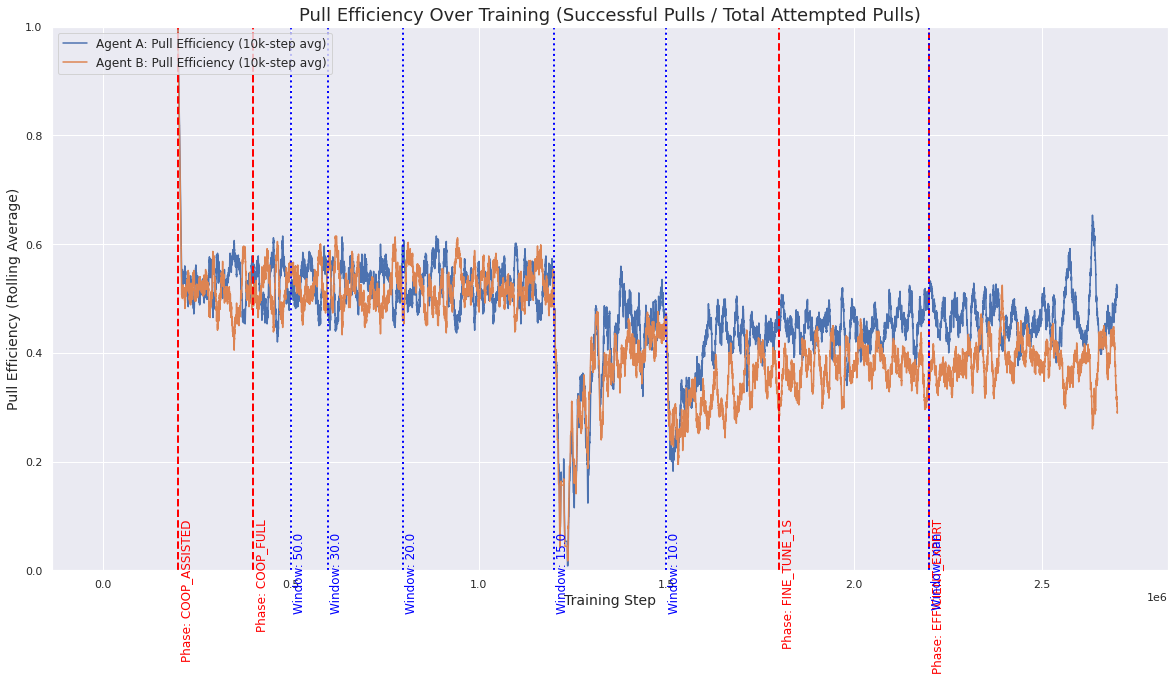

In [107]:
print("Calculating pull efficiency...")
import seaborn as sns


# Use the 100-step bin as requested
bin_size = 100
df['step_bin'] = (df['step'] // bin_size) * bin_size

# Define "attempted" vs "successful" pulls
# A "successful" pull is one that resulted in a large reward (> 5.0)
df['A_attempted_pull'] = (df['A_pull'] == 1)
df['B_attempted_pull'] = (df['B_pull'] == 1)
df['A_successful_pull'] = (df['A_pull'] == 1) & (df['A_reward'] > 5.0)
df['B_successful_pull'] = (df['B_pull'] == 1) & (df['B_reward'] > 5.0)


# --- 3. Aggregate Data ---
# Group by the 100-step bins and sum up the attempts and successes
df_agg = df.groupby('step_bin').agg(
    A_attempted_pulls=('A_attempted_pull', 'sum'),
    A_successful_pulls=('A_successful_pull', 'sum'),
    B_attempted_pulls=('B_attempted_pull', 'sum'),
    B_successful_pulls=('B_successful_pull', 'sum'),
    phase=('phase', 'first'),
    window=('window', 'first')
).reset_index()

# --- 4. Calculate Success Rate (Pull Efficiency) ---
# Calculate the raw success rate for each bin
# We use .fillna(0) to handle bins with 0 attempts (0/0 = NaN)
df_agg['A_success_rate'] = (df_agg['A_successful_pulls'] / df_agg['A_attempted_pulls']).fillna(0)
df_agg['B_success_rate'] = (df_agg['B_successful_pulls'] / df_agg['B_attempted_pulls']).fillna(0)

# --- 5. Smooth the Data (Rolling Average) ---
# The raw 100-step rate is too noisy. Let's smooth it with a 10,000-step
# (100 bins) rolling average to see the trend.
rolling_window_size = 100 
df_agg['A_rate_rolling'] = df_agg['A_success_rate'].rolling(window=rolling_window_size, min_periods=1).mean()
df_agg['B_rate_rolling'] = df_agg['B_success_rate'].rolling(window=rolling_window_size, min_periods=1).mean()

print("Calculation complete. Plotting...")

# --- 6. Plotting ---
plt.figure(figsize=(20, 10))
sns.lineplot(data=df_agg, x='step_bin', y='A_rate_rolling', label='Agent A: Pull Efficiency (10k-step avg)')
sns.lineplot(data=df_agg, x='step_bin', y='B_rate_rolling', label='Agent B: Pull Efficiency (10k-step avg)')

plt.title('Pull Efficiency Over Training (Successful Pulls / Total Attempted Pulls)', fontsize=18)
plt.ylabel('Pull Efficiency (Rolling Average)', fontsize=14)
plt.xlabel('Training Step', fontsize=14)
plt.legend(loc='upper left', fontsize=12)

# --- Add vertical lines for curriculum changes ---
phase_changes = df_agg.drop_duplicates('phase')[['step_bin', 'phase']].iloc[1:]
window_changes = df_agg.drop_duplicates('window')[['step_bin', 'window']].iloc[1:]

ax = plt.gca()
for _, row in phase_changes.iterrows():
    ax.axvline(x=row['step_bin'], color='red', linestyle='--', linewidth=2)
    ax.text(row['step_bin'] + 5000, 0.095, f"Phase: {row['phase']}", 
            color='red', rotation=90, ha='left', va='top', fontsize=12)

for _, row in window_changes.iterrows():
    ax.axvline(x=row['step_bin'], color='blue', linestyle=':', linewidth=2)
    ax.text(row['step_bin'] + 5000, 0.07, f"Window: {row['window']}", 
            color='blue', rotation=90, ha='left', va='top', fontsize=12)

plt.ylim(0, 1) # Efficiency is a rate from 0 to 1
plt.savefig("pull_efficiency_plot_withGAE_PPO.pdf")

Calculating Inter-Pull Intervals (IPI)...
Calculation complete. Plotting...
Plot saved as 'ipi_plot_withGAE_PPO.pdf


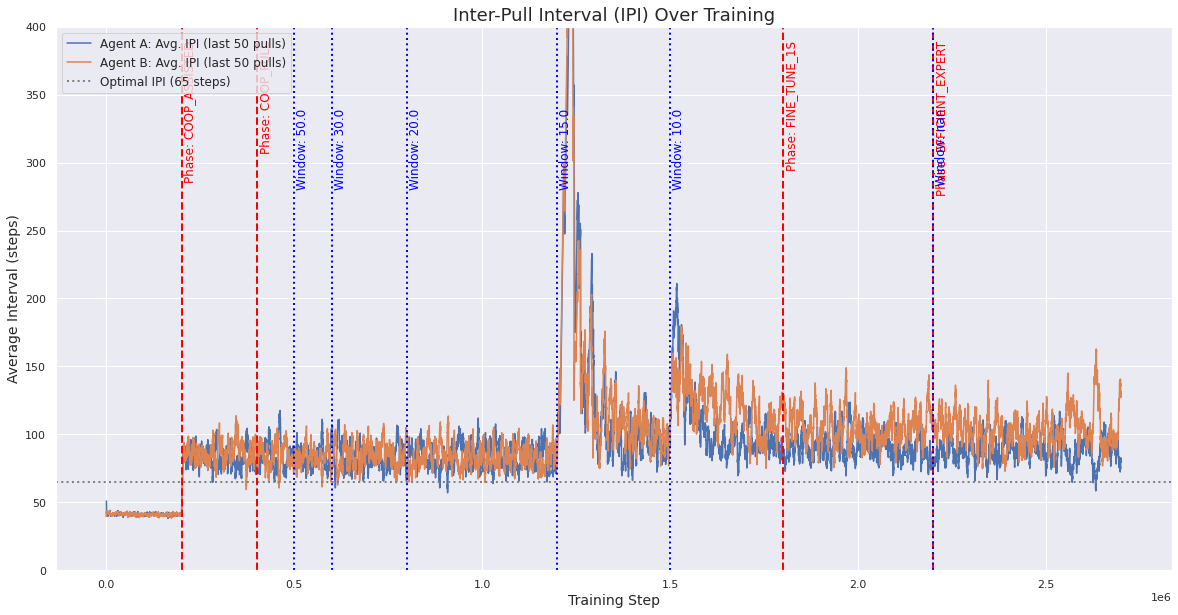

In [108]:
# Set plotting style
sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = (18, 8)


# --- 2. Get Curriculum Change Points ---
# We do this first, on the full dataframe
bin_size = 5000
df['step_bin'] = (df['step'] // bin_size) * bin_size
df_agg_bins = df.groupby('step_bin').first().reset_index()
phase_changes = df_agg_bins.drop_duplicates('phase')[['step', 'phase']].iloc[1:]
window_changes = df_agg_bins.drop_duplicates('window')[['step', 'window']].iloc[1:]


# --- 3. Feature Engineering: Find Successful Pulls ---
print("Calculating Inter-Pull Intervals (IPI)...")

# A "successful" pull is one that resulted in a large reward (> 5.0)
df['A_successful_pull'] = (df['A_pull'] == 1)  & (df['A_reward'] > 5.0)
df['B_successful_pull'] = (df['B_pull'] == 1)  & (df['B_reward'] > 5.0)

# --- 4. Calculate IPI ---
# Create new, "sparse" DataFrames containing only the successful pulls
df_A_pulls = df[df['A_successful_pull']].copy()
df_B_pulls = df[df['B_successful_pull']].copy()

# Calculate the difference (in steps) between each successful pull
df_A_pulls['A_IPI'] = df_A_pulls['step'].diff()
df_B_pulls['B_IPI'] = df_B_pulls['step'].diff()

# --- 5. Smooth the Data (Rolling Average) ---
# Calculate the rolling average of the last 50 IPIs to see the trend
rolling_window_pulls = 50
df_A_pulls['A_IPI_rolling'] = df_A_pulls['A_IPI'].rolling(window=rolling_window_pulls, min_periods=1).mean()
df_B_pulls['B_IPI_rolling'] = df_B_pulls['B_IPI'].rolling(window=rolling_window_pulls, min_periods=1).mean()

print("Calculation complete. Plotting...")

# --- 6. Plotting ---
plt.figure(figsize=(20, 10))
sns.lineplot(data=df_A_pulls, x='step', y='A_IPI_rolling', label=f'Agent A: Avg. IPI (last {rolling_window_pulls} pulls)')
sns.lineplot(data=df_B_pulls, x='step', y='B_IPI_rolling', label=f'Agent B: Avg. IPI (last {rolling_window_pulls} pulls)')

# Add a line for the "optimal" pull interval (60-step cooldown + 5-step personal)
plt.axhline(y=65, color='gray', linestyle=':', linewidth=2, label='Optimal IPI (65 steps)')

plt.title('Inter-Pull Interval (IPI) Over Training', fontsize=18)
plt.ylabel('Average Interval (steps)', fontsize=14)
plt.xlabel('Training Step', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.ylim(0,400) # Zoom in on a reasonable IPI range

# --- Add vertical lines for curriculum changes ---
ax = plt.gca()
for _, row in phase_changes.iterrows():
    ax.axvline(x=row['step'], color='red', linestyle='--', linewidth=2)
    ax.text(row['step'] + 5000, 390, f"Phase: {row['phase']}", 
            color='red', rotation=90, ha='left', va='top', fontsize=12)

for _, row in window_changes.iterrows():
    ax.axvline(x=row['step'], color='blue', linestyle=':', linewidth=2)
    ax.text(row['step'] + 5000, 340, f"Window: {row['window']}", 
            color='blue', rotation=90, ha='left', va='top', fontsize=12)

plt.savefig("ipi_plot_withGAE_PPO.pdf")
print("Plot saved as 'ipi_plot_withGAE_PPO.pdf")

Loading log file: log_efficient_expert.pkl...
Loaded 500000 steps.
Extracting gaze windows...
Plot saved to 'gaze_distribution_around_pull.pdf'


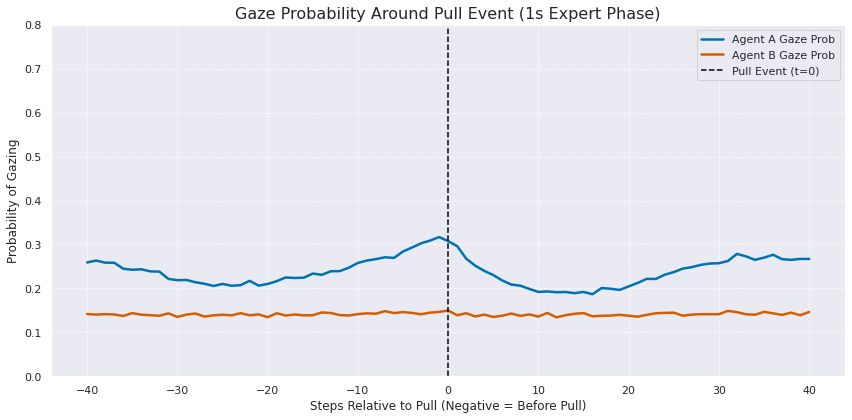

In [109]:
def plot_gaze_around_pull():
    # --- Configuration ---
    # LOG_FILE = "full_training_log_withGAE_PPO.pkl"
    # LOG_FILE = "fine_tune_log_1s_withGAE_PPO.pkl" # fine tuned with 1s but not learn the gaze cost
    LOG_FILE = "log_efficient_expert.pkl" # learned the gaze with cost
    
    WINDOW_SIZE = 40  # +/- 40 steps
    
    print(f"Loading log file: {LOG_FILE}...")
    try:
        df = pd.read_pickle(LOG_FILE)
        print(f"Loaded {len(df)} steps.")
    except FileNotFoundError:
        print(f"Error: Could not find {LOG_FILE}. Make sure you ran the 1s Expert training.")
        return

    # --- Helper to extract windows ---
    def get_gaze_windows(agent_prefix):
        """
        Finds all pulls for an agent and extracts the gaze profile around them.
        """
        pull_col = f"{agent_prefix}_pull"
        gaze_col = f"{agent_prefix}_gaze"
        
        # Find indices where a pull occurred
        pull_indices = df.index[df[pull_col] == 1].tolist()
        
        gaze_windows = []
        
        for idx in pull_indices:
            # Define start and end of the window
            start = idx - WINDOW_SIZE
            end = idx + WINDOW_SIZE + 1
            
            # Check boundaries (skip if window falls outside data)
            if start >= 0 and end <= len(df):
                # Extract gaze values (0 or 1)
                window_data = df[gaze_col].iloc[start:end].values
                gaze_windows.append(window_data)
        
        if not gaze_windows:
            return None
            
        # Stack into a matrix (N_pulls x Window_Width)
        gaze_matrix = np.vstack(gaze_windows)
        
        # Calculate mean gaze probability at each relative time step
        mean_gaze = np.mean(gaze_matrix, axis=0)
        
        return mean_gaze

    # --- Calculate Distributions ---
    print("Extracting gaze windows...")
    mean_gaze_A = get_gaze_windows("A")
    mean_gaze_B = get_gaze_windows("B")
    
    # X-axis (Relative Time)
    x_axis = np.arange(-WINDOW_SIZE, WINDOW_SIZE + 1)
    
    # --- Plotting ---
    plt.figure(figsize=(12, 6))
    
    # Plot Agent A
    if mean_gaze_A is not None:
        sns.lineplot(x=x_axis, y=mean_gaze_A, label="Agent A Gaze Prob", color="#0072B2", linewidth=2.5)
        
    # Plot Agent B
    if mean_gaze_B is not None:
        sns.lineplot(x=x_axis, y=mean_gaze_B, label="Agent B Gaze Prob", color="#D55E00", linewidth=2.5)
    
    # Add reference line at Pull Time (0)
    plt.axvline(x=0, color='black', linestyle='--', label="Pull Event (t=0)")
    
    # Styling
    plt.title(f"Gaze Probability Around Pull Event (1s Expert Phase)", fontsize=16)
    plt.xlabel("Steps Relative to Pull (Negative = Before Pull)", fontsize=12)
    plt.ylabel("Probability of Gazing", fontsize=12)
    plt.ylim(0, 0.8)
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig("gaze_distribution_around_pull.pdf")
    print("Plot saved to 'gaze_distribution_around_pull.pdf'")
    plt.show()

if 1:
    if __name__ == "__main__":
        plot_gaze_around_pull()
else:
    print("no plotting gaze around pull")

### train with gaze with different social evidence strength (modelled as the gaze reliability)

In [110]:
#################################################################
# 8. GENERALIST TRAINING (Variable Reliability - PPO FIX + VALID BIT)
#################################################################

def continue_training_generalist():
    """
    Fine-tunes the 1s Expert on a MIX of gaze reliabilities.
    Goal: Learn to adapt gaze rate based on reliability.
    """
    # --- Configuration ---
    CONTINUE_STEPS = 1000000  
    TARGET_WINDOW = 10       
    LR_FINE_TUNE = 5e-5
    
    print(f"\n--- Starting GENERALIST Training (PPO FIX + VALID BIT) ---")
    print("The agent will encounter random gaze reliability (10% to 100%)")
    print("Goal: Learn to gaze MORE when reliability is LOW.\n")
    
    # --- Setup Environment ---
    env = CurriculumEnv()
    env.set_training_phase("COOP_FULL", sync_window=TARGET_WINDOW)
    
    # *** ACTIVATE THE COST ***
    # env.gaze_cost = 0.03 
    # env.gaze_cost = 0.08
    env.gaze_cost = 0.2
    
    print(f"   Gaze Cost Active: {env.gaze_cost}")
    
    # --- Initialize Agents (Input Size 5) ---
    agent_A = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE,
                         MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)
    agent_B = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE,
                         MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)

    if 0:
        # --- Load The 1s Expert Models ---
        try:
            agent_A.load_state_dict(torch.load("agent_A_1s_expert_withGAE_PPO.pth"))
            agent_B.load_state_dict(torch.load("agent_B_1s_expert_withGAE_PPO.pth"))
            print("Loaded '1s Expert' weights.")
        except FileNotFoundError:
            print("Error: No expert models found! Run continue_training_1s() first.")
            return
    else:
        # --- Load The Efficient Expert Models ---
        try:
            # CHANGED: Load the models from the Cost Training phase
            agent_A.load_state_dict(torch.load("agent_A_efficient_expert.pth"))
            agent_B.load_state_dict(torch.load("agent_B_efficient_expert.pth"))
            print("Loaded 'Efficient Expert' weights.")
        except FileNotFoundError:
            print("Error: No efficient expert models found! Run continue_training_1s_with_cost() first.")
            return
    

    optimizer_A = optim.Adam(agent_A.parameters(), lr=LR_FINE_TUNE)
    optimizer_B = optim.Adam(agent_B.parameters(), lr=LR_FINE_TUNE)

    # --- Init State ---
    state_A_dict, state_B_dict = env.reset()
    public_A = preprocess_state(state_A_dict)
    public_B = preprocess_state(state_B_dict)
    
    private_A = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    private_B = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    hidden_A = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)
    hidden_B = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)

    generalist_log = []
    

    # --- Initialize Reliability ---
    # Start with High Reliability (Low Noise) to warm up
    current_reliability = 1.0
    
    # =========================================================================
    # GENERALIST LOOP
    # =========================================================================
    for update_step in range(CONTINUE_STEPS // N_STEPS):
        
        total_steps_so_far = update_step * N_STEPS
        
        # --- DYNAMIC RELIABILITY (Variable Noise) ---
        # Change reliability every 5 updates (2500 steps)
        # This forces the agent to adapt to different "fog" levels
        if update_step % 5 == 0:
            current_reliability = np.random.uniform(0.1, 1.0)
        
        # --- Storage Buffers ---
        mem_pub_A, mem_priv_A, mem_mask_A = [], [], []
        mem_act_A, mem_val_A, mem_rew_A, mem_logp_A = [], [], [], []
        
        mem_pub_B, mem_priv_B, mem_mask_B = [], [], []
        mem_act_B, mem_val_B, mem_rew_B, mem_logp_B = [], [], [], []
        
        # Detach hidden
        start_hidden_A = hidden_A.detach()
        start_hidden_B = hidden_B.detach()
        hidden_A = start_hidden_A
        hidden_B = start_hidden_B

        # --- Rollout ---
        for step in range(N_STEPS):
            
            # 1. Masks
            if state_A_dict['can_pull']: mask_A = torch.tensor([[0., 0.]], device=device).float()
            else: mask_A = torch.tensor([[0., -1e9]], device=device).float()
            if state_B_dict['can_pull']: mask_B = torch.tensor([[0., 0.]], device=device).float()
            else: mask_B = torch.tensor([[0., -1e9]], device=device).float()

            # 2. Store Inputs
            mem_pub_A.append(public_A); mem_priv_A.append(private_A); mem_mask_A.append(mask_A)
            mem_pub_B.append(public_B); mem_priv_B.append(private_B); mem_mask_B.append(mask_B)

            # 3. Forward
            with torch.no_grad():
                (logits_A_tuple), value_A, hidden_A = agent_A(public_A, private_A, hidden_A, mask_A)
                (logits_B_tuple), value_B, hidden_B = agent_B(public_B, private_B, hidden_B, mask_B)
            
            # 4. Sample
            act_A_dict, log_prob_A = sample_actions(logits_A_tuple) 
            act_B_dict, log_prob_B = sample_actions(logits_B_tuple)

            # 5. Store Outputs
            mem_act_A.append(act_A_dict); mem_val_A.append(value_A); mem_logp_A.append(log_prob_A)
            mem_act_B.append(act_B_dict); mem_val_B.append(value_B); mem_logp_B.append(log_prob_B)

            # 6. Env Step
            next_state_A_dict, next_state_B_dict, reward_A, reward_B, done = \
                env.step(act_A_dict, act_B_dict)
            
            mem_rew_A.append(reward_A)
            mem_rew_B.append(reward_B)
            
            # Logging
            generalist_log.append({
                'step': total_steps_so_far + step,
                'reliability': current_reliability,
                'A_reward': reward_A,
                'B_reward': reward_B,
                'A_gaze': act_A_dict['gaze'],
                'B_gaze': act_B_dict['gaze'],
                'A_pull': act_A_dict['pull'],
                'B_pull': act_B_dict['pull']
            })

            # 7. Prepare Next State (UPDATED FOR GAUSSIAN ACCUMULATION)
            # We pass the gaze action directly. The helper function handles the logic:
            # - If Gaze=1: Returns Sample from N(TrueMean, Sigma)
            # - If Gaze=0: Returns 0.0 (or Pure Noise)
            
            private_A = get_private_state(
                next_state_B_dict, 
                env.B_time_since_pull, 
                env.current_sync_window, 
                reliability_level=current_reliability,  # <--- Controls Sigma
                is_gazing=(act_A_dict['gaze'] == 1)     # <--- Controls Gate
            )
                
            private_B = get_private_state(
                next_state_A_dict, 
                env.A_time_since_pull, 
                env.current_sync_window, 
                reliability_level=current_reliability,  # <--- Controls Sigma
                is_gazing=(act_B_dict['gaze'] == 1)     # <--- Controls Gate
            )

            public_A = preprocess_state(next_state_A_dict)
            public_B = preprocess_state(next_state_B_dict)
            state_A_dict = next_state_A_dict
            state_B_dict = next_state_B_dict

        # ==================================================================
        # UPDATE PHASE (PPO FIX - Standard Implementation)
        # No changes needed here because mem_priv_A contains the noisy samples
        # we observed during rollout, which is exactly what we want to train on.
        # ==================================================================
        
        # 1. GAE
        with torch.no_grad():
            _, next_value_A, _ = agent_A(public_A, private_A, hidden_A, mask_A)
            _, next_value_B, _ = agent_B(public_B, private_B, hidden_B, mask_B)

        returns_A = calculate_gae(mem_rew_A, mem_val_A, next_value_A)
        returns_B = calculate_gae(mem_rew_B, mem_val_B, next_value_B)

        values_A_old = torch.cat(mem_val_A).view(-1)
        values_B_old = torch.cat(mem_val_B).view(-1)
        
        adv_A = returns_A - values_A_old
        adv_B = returns_B - values_B_old
        adv_A = (adv_A - adv_A.mean()) / (adv_A.std() + 1e-8)
        adv_B = (adv_B - adv_B.mean()) / (adv_B.std() + 1e-8)

        old_logprobs_A = torch.cat(mem_logp_A).detach().view(-1)
        old_logprobs_B = torch.cat(mem_logp_B).detach().view(-1)

        # 2. Re-run Network
        curr_hidden_A = start_hidden_A
        curr_hidden_B = start_hidden_B
        
        new_logprobs_A_list, entropy_A_list = [], []
        new_logprobs_B_list, entropy_B_list = [], []

        for t in range(N_STEPS):
            # Agent A
            (logits_A), _, curr_hidden_A = agent_A(mem_pub_A[t], mem_priv_A[t], curr_hidden_A, mem_mask_A[t])
            move_l, pull_l, gaze_l = logits_A
            taken_act = mem_act_A[t]
            new_lp = Categorical(logits=move_l).log_prob(torch.tensor(taken_act['move']).to(device)) + \
                     Categorical(logits=pull_l).log_prob(torch.tensor(taken_act['pull']).to(device)) + \
                     Categorical(logits=gaze_l).log_prob(torch.tensor(taken_act['gaze']).to(device))
            new_logprobs_A_list.append(new_lp)
            ent = -(F.softmax(pull_l, -1)*F.log_softmax(pull_l, -1)).sum() - (F.softmax(gaze_l, -1)*F.log_softmax(gaze_l, -1)).sum()
            entropy_A_list.append(ent)
            
            # Agent B
            (logits_B), _, curr_hidden_B = agent_B(mem_pub_B[t], mem_priv_B[t], curr_hidden_B, mem_mask_B[t])
            move_l, pull_l, gaze_l = logits_B
            taken_act = mem_act_B[t]
            new_lp = Categorical(logits=move_l).log_prob(torch.tensor(taken_act['move']).to(device)) + \
                     Categorical(logits=pull_l).log_prob(torch.tensor(taken_act['pull']).to(device)) + \
                     Categorical(logits=gaze_l).log_prob(torch.tensor(taken_act['gaze']).to(device))
            new_logprobs_B_list.append(new_lp)
            ent = -(F.softmax(pull_l, -1)*F.log_softmax(pull_l, -1)).sum() - (F.softmax(gaze_l, -1)*F.log_softmax(gaze_l, -1)).sum()
            entropy_B_list.append(ent)

        new_logprobs_A = torch.stack(new_logprobs_A_list).view(-1)
        mean_ent_A = torch.stack(entropy_A_list).mean()
        new_logprobs_B = torch.stack(new_logprobs_B_list).view(-1)
        mean_ent_B = torch.stack(entropy_B_list).mean()

        # 3. PPO Update
        EPS_CLIP = 0.2
        
        ratio_A = torch.exp(new_logprobs_A - old_logprobs_A)
        surr1_A = ratio_A * adv_A
        surr2_A = torch.clamp(ratio_A, 1-EPS_CLIP, 1+EPS_CLIP) * adv_A
        loss_A = -torch.min(surr1_A, surr2_A).mean() + VALUE_LOSS_COEF * F.mse_loss(values_A_old, returns_A) - ENTROPY_COEF * mean_ent_A

        ratio_B = torch.exp(new_logprobs_B - old_logprobs_B)
        surr1_B = ratio_B * adv_B
        surr2_B = torch.clamp(ratio_B, 1-EPS_CLIP, 1+EPS_CLIP) * adv_B
        loss_B = -torch.min(surr1_B, surr2_B).mean() + VALUE_LOSS_COEF * F.mse_loss(values_B_old, returns_B) - ENTROPY_COEF * mean_ent_B

        optimizer_A.zero_grad(); loss_A.backward(); torch.nn.utils.clip_grad_norm_(agent_A.parameters(), 0.5); optimizer_A.step()
        optimizer_B.zero_grad(); loss_B.backward(); torch.nn.utils.clip_grad_norm_(agent_B.parameters(), 0.5); optimizer_B.step()
        # ==================================================================

        if update_step % 20 == 0:
            print(f"Gen Step {total_steps_so_far}: Rel={current_reliability:.2f}, R_A={sum(mem_rew_A):.1f}, R_B={sum(mem_rew_B):.1f}")

    print("Generalist Training Complete.")
    
    # --- Save ---
    torch.save(agent_A.state_dict(), "agent_A_generalist_withGAE_PPO.pth")
    torch.save(agent_B.state_dict(), "agent_B_generalist_withGAE_PPO.pth")
    
    df_log = pd.DataFrame(generalist_log)
    df_log.to_pickle("log_generalist_withGAE_PPO.pkl")
    print("Files saved: agent_A/B_generalist_withGAE_PPO.pth, log_generalist_withGAE_PPO.pkl")

    
# --- Run ---
if 0:
    if __name__ == "__main__":
        continue_training_generalist()
else:
    print('no gaze reliability vaying training')

no gaze reliability vaying training


In [111]:
#################################################################
# 8b. GENERALIST TRAINING WITH LATENCY (Cost 0.02 + Time Cost)
#################################################################

def continue_training_generalist_with_latency():
    CONTINUE_STEPS = 1000000  
    TARGET_WINDOW = 10       
    LR_FINE_TUNE = 5e-5
    
    # *** ACTIVATE THE COST ***
    # Low economic cost (0.02) so they WANT to spam,
    # but Latency logic forces them to accept a time delay.
    LOW_COST = 0.00
    # LOW_COST = 0.02
    # LOW_COST = 0.08
    
    
    print(f"\n--- Starting GENERALIST LATENCY Training (Cost {LOW_COST} + DISTRACTION) ---")
    
    # --- USE THE NEW LATENCY ENV ---
    env = CurriculumEnv_WithGazeLatency()
    env.set_training_phase("COOP_FULL", sync_window=TARGET_WINDOW)
    env.gaze_cost = LOW_COST
    print(f"   Gaze Cost: {env.gaze_cost}, Latency: ON")
    
    agent_A = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE, MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)
    agent_B = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE, MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)

    # --- Load EFFICIENT EXPERT (Starting point) ---
    if 1:
        # --- Load The 1s Expert Models ---
        try:
            agent_A.load_state_dict(torch.load("agent_A_1s_expert_withGAE_PPO.pth"))
            agent_B.load_state_dict(torch.load("agent_B_1s_expert_withGAE_PPO.pth"))
            print("Loaded '1s Expert' weights.")
        except FileNotFoundError:
            print("Error: No expert models found! Run continue_training_1s() first.")
            return
    else:
        # --- Load The Efficient Expert Models ---
        try:
            # CHANGED: Load the models from the Cost Training phase
            agent_A.load_state_dict(torch.load("agent_A_efficient_expert.pth"))
            agent_B.load_state_dict(torch.load("agent_B_efficient_expert.pth"))
            print("Loaded 'Efficient Expert' weights.")
        except FileNotFoundError:
            print("Error: No efficient expert models found! Run continue_training_1s_with_cost() first.")
            return
        

    optimizer_A = optim.Adam(agent_A.parameters(), lr=LR_FINE_TUNE)
    optimizer_B = optim.Adam(agent_B.parameters(), lr=LR_FINE_TUNE)

    state_A_dict, state_B_dict = env.reset()
    public_A = preprocess_state(state_A_dict); public_B = preprocess_state(state_B_dict)
    private_A = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    private_B = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
    hidden_A = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)
    hidden_B = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)

    latency_log = []
    current_reliability = 1.0 
    
    for update_step in range(CONTINUE_STEPS // N_STEPS):
        total_steps_so_far = update_step * N_STEPS
        if update_step % 5 == 0: current_reliability = np.random.uniform(0.1, 1.0)
        
        mem_pub_A, mem_priv_A, mem_mask_A = [], [], []
        mem_act_A, mem_val_A, mem_rew_A, mem_logp_A = [], [], [], []
        mem_pub_B, mem_priv_B, mem_mask_B = [], [], []
        mem_act_B, mem_val_B, mem_rew_B, mem_logp_B = [], [], [], []
        
        start_hidden_A = hidden_A.detach(); start_hidden_B = hidden_B.detach()
        hidden_A = start_hidden_A; hidden_B = start_hidden_B

        for step in range(N_STEPS):
            if state_A_dict['can_pull']: mask_A = torch.tensor([[0., 0.]], device=device).float()
            else: mask_A = torch.tensor([[0., -1e9]], device=device).float()
            if state_B_dict['can_pull']: mask_B = torch.tensor([[0., 0.]], device=device).float()
            else: mask_B = torch.tensor([[0., -1e9]], device=device).float()

            mem_pub_A.append(public_A); mem_priv_A.append(private_A); mem_mask_A.append(mask_A)
            mem_pub_B.append(public_B); mem_priv_B.append(private_B); mem_mask_B.append(mask_B)

            with torch.no_grad():
                (logits_A_tuple), value_A, hidden_A = agent_A(public_A, private_A, hidden_A, mask_A)
                (logits_B_tuple), value_B, hidden_B = agent_B(public_B, private_B, hidden_B, mask_B)
            
            act_A_dict, log_prob_A = sample_actions(logits_A_tuple) 
            act_B_dict, log_prob_B = sample_actions(logits_B_tuple)

            mem_act_A.append(act_A_dict); mem_val_A.append(value_A); mem_logp_A.append(log_prob_A)
            mem_act_B.append(act_B_dict); mem_val_B.append(value_B); mem_logp_B.append(log_prob_B)

            next_state_A_dict, next_state_B_dict, reward_A, reward_B, done = env.step(act_A_dict, act_B_dict)
            mem_rew_A.append(reward_A); mem_rew_B.append(reward_B)
            
            latency_log.append({
                'step': total_steps_so_far + step,
                'reliability': current_reliability,
                'A_reward': reward_A, 'B_reward': reward_B,
                'A_gaze': act_A_dict['gaze'], 'B_gaze': act_B_dict['gaze'],
                'A_pull': act_A_dict['pull'], 'B_pull': act_B_dict['pull']
            })

            is_reliable_now = (np.random.rand() < current_reliability)
            if act_A_dict['gaze'] == 1: private_A = get_private_state(next_state_B_dict, env.B_time_since_pull, env.current_sync_window, is_reliable_now)
            else: private_A = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
            if act_B_dict['gaze'] == 1: private_B = get_private_state(next_state_A_dict, env.A_time_since_pull, env.current_sync_window, is_reliable_now)
            else: private_B = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)

            public_A = preprocess_state(next_state_A_dict); public_B = preprocess_state(next_state_B_dict)
            state_A_dict = next_state_A_dict; state_B_dict = next_state_B_dict

        with torch.no_grad():
            _, next_value_A, _ = agent_A(public_A, private_A, hidden_A, mask_A)
            _, next_value_B, _ = agent_B(public_B, private_B, hidden_B, mask_B)

        returns_A = calculate_gae(mem_rew_A, mem_val_A, next_value_A); returns_B = calculate_gae(mem_rew_B, mem_val_B, next_value_B)
        values_A_old = torch.cat(mem_val_A).view(-1); values_B_old = torch.cat(mem_val_B).view(-1)
        adv_A = (returns_A - values_A_old); adv_A = (adv_A - adv_A.mean()) / (adv_A.std() + 1e-8)
        adv_B = (returns_B - values_B_old); adv_B = (adv_B - adv_B.mean()) / (adv_B.std() + 1e-8)
        old_logprobs_A = torch.cat(mem_logp_A).detach().view(-1); old_logprobs_B = torch.cat(mem_logp_B).detach().view(-1)

        curr_hidden_A = start_hidden_A; curr_hidden_B = start_hidden_B
        new_logprobs_A_list, entropy_A_list = [], []; new_logprobs_B_list, entropy_B_list = [], []

        for t in range(N_STEPS):
            (logits_A), _, curr_hidden_A = agent_A(mem_pub_A[t], mem_priv_A[t], curr_hidden_A, mem_mask_A[t])
            move_l, pull_l, gaze_l = logits_A
            new_lp = Categorical(logits=move_l).log_prob(torch.tensor(mem_act_A[t]['move']).to(device)) + \
                     Categorical(logits=pull_l).log_prob(torch.tensor(mem_act_A[t]['pull']).to(device)) + \
                     Categorical(logits=gaze_l).log_prob(torch.tensor(mem_act_A[t]['gaze']).to(device))
            new_logprobs_A_list.append(new_lp)
            entropy_A_list.append(-(F.softmax(pull_l, -1)*F.log_softmax(pull_l, -1)).sum() - (F.softmax(gaze_l, -1)*F.log_softmax(gaze_l, -1)).sum())
            
            (logits_B), _, curr_hidden_B = agent_B(mem_pub_B[t], mem_priv_B[t], curr_hidden_B, mem_mask_B[t])
            move_l, pull_l, gaze_l = logits_B
            new_lp = Categorical(logits=move_l).log_prob(torch.tensor(mem_act_B[t]['move']).to(device)) + \
                     Categorical(logits=pull_l).log_prob(torch.tensor(mem_act_B[t]['pull']).to(device)) + \
                     Categorical(logits=gaze_l).log_prob(torch.tensor(mem_act_B[t]['gaze']).to(device))
            new_logprobs_B_list.append(new_lp)
            entropy_B_list.append(-(F.softmax(pull_l, -1)*F.log_softmax(pull_l, -1)).sum() - (F.softmax(gaze_l, -1)*F.log_softmax(gaze_l, -1)).sum())

        new_logprobs_A = torch.stack(new_logprobs_A_list).view(-1); mean_ent_A = torch.stack(entropy_A_list).mean()
        new_logprobs_B = torch.stack(new_logprobs_B_list).view(-1); mean_ent_B = torch.stack(entropy_B_list).mean()

        EPS_CLIP = 0.2
        ratio_A = torch.exp(new_logprobs_A - old_logprobs_A)
        loss_A = -torch.min(ratio_A * adv_A, torch.clamp(ratio_A, 1-EPS_CLIP, 1+EPS_CLIP) * adv_A).mean() + VALUE_LOSS_COEF * F.mse_loss(values_A_old, returns_A) - ENTROPY_COEF * mean_ent_A
        ratio_B = torch.exp(new_logprobs_B - old_logprobs_B)
        loss_B = -torch.min(ratio_B * adv_B, torch.clamp(ratio_B, 1-EPS_CLIP, 1+EPS_CLIP) * adv_B).mean() + VALUE_LOSS_COEF * F.mse_loss(values_B_old, returns_B) - ENTROPY_COEF * mean_ent_B

        optimizer_A.zero_grad(); loss_A.backward(); torch.nn.utils.clip_grad_norm_(agent_A.parameters(), 0.5); optimizer_A.step()
        optimizer_B.zero_grad(); loss_B.backward(); torch.nn.utils.clip_grad_norm_(agent_B.parameters(), 0.5); optimizer_B.step()

        if update_step % 20 == 0:
            print(f"Latency-Gen Step {total_steps_so_far}: Rel={current_reliability:.2f}, R_A={sum(mem_rew_A):.1f}, R_B={sum(mem_rew_B):.1f}")

    print("Latency Generalist Training Complete.")
    
    # --- SAVE WITH NEW NAMES ---
    torch.save(agent_A.state_dict(), "agent_A_generalist_latency.pth")
    torch.save(agent_B.state_dict(), "agent_B_generalist_latency.pth")
    
    df_log = pd.DataFrame(latency_log)
    df_log.to_pickle("log_generalist_latency.pkl")
    
    print("Files saved: agent_A/B_generalist_latency.pth, log_generalist_latency.pkl")

if 0:
    if __name__ == "__main__":
        continue_training_generalist_with_latency()
else:
    print('no gaze reliability vaying with gaze latency training')
        

no gaze reliability vaying with gaze latency training


In [89]:
# --- Configuration ---
LOG_FILE = "log_generalist_withGAE_PPO.pkl"
# LOG_FILE = "log_generalist_latency.pkl"

BIN_SIZE = 1000  # Group steps into bins for smoother plotting
ROLLING_WINDOW = 50 # Rolling average window size

# --- 1. Load Data ---
try:
    df = pd.read_pickle(LOG_FILE)
    print(f"Successfully loaded {len(df)} steps from '{LOG_FILE}'")
except FileNotFoundError:
    print(f"Error: Could not find '{LOG_FILE}'. Make sure you ran the training first.")
    df = pd.DataFrame()

#
if 0:
    if not df.empty:
        # --- 2. Pre-process Data ---

        # Create bins for plotting (e.g., every 1000 steps)
        df['step_bin'] = (df['step'] // BIN_SIZE) * BIN_SIZE

        # Identify successful pulls (Coordination Reward > 5.0)
        df['A_successful_pull'] = (df['A_pull'] == 1) & (df['A_reward'] > 5.0)
        df['B_successful_pull'] = (df['B_pull'] == 1) & (df['B_reward'] > 5.0)

        # Identify attempted pulls (Any pull action)
        df['A_attempted_pull'] = (df['A_pull'] == 1)
        df['B_attempted_pull'] = (df['B_pull'] == 1)

        # --- 3. Aggregate by Bin ---
        df_agg = df.groupby('step_bin').agg({
            'A_successful_pull': 'sum',
            'B_successful_pull': 'sum',
            'A_attempted_pull': 'sum',
            'B_attempted_pull': 'sum',
            'A_gaze': 'mean',  # Average gaze action (rate) per bin
            'B_gaze': 'mean',
            'reliability': 'mean'     # Average reliability for this bin
        }).reset_index()

        # --- 4. Calculate Metrics ---

        # Efficiency: Success / Attempts
        df_agg['A_efficiency'] = df_agg['A_successful_pull'] / df_agg['A_attempted_pull'].replace(0, 1)
        df_agg['B_efficiency'] = df_agg['B_successful_pull'] / df_agg['B_attempted_pull'].replace(0, 1)

        # Smooth the lines
        df_agg['A_eff_smooth'] = df_agg['A_efficiency'].rolling(window=ROLLING_WINDOW).mean()
        df_agg['B_eff_smooth'] = df_agg['B_efficiency'].rolling(window=ROLLING_WINDOW).mean()
        df_agg['A_gaze_smooth'] = df_agg['A_gaze'].rolling(window=ROLLING_WINDOW).mean()
        df_agg['B_gaze_smooth'] = df_agg['B_gaze'].rolling(window=ROLLING_WINDOW).mean()

        # --- 5. Calculate IPI (Inter-Pull Interval) separately ---
        # (IPI needs step-by-step differences, not bins)
        df_success_A = df[df['A_successful_pull']].copy()
        df_success_B = df[df['B_successful_pull']].copy()

        df_success_A['IPI'] = df_success_A['step'].diff()
        df_success_B['IPI'] = df_success_B['step'].diff()

        # Create a rolling average for IPI
        df_success_A['IPI_smooth'] = df_success_A['IPI'].rolling(window=50).mean()
        df_success_B['IPI_smooth'] = df_success_B['IPI'].rolling(window=50).mean()

        # --- PLOTTING ---
        sns.set(style="darkgrid")
        fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=False)

        # --- Plot 1: Pull Efficiency ---
        sns.lineplot(ax=axes[0], data=df_agg, x='step_bin', y='A_eff_smooth', label='Agent A Efficiency', color='#0072B2')
        sns.lineplot(ax=axes[0], data=df_agg, x='step_bin', y='B_eff_smooth', label='Agent B Efficiency', color='#D55E00')

        # Overlay Reliability (Secondary Axis)
        ax0_twin = axes[0].twinx()
        sns.lineplot(ax=ax0_twin, data=df_agg, x='step_bin', y='reliability', color='gray', alpha=0.3, label='Gaze Reliability', linestyle='--')
        ax0_twin.set_ylim(0, 1.1)
        ax0_twin.set_ylabel('Gaze Reliability', color='gray')

        axes[0].set_title('Pull Efficiency (with Reliability Context)', fontsize=16)
        axes[0].set_ylabel('Efficiency (Success/Attempts)', fontsize=12)
        axes[0].set_ylim(0, 1.0)
        axes[0].legend(loc='upper left')

        # --- Plot 2: Inter-Pull Interval (IPI) ---
        sns.lineplot(ax=axes[1], data=df_success_A, x='step', y='IPI_smooth', label='Agent A IPI', color='#0072B2')
        sns.lineplot(ax=axes[1], data=df_success_B, x='step', y='IPI_smooth', label='Agent B IPI', color='#D55E00')
        axes[1].axhline(y=65, color='gray', linestyle=':', label='Optimal (approx 65)')

        axes[1].set_title('Inter-Pull Interval (IPI)', fontsize=16)
        axes[1].set_ylabel('Steps Between Successful Pulls', fontsize=12)
        axes[1].set_ylim(0, 300) # Adjust based on your data range
        axes[1].legend(loc='upper left')

        # --- Plot 3: Gaze Rate ---
        sns.lineplot(ax=axes[2], data=df_agg, x='step_bin', y='A_gaze_smooth', label='Agent A Gaze Rate', color='#0072B2')
        sns.lineplot(ax=axes[2], data=df_agg, x='step_bin', y='B_gaze_smooth', label='Agent B Gaze Rate', color='#D55E00')

        # Overlay Reliability (Secondary Axis)
        ax2_twin = axes[2].twinx()
        sns.lineplot(ax=ax2_twin, data=df_agg, x='step_bin', y='reliability', color='gray', alpha=0.3, label='Gaze Reliability', linestyle='--')
        ax2_twin.set_ylim(0, 1.1)
        ax2_twin.set_ylabel('Gaze Reliability', color='gray')

        axes[2].set_title('Gaze Rate Adaptation', fontsize=16)
        axes[2].set_ylabel('Gaze Probability (Avg per bin)', fontsize=12)
        axes[2].set_xlabel('Training Step', fontsize=14)
        axes[2].legend(loc='upper left')

        plt.tight_layout()
        plt.savefig("generalist_training_analysis_withGAE_PPO.pdf")
        print("Saved plot to 'generalist_training_analysis_withGAE_PPO.pdf'")
        plt.show()

else:
    print("no plotting")

Successfully loaded 1000000 steps from 'log_generalist_withGAE_PPO.pkl'
no plotting


## use trained data to test the hypothesis
### helper functions

In [112]:
#################################################################
# 3. HELPER FUNCTIONS (NOW INCLUDES STOCHASTIC SAMPLING)
#################################################################

# --- 1. Define the Helper Function First ---
def sample_actions_for_testing(logits_tuple):
    """
    Takes logits from the Actor and STOCHASTICALLY samples
    one action from each category.
    """
    move_logits, pull_logits, gaze_logits = logits_tuple
    
    # --- Move Action ---
    move_dist = Categorical(logits=move_logits)
    move_action = move_dist.sample() 
    
    # --- Pull Action ---
    pull_dist = Categorical(logits=pull_logits)
    pull_action = pull_dist.sample()
    
    # --- Gaze Action ---
    gaze_dist = Categorical(logits=gaze_logits)
    gaze_action = gaze_dist.sample()
    
    actions_dict = {
        'move': move_action.item(),
        'pull': pull_action.item(),
        'gaze': gaze_action.item()
    }
    
    return actions_dict

### testing functions with the gaze reliability change conditions

--- Starting Analysis with Error Bars ---
No existing data found (or Force Generate is ON).
Starting Simulation to collect data...
Loaded Efficient Experts (Testing Zero-Shot Robustness).
*** ENV UPDATED: Phase=COOP_FULL, SyncWindow=10, GazeCost=0.0 ***
Data collection complete. Saved to 'test_data_reliability_sweep.pkl'
Generating Plots from Data...
Saved Fig 1.
Building PETH DataFrames (this calculates windows)...
Saved Fig 2.
Saved Fig 3.
Saved Fig 4.
Generating Figure 5: Success Rate vs. Reliability...
Saved Fig5_AgentSuccessRates.pdf


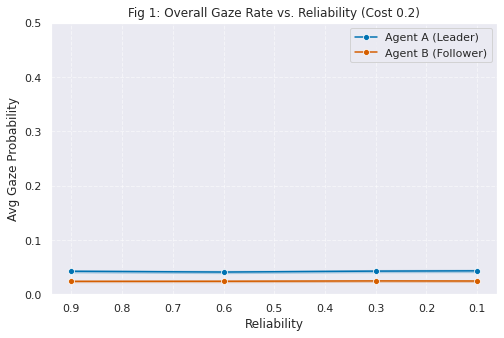

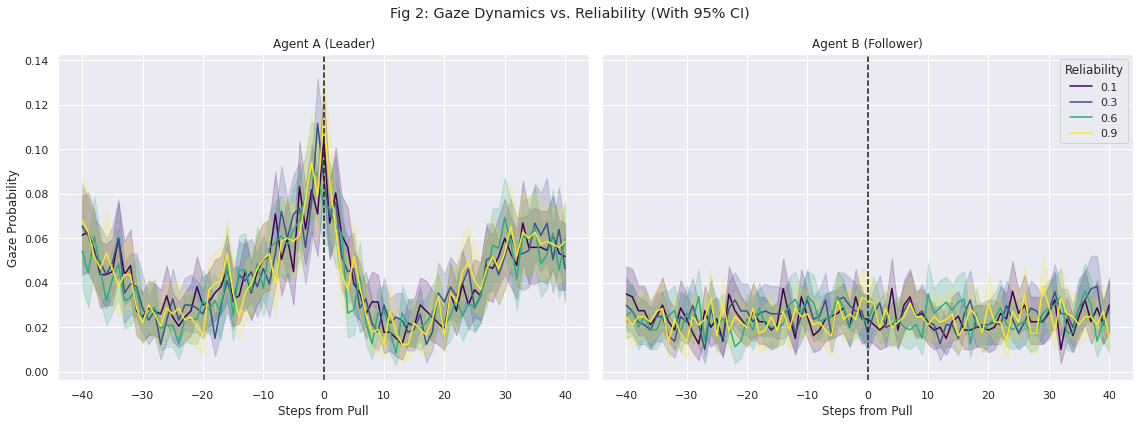

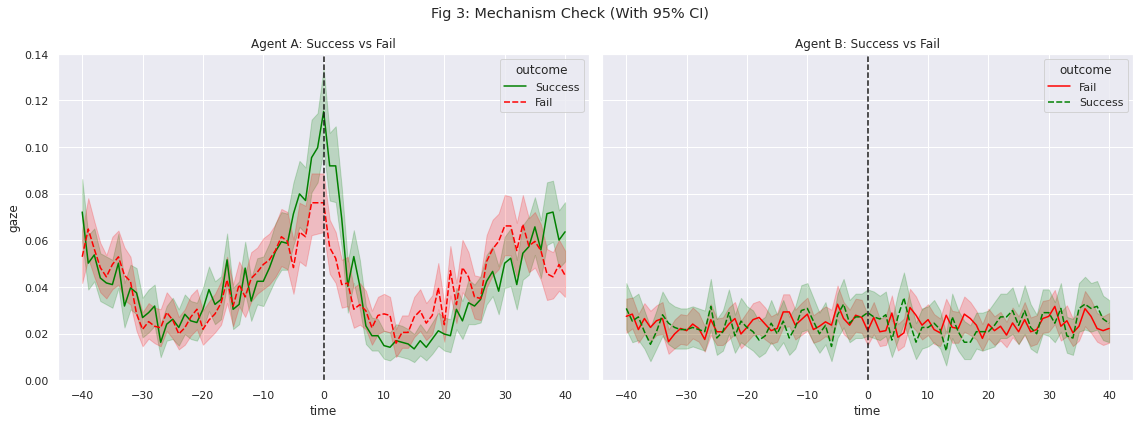

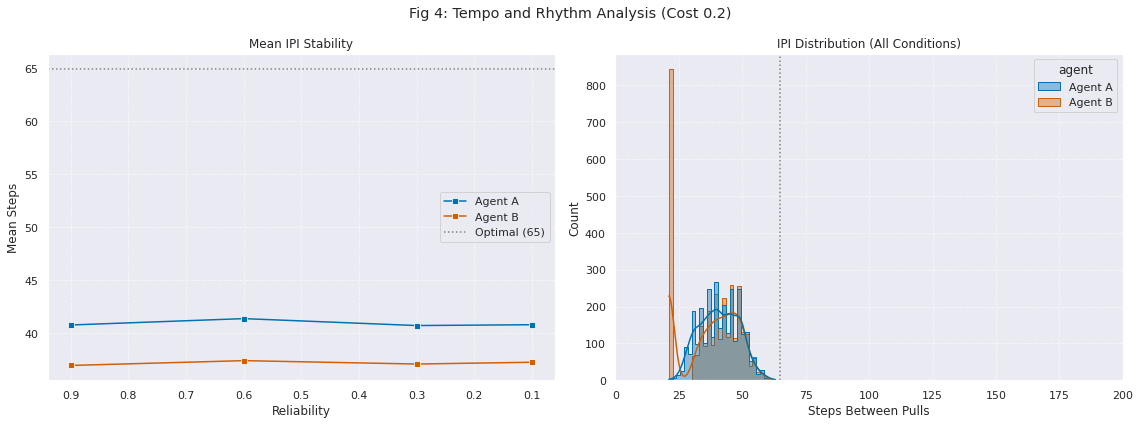

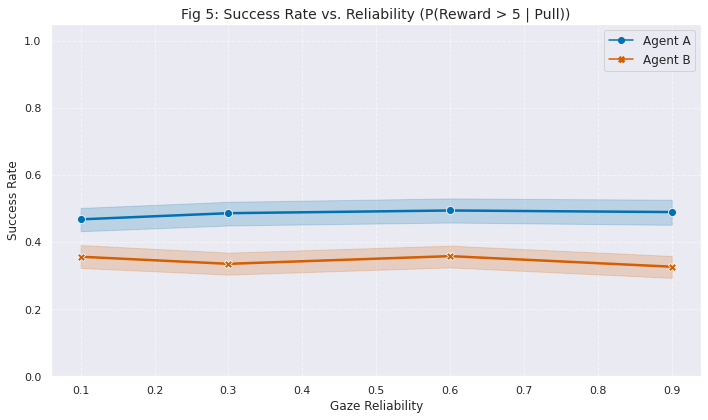

In [113]:
################################################################
# 10. FULL ANALYSIS SUITE (WITH DATA SAVING & ERROR BARS)
#################################################################

def run_comprehensive_analysis_with_errorbars():
    
    print("--- Starting Analysis with Error Bars ---")
    
    # --- Config ---
    DATA_FILENAME = "test_data_reliability_sweep.pkl" # <--- NEW: File to save/load
    FORCE_GENERATE = True                          # <--- NEW: Set True to force new data collection
    
          
    RELIABILITIES = [0.1, 0.3, 0.6, 0.9] 
    # RELIABILITIES = [# 0.0, 0.05,
    #                  0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 
    #                  0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 
    #                  0.7, 0.75, 0.8, 0.85, 0.9, 0.95] # Low, Mid, High reliability
    
    STEPS_PER_COND = 30000 
    TARGET_WINDOW = 10
    
          
    # TEST_COST = 0.08  # Matched to training
    TEST_COST = 0.2  # Matched to training
    
    WINDOW_SIZE = 40 
    
    # --- 1. DATA LOADING / GENERATION BLOCK ---
    if os.path.exists(DATA_FILENAME) and not FORCE_GENERATE:
        print(f"Found existing data file: '{DATA_FILENAME}'")
        print("Loading data... (Skipping simulation)")
        df = pd.read_pickle(DATA_FILENAME)
        print(f"Loaded {len(df)} rows.")
        
    else:
        print(f"No existing data found (or Force Generate is ON).")
        print("Starting Simulation to collect data...")
        
        # --- Load Agents ---
        agent_A = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE, MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)
        agent_B = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE, MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)
        
        try:
            # # use the most basic trained model 
            # agent_A.load_state_dict(torch.load("agent_A_brain_withGAE_PPO.pth"))
            # agent_B.load_state_dict(torch.load("agent_B_brain_withGAE_PPO.pth"))
            # print("Loaded the most based trained model.")
            #
            # # use the one mastered 1s but has not learned gaze cost
            # agent_A.load_state_dict(torch.load("agent_A_1s_expert_withGAE_PPO.pth"))
            # agent_B.load_state_dict(torch.load("agent_B_1s_expert_withGAE_PPO.pth"))
            # print("Loaded the 1s expert but no gaze cost.")
            
            # # Instead of "agent_A_generalist_withGAE_PPO.pth", use the one that mastered the 1s and learned the gaze cost
            agent_A.load_state_dict(torch.load("agent_A_efficient_expert.pth"))
            agent_B.load_state_dict(torch.load("agent_B_efficient_expert.pth"))
            print("Loaded Efficient Experts (Testing Zero-Shot Robustness).")
            #
            # # use the generalist - the one who learns the reliability - the main one
            # agent_A.load_state_dict(torch.load("agent_A_generalist_withGAE_PPO.pth"))
            # agent_B.load_state_dict(torch.load("agent_B_generalist_withGAE_PPO.pth"))
            # print("Loaded Generalist Experts.")
            # 
            #
            # # # use the generalist, but also learn that gaze need latency - do not use 
            # # agent_A.load_state_dict(torch.load("agent_A_generalist_latency.pth"))
            # # agent_B.load_state_dict(torch.load("agent_A_generalist_latency.pth"))
            # # print("Loaded Generalist Experts with gaze latency.")
            #
        except FileNotFoundError:
            print("Error: Generalist models not found.")
            # print("Error: Generalist models with gaze latency not found.")
            return

        agent_A.eval(); agent_B.eval()
        
        env = CurriculumEnv()
        env.set_training_phase("COOP_FULL", sync_window=TARGET_WINDOW)
        env.gaze_cost = TEST_COST 
        
        # --- Data Collection Loop ---
        history_data = []

        for rel in RELIABILITIES:
            print(f"Collecting Data: Reliability {rel*100:.0f}%...")
            
            state_A_dict, state_B_dict = env.reset()
            public_A = preprocess_state(state_A_dict); public_B = preprocess_state(state_B_dict)
            private_A = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device); private_B = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
            hidden_A = torch.zeros(1, RNN_HIDDEN_SIZE).to(device); hidden_B = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)
            
            for step in range(STEPS_PER_COND):
                # Masks
                if state_A_dict['can_pull']: mask_A = torch.tensor([[0., 0.]], device=device).float()
                else: mask_A = torch.tensor([[0., -1e9]], device=device).float()
                if state_B_dict['can_pull']: mask_B = torch.tensor([[0., 0.]], device=device).float()
                else: mask_B = torch.tensor([[0., -1e9]], device=device).float()

                # Agents
                (logits_A), _, next_h_A = agent_A(public_A, private_A, hidden_A, mask_A)
                actions_A = sample_actions_for_testing(logits_A)
                (logits_B), _, next_h_B = agent_B(public_B, private_B, hidden_B, mask_B)
                actions_B = sample_actions_for_testing(logits_B)
                
                # Env
                next_A_dict, next_B_dict, r_A, r_B, _ = env.step(actions_A, actions_B)
                
                # Outcome Logic
                outcome = "Success" if r_A > 5.0 else "Fail"
                
                history_data.append({
                    'reliability': rel,
                    'step_global': step,
                    'A_pull': actions_A['pull'], 'B_pull': actions_B['pull'],
                    'A_gaze': actions_A['gaze'], 'B_gaze': actions_B['gaze'],
                    'outcome': outcome
                })
                
                
                # 7. Prepare Next State (UPDATED for Gaussian Logic)
                # We no longer roll a die for 'is_reliable_now'. 
                # We pass the reliability level directly to scale the Gaussian noise.
                
                private_A = get_private_state(
                    next_B_dict, 
                    env.B_time_since_pull, 
                    env.current_sync_window, 
                    reliability_level=rel,               # <--- Pass the loop variable 'rel'
                    is_gazing=(actions_A['gaze'] == 1)   # <--- Pass the action
                )
                
                private_B = get_private_state(
                    next_A_dict, 
                    env.A_time_since_pull, 
                    env.current_sync_window, 
                    reliability_level=rel,               # <--- Pass the loop variable 'rel'
                    is_gazing=(actions_B['gaze'] == 1)   # <--- Pass the action
                )
                
                public_A = preprocess_state(next_A_dict)
                public_B = preprocess_state(next_B_dict)
                state_A_dict = next_A_dict
                state_B_dict = next_B_dict
                hidden_A = next_h_A
                hidden_B = next_h_B

        # Save the data
        df = pd.DataFrame(history_data)
        df.to_pickle(DATA_FILENAME)
        print(f"Data collection complete. Saved to '{DATA_FILENAME}'")


    print("Generating Plots from Data...")
    
    # =========================================================================
    # FIGURE 1: Gaze Adaptation Curve (With Error Bands)
    # =========================================================================
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=df, x='reliability', y='A_gaze', label='Agent A (Leader)', marker='o', color='#0072B2', errorbar=('ci', 95))
    sns.lineplot(data=df, x='reliability', y='B_gaze', label='Agent B (Follower)', marker='o', color='#D55E00', errorbar=('ci', 95))
    
    plt.title(f"Fig 1: Overall Gaze Rate vs. Reliability (Cost {TEST_COST})")
    plt.xlabel("Reliability"); plt.ylabel("Avg Gaze Probability")
    plt.gca().invert_xaxis() 
    plt.ylim(0, 0.5) 
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig("Fig1_Adaptation_Curve_ERRORBARS.pdf")
    print("Saved Fig 1.")

    # =========================================================================
    # HELPER: Construct Long-Form DataFrame for PETH
    # =========================================================================
    def build_peth_dataframe(agent_char):
        pull_col = f"{agent_char}_pull"
        gaze_col = f"{agent_char}_gaze"
        
        peth_records = []
        
        # We iterate through unique reliabilities to avoid processing the whole DF at once
        for rel in df['reliability'].unique():
            df_rel = df[df['reliability'] == rel]
            
            # Find all pull events
            pull_idxs = df_rel.index[df_rel[pull_col] == 1].tolist()
            
            for idx in pull_idxs:
                # Check bounds
                if idx - WINDOW_SIZE >= df_rel.index[0] and idx + WINDOW_SIZE <= df_rel.index[-1]:
                    # Extract window
                    window_gaze = df_rel[gaze_col].loc[idx-WINDOW_SIZE : idx+WINDOW_SIZE].values
                    outcome = df_rel['outcome'].loc[idx]
                    
                    # Create a record for EACH time step in this window
                    times = np.arange(-WINDOW_SIZE, WINDOW_SIZE + 1)
                    for t, g in zip(times, window_gaze):
                        peth_records.append({
                            'reliability': rel,
                            'time': t,
                            'gaze': g,
                            'outcome': outcome
                        })
        
        return pd.DataFrame(peth_records)

    # Build dataframes
    print("Building PETH DataFrames (this calculates windows)...")
    df_peth_A = build_peth_dataframe("A")
    df_peth_B = build_peth_dataframe("B")

    # =========================================================================
    # FIGURE 2: Gaze PETH by Reliability (With Error Bands)
    # =========================================================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    if not df_peth_A.empty:
        sns.lineplot(data=df_peth_A, x='time', y='gaze', hue='reliability', palette='viridis', ax=axes[0], legend=False)
    axes[0].set_title("Agent A (Leader)")
    axes[0].axvline(0, color='k', linestyle='--')
    axes[0].set_xlabel("Steps from Pull")
    axes[0].set_ylabel("Gaze Probability")
    
    if not df_peth_B.empty:
        sns.lineplot(data=df_peth_B, x='time', y='gaze', hue='reliability', palette='viridis', ax=axes[1])
    axes[1].set_title("Agent B (Follower)")
    axes[1].axvline(0, color='k', linestyle='--')
    axes[1].set_xlabel("Steps from Pull")
    axes[1].legend(title="Reliability", loc='upper right')
    
    plt.suptitle("Fig 2: Gaze Dynamics vs. Reliability (With 95% CI)")
    plt.tight_layout()
    plt.savefig("Fig2_PETH_by_Reliability_ERRORBARS.pdf")
    print("Saved Fig 2.")

    # =========================================================================
    # FIGURE 3: Gaze PETH Success vs Fail
    # =========================================================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    if not df_peth_A.empty:
        sns.lineplot(data=df_peth_A, x='time', y='gaze', hue='outcome', style='outcome', palette={'Success':'green', 'Fail':'red'}, ax=axes[0])
    axes[0].set_title("Agent A: Success vs Fail")
    axes[0].axvline(0, color='k', linestyle='--')
    
    if not df_peth_B.empty:
        sns.lineplot(data=df_peth_B, x='time', y='gaze', hue='outcome', style='outcome', palette={'Success':'green', 'Fail':'red'}, ax=axes[1])
    axes[1].set_title("Agent B: Success vs Fail")
    axes[1].axvline(0, color='k', linestyle='--')
    
    plt.suptitle("Fig 3: Mechanism Check (With 95% CI)")
    plt.tight_layout()
    plt.savefig("Fig3_PETH_Success_vs_Fail_ERRORBARS.pdf")
    print("Saved Fig 3.")

    # =========================================================================
    # FIGURE 4: Enhanced IPI Analysis
    # =========================================================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    all_ipis = []
    ipi_stats = []
    
    for rel in df['reliability'].unique():
        df_rel = df[df['reliability'] == rel]
        
        # Agent A
        pulls_A = df_rel.index[df_rel['A_pull'] == 1].tolist()
        if len(pulls_A) > 1:
            diffs = np.diff(pulls_A)
            mean_A = np.mean(diffs)
            for d in diffs:
                if d < 200: all_ipis.append({'reliability': rel, 'agent': 'Agent A', 'ipi': d})
        else: mean_A = np.nan
            
        # Agent B
        pulls_B = df_rel.index[df_rel['B_pull'] == 1].tolist()
        if len(pulls_B) > 1:
            diffs = np.diff(pulls_B)
            mean_B = np.mean(diffs)
            for d in diffs:
                if d < 200: all_ipis.append({'reliability': rel, 'agent': 'Agent B', 'ipi': d})
        else: mean_B = np.nan
        
        ipi_stats.append({'reliability': rel, 'Mean_IPI_A': mean_A, 'Mean_IPI_B': mean_B})
        
    df_ipi_stats = pd.DataFrame(ipi_stats)
    df_ipi_raw = pd.DataFrame(all_ipis)
    
    sns.lineplot(data=df_ipi_stats, x='reliability', y='Mean_IPI_A', label='Agent A', marker='s', color='#0072B2', ax=axes[0])
    sns.lineplot(data=df_ipi_stats, x='reliability', y='Mean_IPI_B', label='Agent B', marker='s', color='#D55E00', ax=axes[0])
    axes[0].axhline(65, color='gray', linestyle=':', label="Optimal (65)")
    axes[0].set_title("Mean IPI Stability")
    axes[0].set_xlabel("Reliability"); axes[0].set_ylabel("Mean Steps")
    axes[0].invert_xaxis(); axes[0].grid(True, linestyle='--', alpha=0.5); axes[0].legend()

    sns.histplot(data=df_ipi_raw, x="ipi", hue="agent", kde=True, element="step", 
                 palette={"Agent A": "#0072B2", "Agent B": "#D55E00"}, ax=axes[1], alpha=0.4)
    axes[1].axvline(65, color='gray', linestyle=':', label="Optimal (65)")
    axes[1].set_title("IPI Distribution (All Conditions)")
    axes[1].set_xlabel("Steps Between Pulls"); axes[1].set_ylabel("Count")
    axes[1].set_xlim(0, 200); axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.suptitle(f"Fig 4: Tempo and Rhythm Analysis (Cost {TEST_COST})")
    plt.tight_layout()
    plt.savefig("Fig4_Mean_IPI_ERRORBARS.pdf")
    print("Saved Fig 4.")
    
    # --- FIGURE 5: Success Rate vs Reliability (INTEGRATED) ---
    print("Generating Figure 5: Success Rate vs. Reliability...")
    
    # 1. Filter for Attempted Pulls
    df_A = df[df['A_pull'] == 1].copy()
    # If A_reward is missing in dummy data, handle gracefully
    if 'A_reward' in df_A.columns:
        df_A['success'] = (df_A['A_reward'] > 5.0).astype(float)
    else: 
        df_A['success'] = (df_A['outcome'] == 'Success').astype(float)
    df_A['Agent'] = 'Agent A'
    
    df_B = df[df['B_pull'] == 1].copy()
    if 'B_reward' in df_B.columns:
        df_B['success'] = (df_B['B_reward'] > 5.0).astype(float)
    else:
        df_B['success'] = (df_B['outcome'] == 'Success').astype(float)
    df_B['Agent'] = 'Agent B'
    
    # 2. Combine
    df_success_plot = pd.concat([
        df_A[['reliability', 'success', 'Agent']], 
        df_B[['reliability', 'success', 'Agent']]
    ])
    
    if not df_success_plot.empty:
        plt.figure(figsize=(10, 6))
        sns.lineplot(
            data=df_success_plot,
            x='reliability',
            y='success',
            hue='Agent',
            style='Agent',
            markers=True,
            dashes=False,
            errorbar=('ci', 95),
            palette={'Agent A': '#0072B2', 'Agent B': '#D55E00'},
            linewidth=2.5,
            markersize=8
        )
        
        plt.title("Fig 5: Success Rate vs. Reliability (P(Reward > 5 | Pull))", fontsize=14)
        plt.ylabel("Success Rate", fontsize=12)
        plt.xlabel("Gaze Reliability", fontsize=12)
        plt.ylim(0, 1.05)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(title=None, fontsize=12)
        
        plt.tight_layout()
        plt.savefig("Fig5_AgentSuccessRates.pdf")
        print("Saved Fig5_AgentSuccessRates.pdf")

if 1:
    if __name__ == "__main__":
        run_comprehensive_analysis_with_errorbars()
else:
    print("no plotting")


--- Starting RANDOMIZED Behavioral Analysis ---
Starting Simulation (1000 episodes)...
Loaded Efficient Experts (Testing Zero-Shot Robustness).
*** ENV UPDATED: Phase=COOP_FULL, SyncWindow=10, GazeCost=0.0 ***
  Episode 0 | Rel: 0.15
  Episode 100 | Rel: 0.80
  Episode 200 | Rel: 0.30
  Episode 300 | Rel: 0.10
  Episode 400 | Rel: 0.35
  Episode 500 | Rel: 0.15
  Episode 600 | Rel: 0.50
  Episode 700 | Rel: 0.85
  Episode 800 | Rel: 0.50
  Episode 900 | Rel: 0.55
Data saved to 'test_data_randomized.pkl'
Generating Plots (Randomized Mode)...
Building PETH (Filtering episode boundaries)...
Generating Figure 5: Success Rate vs. Reliability...
Saved Fig5_Randomized_AgentSuccessRates.pdf
Analysis Complete. PDF files saved.


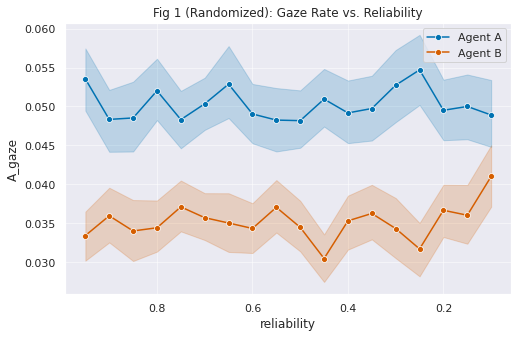

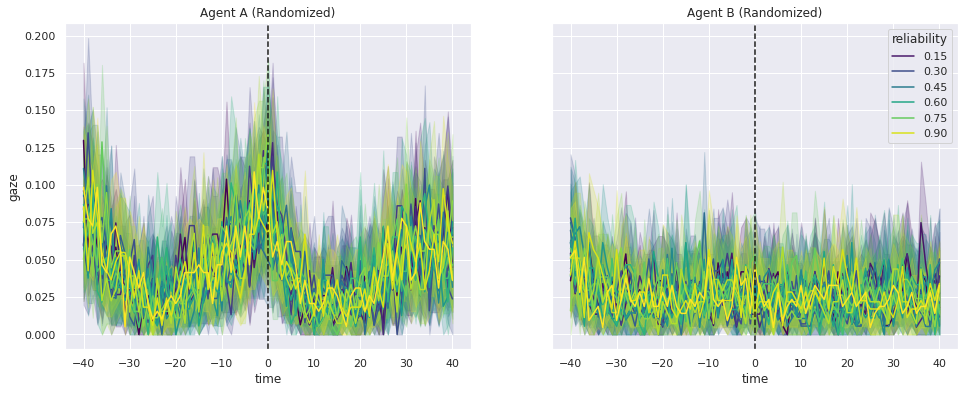

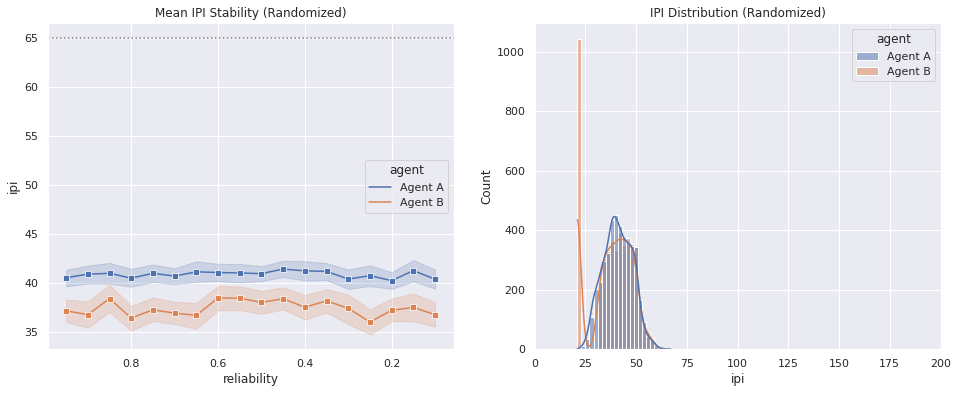

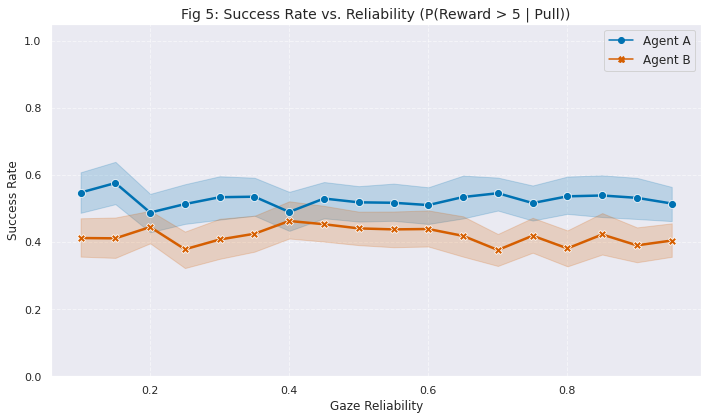

In [114]:
#################################################################
# 11. RANDOMIZED BEHAVIORAL ANALYSIS (Trial-by-Trial)
#################################################################

def run_comprehensive_analysis_randomized():
    
    print("\n--- Starting RANDOMIZED Behavioral Analysis ---")
    
    # --- Config ---
    DATA_FILENAME = "test_data_randomized.pkl"   # Distinct filename
    FORCE_GENERATE = True                        # Typically True for random to get fresh seeds
    
    N_EPISODES = 1000                            # Total trials to run
    STEPS_PER_EPISODE = 200                      # Steps per trial
    
    # Same granularity as before
    # RELIABILITIES = [0.0, 0.3, 0.6, 0.9] 
    RELIABILITIES = [ # 0.0, 0.05,
                     0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 
                     0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 
                     0.7, 0.75, 0.8, 0.85, 0.9, 0.95] # Low, Mid, High reliability
          
    # TEST_COST = 0.08  
    TEST_COST = 0.2  
    
    WINDOW_SIZE = 40 
    
    # --- 1. DATA GENERATION LOOP (TRIAL-BY-TRIAL) ---
    if os.path.exists(DATA_FILENAME) and not FORCE_GENERATE:
        print(f"Found existing data: '{DATA_FILENAME}'")
        df = pd.read_pickle(DATA_FILENAME)
    else:
        print(f"Starting Simulation ({N_EPISODES} episodes)...")
        
        # Load Agents
        agent_A = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE, MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)
        agent_B = AgentBrain(PUBLIC_INPUT_SIZE, PRIVATE_INPUT_SIZE, RNN_HIDDEN_SIZE, MOVE_ACTIONS, PULL_ACTIONS, GAZE_ACTIONS).to(device)
        
        try:
            # # use the most basic trained model 
            # agent_A.load_state_dict(torch.load("agent_A_brain_withGAE_PPO.pth"))
            # agent_B.load_state_dict(torch.load("agent_B_brain_withGAE_PPO.pth"))
            # print("Loaded the most based trained model.")
            #
            # # use the one mastered 1s but has not learned gaze cost
            # agent_A.load_state_dict(torch.load("agent_A_1s_expert_withGAE_PPO.pth"))
            # agent_B.load_state_dict(torch.load("agent_B_1s_expert_withGAE_PPO.pth"))
            # print("Loaded the 1s expert but no gaze cost.")
            
            # # Instead of "agent_A_generalist_withGAE_PPO.pth", use the one that mastered the 1s and learned the gaze cost
            agent_A.load_state_dict(torch.load("agent_A_efficient_expert.pth"))
            agent_B.load_state_dict(torch.load("agent_B_efficient_expert.pth"))
            print("Loaded Efficient Experts (Testing Zero-Shot Robustness).")
            #
            # # use the generalist - the one who learns the reliability - the main one
            # agent_A.load_state_dict(torch.load("agent_A_generalist_withGAE_PPO.pth"))
            # agent_B.load_state_dict(torch.load("agent_B_generalist_withGAE_PPO.pth"))
            # print("Loaded Generalist Experts.")
            # 
            #
            # # # use the generalist, but also learn that gaze need latency - do not use 
            # # agent_A.load_state_dict(torch.load("agent_A_generalist_latency.pth"))
            # # agent_B.load_state_dict(torch.load("agent_A_generalist_latency.pth"))
            # # print("Loaded Generalist Experts with gaze latency.")
            #
        except FileNotFoundError:
            print("Error: Generalist models not found.")
            return

        agent_A.eval(); agent_B.eval()
        
        # We handle resets manually, so standard env is fine
        env = CurriculumEnv() 
        env.set_training_phase("COOP_FULL", sync_window=10)
        env.gaze_cost = TEST_COST 
        
        history_data = []

        for episode in range(N_EPISODES):
            
            # 1. Randomize Reliability per Trial
            rel = np.random.choice(RELIABILITIES)
            
            if episode % 100 == 0: print(f"  Episode {episode} | Rel: {rel:.2f}")

            # 2. Reset
            state_A_dict, state_B_dict = env.reset()
            
            # Reset Hidden States (Critical for Trial-by-Trial)
            hidden_A = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)
            hidden_B = torch.zeros(1, RNN_HIDDEN_SIZE).to(device)
            
            public_A = preprocess_state(state_A_dict); public_B = preprocess_state(state_B_dict)
            private_A = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
            private_B = torch.zeros(1, PRIVATE_INPUT_SIZE).to(device)
            
            for step in range(STEPS_PER_EPISODE):
                # Masks
                mask_A = torch.tensor([[0., 0.]] if state_A_dict['can_pull'] else [[0., -1e9]]).to(device)
                mask_B = torch.tensor([[0., 0.]] if state_B_dict['can_pull'] else [[0., -1e9]]).to(device)

                # Agents
                (logits_A), _, next_h_A = agent_A(public_A, private_A, hidden_A, mask_A)
                actions_A = sample_actions_for_testing(logits_A)
                (logits_B), _, next_h_B = agent_B(public_B, private_B, hidden_B, mask_B)
                actions_B = sample_actions_for_testing(logits_B)
                
                # Env
                next_A_dict, next_B_dict, r_A, r_B, _ = env.step(actions_A, actions_B)
                outcome = "Success" if r_A > 5.0 else "Fail"
                
                history_data.append({
                    'episode': episode, # <--- NEW TRACKING FIELD
                    'reliability': rel,
                    'step_global': (episode * STEPS_PER_EPISODE) + step,
                    'step_local': step,
                    'A_pull': actions_A['pull'], 'B_pull': actions_B['pull'],
                    'A_gaze': actions_A['gaze'], 'B_gaze': actions_B['gaze'],
                    'outcome': outcome
                })
                
                # 7. Prepare Next State (UPDATED for Gaussian Logic)
                # We no longer roll a die for 'is_reliable_now'. 
                # We pass the reliability level directly to scale the Gaussian noise.
                
                private_A = get_private_state(
                    next_B_dict, 
                    env.B_time_since_pull, 
                    env.current_sync_window, 
                    reliability_level=rel,               # <--- Pass the loop variable 'rel'
                    is_gazing=(actions_A['gaze'] == 1)   # <--- Pass the action
                )
                
                private_B = get_private_state(
                    next_A_dict, 
                    env.A_time_since_pull, 
                    env.current_sync_window, 
                    reliability_level=rel,               # <--- Pass the loop variable 'rel'
                    is_gazing=(actions_B['gaze'] == 1)   # <--- Pass the action
                )
                
                public_A = preprocess_state(next_A_dict)
                public_B = preprocess_state(next_B_dict)
                state_A_dict = next_A_dict
                state_B_dict = next_B_dict
                hidden_A = next_h_A
                hidden_B = next_h_B

        df = pd.DataFrame(history_data)
        df.to_pickle(DATA_FILENAME)
        print(f"Data saved to '{DATA_FILENAME}'")

    # --- 2. PLOTTING (With Boundary Checks) ---
    print("Generating Plots (Randomized Mode)...")
    
    # --- FIGURE 1: Gaze Adaptation Curve ---
    plt.figure(figsize=(8, 5))
    # Pandas/Seaborn automatically aggregates all episodes with the same reliability
    sns.lineplot(data=df, x='reliability', y='A_gaze', label='Agent A', marker='o', color='#0072B2', errorbar=('ci', 95))
    sns.lineplot(data=df, x='reliability', y='B_gaze', label='Agent B', marker='o', color='#D55E00', errorbar=('ci', 95))
    plt.title(f"Fig 1 (Randomized): Gaze Rate vs. Reliability")
    plt.gca().invert_xaxis() 
    plt.grid(True, alpha=0.5)
    plt.savefig("Fig1_Randomized_Adaptation.pdf")
    
    # --- PETH BUILDER (UPDATED FOR EPISODES) ---
    def build_peth_dataframe_randomized(agent_char):
        pull_col = f"{agent_char}_pull"
        gaze_col = f"{agent_char}_gaze"
        peth_records = []
        
        # Get indices of all pulls
        pull_indices = df.index[df[pull_col] == 1].tolist()
        
        for idx in pull_indices:
            start = idx - WINDOW_SIZE
            end = idx + WINDOW_SIZE + 1
            
            # Check 1: DataFrame Boundaries
            if start < 0 or end > len(df): continue
            
            # Check 2: EPISODE BOUNDARIES (Critical!)
            # We ensure the start and end of the window belong to the SAME episode
            ep_start = df.at[start, 'episode']
            ep_end = df.at[end-1, 'episode'] # end is exclusive
            
            if ep_start != ep_end:
                continue # Skip this pull because the window crosses a trial boundary
            
            # Extract
            window_gaze = df[gaze_col].iloc[start:end].values
            rel = df.at[idx, 'reliability']
            outcome = df.at[idx, 'outcome']
            
            times = np.arange(-WINDOW_SIZE, WINDOW_SIZE + 1)
            for t, g in zip(times, window_gaze):
                peth_records.append({
                    'reliability': rel,
                    'time': t,
                    'gaze': g,
                    'outcome': outcome
                })
        return pd.DataFrame(peth_records)

    print("Building PETH (Filtering episode boundaries)...")
    df_peth_A = build_peth_dataframe_randomized("A")
    df_peth_B = build_peth_dataframe_randomized("B")

    # --- FIGURE 2: PETH by Reliability ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    if not df_peth_A.empty:
        sns.lineplot(data=df_peth_A, x='time', y='gaze', hue='reliability', palette='viridis', ax=axes[0], legend=False)
    axes[0].set_title("Agent A (Randomized)")
    axes[0].axvline(0, color='k', linestyle='--')
    
    if not df_peth_B.empty:
        sns.lineplot(data=df_peth_B, x='time', y='gaze', hue='reliability', palette='viridis', ax=axes[1])
    axes[1].set_title("Agent B (Randomized)")
    axes[1].axvline(0, color='k', linestyle='--')
    plt.savefig("Fig2_Randomized_PETH.pdf")

    # --- FIGURE 4: IPI Analysis ---
    # We must calculate IPI *within* episodes only
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ipi_records = []
    
    # Iterate by Episode to ensure IPI doesn't calculate across trial jumps
    for ep in df['episode'].unique():
        df_ep = df[df['episode'] == ep]
        rel = df_ep['reliability'].iloc[0]
        
        # Agent A
        pulls_A = df_ep.index[df_ep['A_pull'] == 1].tolist()
        if len(pulls_A) > 1:
            diffs = np.diff(pulls_A)
            for d in diffs: ipi_records.append({'reliability': rel, 'agent': 'Agent A', 'ipi': d})
            
        # Agent B
        pulls_B = df_ep.index[df_ep['B_pull'] == 1].tolist()
        if len(pulls_B) > 1:
            diffs = np.diff(pulls_B)
            for d in diffs: ipi_records.append({'reliability': rel, 'agent': 'Agent B', 'ipi': d})
            
    df_ipi = pd.DataFrame(ipi_records)
    
    # Plot Mean IPI vs Reliability
    if not df_ipi.empty:
        sns.lineplot(data=df_ipi, x='reliability', y='ipi', hue='agent', marker='s', ax=axes[0])
        axes[0].axhline(65, color='gray', linestyle=':')
        axes[0].set_title("Mean IPI Stability (Randomized)")
        axes[0].invert_xaxis()
        
        sns.histplot(data=df_ipi, x="ipi", hue="agent", kde=True, ax=axes[1], binwidth=2)
        axes[1].set_xlim(0, 200)
        axes[1].set_title("IPI Distribution (Randomized)")
        
    plt.savefig("Fig4_Randomized_IPI.pdf")
    
    
    # --- FIGURE 5: Success Rate vs Reliability (INTEGRATED) ---
    print("Generating Figure 5: Success Rate vs. Reliability...")
    
    # 1. Filter for Attempted Pulls
    df_A = df[df['A_pull'] == 1].copy()
    # If A_reward is missing in dummy data, handle gracefully
    if 'A_reward' in df_A.columns:
        df_A['success'] = (df_A['A_reward'] > 5.0).astype(float)
    else: 
        df_A['success'] = (df_A['outcome'] == 'Success').astype(float)
    df_A['Agent'] = 'Agent A'
    
    df_B = df[df['B_pull'] == 1].copy()
    if 'B_reward' in df_B.columns:
        df_B['success'] = (df_B['B_reward'] > 5.0).astype(float)
    else:
        df_B['success'] = (df_B['outcome'] == 'Success').astype(float)
    df_B['Agent'] = 'Agent B'
    
    # 2. Combine
    df_success_plot = pd.concat([
        df_A[['reliability', 'success', 'Agent']], 
        df_B[['reliability', 'success', 'Agent']]
    ])
    
    if not df_success_plot.empty:
        plt.figure(figsize=(10, 6))
        sns.lineplot(
            data=df_success_plot,
            x='reliability',
            y='success',
            hue='Agent',
            style='Agent',
            markers=True,
            dashes=False,
            errorbar=('ci', 95),
            palette={'Agent A': '#0072B2', 'Agent B': '#D55E00'},
            linewidth=2.5,
            markersize=8
        )
        
        plt.title("Fig 5: Success Rate vs. Reliability (P(Reward > 5 | Pull))", fontsize=14)
        plt.ylabel("Success Rate", fontsize=12)
        plt.xlabel("Gaze Reliability", fontsize=12)
        plt.ylim(0, 1.05)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(title=None, fontsize=12)
        
        plt.tight_layout()
        plt.savefig("Fig5_Randomized_AgentSuccessRates.pdf")
        print("Saved Fig5_Randomized_AgentSuccessRates.pdf")
    print("Analysis Complete. PDF files saved.")
    
    
if 1:
    if __name__ == "__main__":
        run_comprehensive_analysis_randomized()
else:
    print("no plotting")

### explore the fake neuron activity

In [93]:
### regenerate and  load the fake neurons

def generate_neural_data():
    
    # --- Constants & Configuration ---
    DATA_FILENAME = "simulated_neural_data.pkl"
    N_STEPS_PER_COND = 5000  # Steps per reliability condition

    # RELIABILITIES = [0.1, 0.3, 0.6, 0.9] 
    RELIABILITIES = [ # 0.0, 0.05,
                     0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 
                     0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 
                     0.7, 0.75, 0.8, 0.85, 0.9, 0.95] # Low, Mid, High reliability

    HIDDEN_SIZE = 128 # Must match your AgentBrain definition


    print("--- Generating Fake Neural Data (Hidden States) ---")
    
    # 1. Setup Environment & Agents
    # env = CurriculumEnv_WithGazeLatency()
    env = CurriculumEnv()
    env.set_training_phase("COOP_FULL", sync_window=10)
    
    # env.gaze_cost = 0.08
    env.gaze_cost = 0.2
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    agent_A = AgentBrain(5, 5, HIDDEN_SIZE, 5, 2, 2).to(device)
    agent_B = AgentBrain(5, 5, HIDDEN_SIZE, 5, 2, 2).to(device)
    
    # Load Weights (Adjust filename to your best model)
    try:
        # # use the most basic trained model 
        # agent_A.load_state_dict(torch.load("agent_A_brain_withGAE_PPO.pth"))
        # agent_B.load_state_dict(torch.load("agent_B_brain_withGAE_PPO.pth"))
        # print("Loaded the most based trained model.")
        #
        # # use the one mastered 1s but has not learned gaze cost
        # agent_A.load_state_dict(torch.load("agent_A_1s_expert_withGAE_PPO.pth"))
        # agent_B.load_state_dict(torch.load("agent_B_1s_expert_withGAE_PPO.pth"))
        # print("Loaded the 1s expert but no gaze cost.")

        # # Instead of "agent_A_generalist_withGAE_PPO.pth", use the one that mastered the 1s and learned the gaze cost
        # agent_A.load_state_dict(torch.load("agent_A_efficient_expert.pth"))
        # agent_B.load_state_dict(torch.load("agent_B_efficient_expert.pth"))
        # print("Loaded Efficient Experts (Testing Zero-Shot Robustness).")
        #
        # use the generalist - the one who learns the reliability - the main one
        agent_A.load_state_dict(torch.load("agent_A_generalist_withGAE_PPO.pth"))
        agent_B.load_state_dict(torch.load("agent_B_generalist_withGAE_PPO.pth"))
        print("Loaded Generalist Experts.")
        # 
        #
        # # # use the generalist, but also learn that gaze need latency - do not use 
        # # agent_A.load_state_dict(torch.load("agent_A_generalist_latency.pth"))
        # # agent_B.load_state_dict(torch.load("agent_A_generalist_latency.pth"))
        # # print("Loaded Generalist Experts with gaze latency.")
        #
    except FileNotFoundError:
        print("Error: Generalist models not found.")
        # print("Error: Generalist models with gaze latency not found.")
        return


    agent_A.eval(); agent_B.eval()
    
    neural_records = []
    
    # 2. Simulation Loop
    for rel in RELIABILITIES:
        print(f"  Simulating Reliability: {rel}...")
        state_A, state_B = env.reset()
        
        # Init Hidden States
        h_A = torch.zeros(1, HIDDEN_SIZE).to(device)
        h_B = torch.zeros(1, HIDDEN_SIZE).to(device)
        
        # Preprocess inputs
        pub_A = preprocess_state(state_A)
        pub_B = preprocess_state(state_B)
        priv_A = torch.zeros(1, 5).to(device)
        priv_B = torch.zeros(1, 5).to(device)
        
        for t in range(N_STEPS_PER_COND):
            # Masks
            mask_A = torch.tensor([[0., 0.]] if state_A['can_pull'] else [[0., -1e9]]).to(device)
            mask_B = torch.tensor([[0., 0.]] if state_B['can_pull'] else [[0., -1e9]]).to(device)
            
            # Forward Pass (Capture Hidden State!)
            with torch.no_grad():
                logits_A, _, h_A = agent_A(pub_A, priv_A, h_A, mask_A)
                logits_B, _, h_B = agent_B(pub_B, priv_B, h_B, mask_B)
            
            # Sample Actions
            act_A_dict = sample_actions_for_testing(logits_A)
            act_B_dict = sample_actions_for_testing(logits_B)
            
            # Step Env
            next_state_A, next_state_B, rA, rB, _ = env.step(act_A_dict, act_B_dict)
            
            # Record Data (We focus on Agent B - The 'Follower' who gazes)
            # We save the hidden state vector as a list
            neural_records.append({
                'time_step': t,
                'reliability': rel,
                'A_pull': act_A_dict['pull'],
                'A_gaze': act_A_dict['gaze'],
                'B_pull': act_B_dict['pull'],
                'B_gaze': act_B_dict['gaze'],
                'A_reward': rA,
                'B_reward': rB,
                'hidden_state_A': h_A.cpu().numpy().flatten(), # Saving Agent A's brain
                'hidden_state_B': h_B.cpu().numpy().flatten() # Saving Agent B's brain
            })
            
            # 7. Prepare Next State (UPDATED FOR GAUSSIAN LOGIC)
            
            # Note: We do NOT need 'is_reliable = ...' anymore.
            # We pass 'rel' (from the outer loop) directly to control noise.
            
            # --- Update Agent A's Private Input ---
            # Input: Agent B's state, B's timer, Window=10, Reliability=rel, Gaze=Action
            priv_A = get_private_state(
                next_state_B, 
                env.B_time_since_pull, 
                10,                     # Hardcoded Sync Window (from your original code)
                reliability_level=rel,  # <--- Use the loop variable 'rel'
                is_gazing=(act_A_dict['gaze'] == 1)
            )
                
            # --- Update Agent B's Private Input ---
            priv_B = get_private_state(
                next_state_A, 
                env.A_time_since_pull, 
                10,                     # Hardcoded Sync Window
                reliability_level=rel,  # <--- Use the loop variable 'rel'
                is_gazing=(act_B_dict['gaze'] == 1)
            )
            
            # (Rest of the loop remains the same)
            state_A = next_state_A; state_B = next_state_B
            pub_A = preprocess_state(state_A); pub_B = preprocess_state(state_B)

    # 3. Save
    df_neural = pd.DataFrame(neural_records)
    df_neural.to_pickle(DATA_FILENAME)
    print(f"Saved {len(df_neural)} steps of neural data to {DATA_FILENAME}")

# Run generation
if 0:
    if __name__ == "__main__":
        generate_neural_data()
else:
    print('nog generating neural data')

nog generating neural data


In [94]:
#### similar neural data simulated, with randomized trial structure


def generate_neural_data_randomized():

    # --- Configuration ---
    DATA_FILENAME = "simulated_neural_data_randomized.pkl"
    N_EPISODES = 1000          # Total number of trials to run
    STEPS_PER_EPISODE = 200   # Length of one trial (standard episode length)

    # RELIABILITIES = [0.3, 0.6, 0.9] 
    # RELIABILITIES = [0.5, 0.5, 0.5] 
    RELIABILITIES = [ # 0.0, 0.05,
                     0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 
                     0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 
                     0.7, 0.75, 0.8, 0.85, 0.9, 0.95] # Low, Mid, High reliability

    HIDDEN_SIZE = 128 
    
    print("--- Generating Randomized Neural Data (Trial-by-Trial) ---")
    
    # --- Setup ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize Environment
    # We use CurriculumEnv directly as we will manage the resets manually
    env = CurriculumEnv()
    env.set_training_phase("COOP_FULL", sync_window=10)
    
    # env.gaze_cost = 0.08
    env.gaze_cost = 0.2
    
    # Initialize Agents
    agent_A = AgentBrain(5, 5, HIDDEN_SIZE, 5, 2, 2).to(device)
    agent_B = AgentBrain(5, 5, HIDDEN_SIZE, 5, 2, 2).to(device)
    
    # Load Weights (Ensure these files exist)
    try:
        # # use the most basic trained model 
        # agent_A.load_state_dict(torch.load("agent_A_brain_withGAE_PPO.pth"))
        # agent_B.load_state_dict(torch.load("agent_B_brain_withGAE_PPO.pth"))
        # print("Loaded the most based trained model.")
        #
        # # use the one mastered 1s but has not learned gaze cost
        # agent_A.load_state_dict(torch.load("agent_A_1s_expert_withGAE_PPO.pth"))
        # agent_B.load_state_dict(torch.load("agent_B_1s_expert_withGAE_PPO.pth"))
        # print("Loaded the 1s expert but no gaze cost.")

        # # Instead of "agent_A_generalist_withGAE_PPO.pth", use the one that mastered the 1s and learned the gaze cost
        # agent_A.load_state_dict(torch.load("agent_A_efficient_expert.pth"))
        # agent_B.load_state_dict(torch.load("agent_B_efficient_expert.pth"))
        # print("Loaded Efficient Experts (Testing Zero-Shot Robustness).")
        #
        # use the generalist - the one who learns the reliability - the main one
        agent_A.load_state_dict(torch.load("agent_A_generalist_withGAE_PPO.pth"))
        agent_B.load_state_dict(torch.load("agent_B_generalist_withGAE_PPO.pth"))
        print("Loaded Generalist Experts.")
        # 
        #
        # # # use the generalist, but also learn that gaze need latency - do not use 
        # # agent_A.load_state_dict(torch.load("agent_A_generalist_latency.pth"))
        # # agent_B.load_state_dict(torch.load("agent_A_generalist_latency.pth"))
        # # print("Loaded Generalist Experts with gaze latency.")
        #
    except FileNotFoundError:
        print("Error: Model weights not found.")
        return

    agent_A.eval()
    agent_B.eval()
    
    neural_records = []
    
    # --- Main Trial Loop ---
    for episode in range(N_EPISODES):
        
        # 1. SAMPLE RELIABILITY (Trial-by-Trial Variation)
        # Pick a random reliability for this entire episode
        rel = np.random.choice(RELIABILITIES)
        
        if episode % 50 == 0:
            print(f"  Episode {episode}/{N_EPISODES} | Reliability: {rel}")

        # 2. RESET ENV (Start of Trial)
        state_A, state_B = env.reset()
        
        # Reset Hidden States (New trial = Fresh short-term memory)
        h_A = torch.zeros(1, HIDDEN_SIZE).to(device)
        h_B = torch.zeros(1, HIDDEN_SIZE).to(device)
        
        # Preprocess initial inputs
        pub_A = preprocess_state(state_A)
        pub_B = preprocess_state(state_B)
        priv_A = torch.zeros(1, 5).to(device)
        priv_B = torch.zeros(1, 5).to(device)
        
        # 3. RUN EPISODE
        for t in range(STEPS_PER_EPISODE):
            # Masks
            mask_A = torch.tensor([[0., 0.]] if state_A['can_pull'] else [[0., -1e9]]).to(device)
            mask_B = torch.tensor([[0., 0.]] if state_B['can_pull'] else [[0., -1e9]]).to(device)
            
            # Forward Pass
            with torch.no_grad():
                logits_A, _, h_A = agent_A(pub_A, priv_A, h_A, mask_A)
                logits_B, _, h_B = agent_B(pub_B, priv_B, h_B, mask_B)
            
            # Sample Actions
            act_A_dict = sample_actions_for_testing(logits_A)
            act_B_dict = sample_actions_for_testing(logits_B)
            
            # Step Environment
            next_state_A, next_state_B, rA, rB, _ = env.step(act_A_dict, act_B_dict)
            
            # Record Data
            neural_records.append({
                'episode': episode,        # Track which trial this belongs to
                'time_step': t,            # Time within the trial
                'reliability': rel,        # The condition for this trial
                'A_pull': act_A_dict['pull'],
                'A_gaze': act_A_dict['gaze'],
                'B_pull': act_B_dict['pull'],
                'B_gaze': act_B_dict['gaze'],
                'A_reward': rA,
                'B_reward': rB,
                'hidden_state_A': h_A.cpu().numpy().flatten(),
                'hidden_state_B': h_B.cpu().numpy().flatten()
            })
            
            # 7. Prepare Next State (UPDATED FOR GAUSSIAN LOGIC)
            
            # Note: We do NOT need 'is_reliable = ...' anymore.
            # We pass 'rel' (from the outer loop) directly to control noise.
            
            # --- Update Agent A's Private Input ---
            # Input: Agent B's state, B's timer, Window=10, Reliability=rel, Gaze=Action
            priv_A = get_private_state(
                next_state_B, 
                env.B_time_since_pull, 
                10,                     # Hardcoded Sync Window (from your original code)
                reliability_level=rel,  # <--- Use the loop variable 'rel'
                is_gazing=(act_A_dict['gaze'] == 1)
            )
                
            # --- Update Agent B's Private Input ---
            priv_B = get_private_state(
                next_state_A, 
                env.A_time_since_pull, 
                10,                     # Hardcoded Sync Window
                reliability_level=rel,  # <--- Use the loop variable 'rel'
                is_gazing=(act_B_dict['gaze'] == 1)
            )
            
            # (Rest of the loop remains the same)
            state_A = next_state_A; state_B = next_state_B
            pub_A = preprocess_state(state_A); pub_B = preprocess_state(state_B)

    # --- Save Data ---
    df_neural = pd.DataFrame(neural_records)
    df_neural.to_pickle(DATA_FILENAME)
    print(f"Saved {len(df_neural)} steps of randomized neural data to {DATA_FILENAME}")

# To run it:
# 
# Run generation
if 0:
    if __name__ == "__main__":
        generate_neural_data_randomized()
else:
    print('not generating neural data with randomized structure')

not generating neural data with randomized structure


In [95]:
# ==========================================
#        MASTER CONFIGURATION SWITCH
# ==========================================

# # Set this to "BLOCK" or "RANDOM" to switch modes
GENERATION_MODE = "RANDOM" 
# GENERATION_MODE = "BLOCK"

# ==========================================

if GENERATION_MODE == "BLOCK":
    
    # # 1. Run the Block generation
    generate_neural_data()
    
    # 2. Set the filename for the analysis stage
    CURRENT_DATA_FILE = "simulated_neural_data.pkl"
    print(f"\n>>> MODE SET: Block Design. Data saved to {CURRENT_DATA_FILE}")

elif GENERATION_MODE == "RANDOM":
    
    # # 1. Run the Randomized generation
    generate_neural_data_randomized()
    
    # 2. Set the filename for the analysis stage
    CURRENT_DATA_FILE = "simulated_neural_data_randomized.pkl"
    print(f"\n>>> MODE SET: Randomized Design. Data saved to {CURRENT_DATA_FILE}")

else:
    print("Please set GENERATION_MODE to 'BLOCK' or 'RANDOM'")

--- Generating Randomized Neural Data (Trial-by-Trial) ---
*** ENV UPDATED: Phase=COOP_FULL, SyncWindow=10, GazeCost=0.0 ***
Loaded Generalist Experts.
  Episode 0/1000 | Reliability: 0.45
  Episode 50/1000 | Reliability: 0.1
  Episode 100/1000 | Reliability: 0.3
  Episode 150/1000 | Reliability: 0.55
  Episode 200/1000 | Reliability: 0.9
  Episode 250/1000 | Reliability: 0.45
  Episode 300/1000 | Reliability: 0.9
  Episode 350/1000 | Reliability: 0.4
  Episode 400/1000 | Reliability: 0.35
  Episode 450/1000 | Reliability: 0.4
  Episode 500/1000 | Reliability: 0.15
  Episode 550/1000 | Reliability: 0.15
  Episode 600/1000 | Reliability: 0.75
  Episode 650/1000 | Reliability: 0.25
  Episode 700/1000 | Reliability: 0.7
  Episode 750/1000 | Reliability: 0.1
  Episode 800/1000 | Reliability: 0.5
  Episode 850/1000 | Reliability: 0.1
  Episode 900/1000 | Reliability: 0.85
  Episode 950/1000 | Reliability: 0.45
Saved 200000 steps of randomized neural data to simulated_neural_data_randomized.

In [96]:
# add 'episode' in the block style generated data
# 1. Load the data
filename = "simulated_neural_data.pkl"
df = pd.read_pickle(filename)

# 2. Check if 'episode' is missing and add it
if 'episode' not in df.columns:
    print("Patching DataFrame: Adding missing 'episode' column...")
    
    # Create a new episode ID every time the 'reliability' value changes
    # This treats each reliability block as a distinct episode.
    df['episode'] = (df['reliability'] != df['reliability'].shift()).cumsum()
    
    # 3. Save the fixed file
    df.to_pickle(filename)
    print(f"Success! '{filename}' has been updated.")
    
    # Optional: Verify
    print("New columns:", df.columns.tolist())
    print("Unique episodes:", df['episode'].unique())
else:
    print(f"'{filename}' already has an 'episode' column.")

'simulated_neural_data.pkl' already has an 'episode' column.


--- Starting Analysis on: simulated_neural_data_randomized.pkl ---
--- Starting Full Neural Analysis ---
Loaded 200000 steps of neural data.
Normalizing neural data...
Generating Figure 1: Mean Population Activity (PETH)...
Generating Panel: Firing Rate by Reliability Condition...
Saved Fig_Neural_Firing_by_Reliability_Gradient.pdf


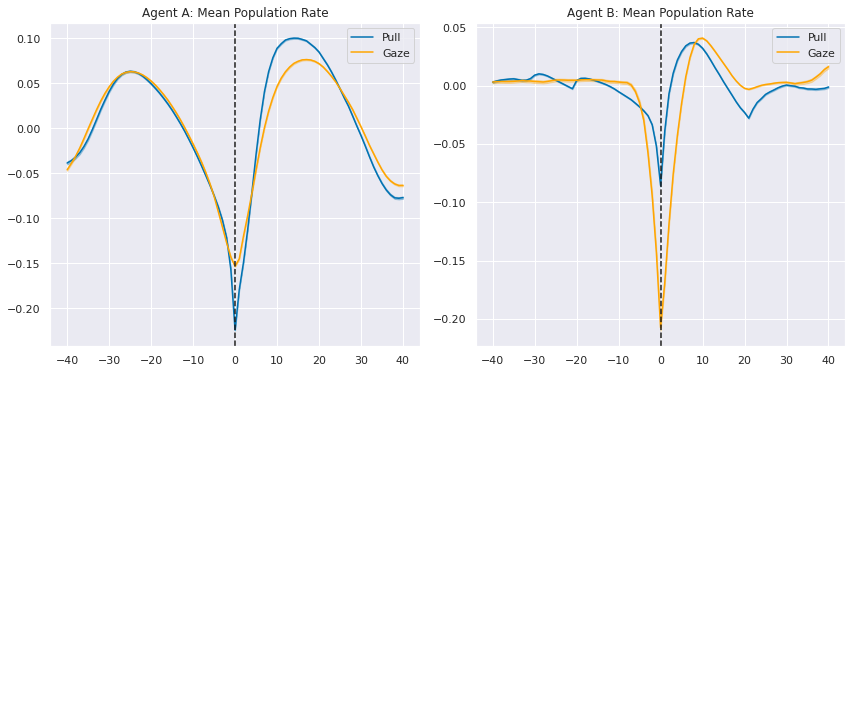

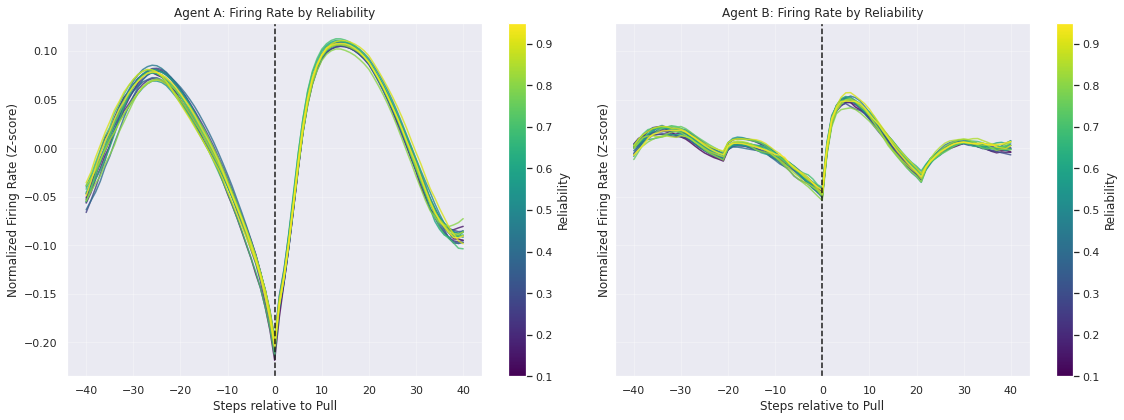

Generating Panel: Firing Rate by Social Evidence Quantiles (5 Bins)...
max gaze number: 10
min gaze number: 0
max social_evidence: 8.549999999999999
min social_evidence: 0.0
max gaze number: 4
min gaze number: 0
max social_evidence: 2.8499999999999996
min social_evidence: 0.0
Saved Fig1_Extension_SocialEvidence_Quantiles.pdf


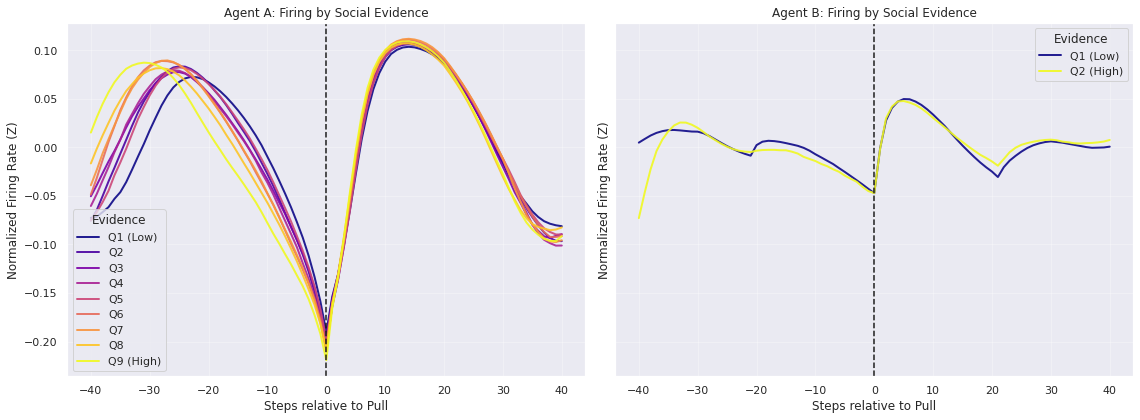

Generating Figure 2: Venn Diagrams...


/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/matplotlib_venn/layout/venn3/pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


Generating Figure 3: Correlation (Slope vs GAZE-FILTERED Evidence)...
Generating Figure 4: Correlation (Slope vs Total Gaze Count)...
Saved Fig3_Neural_Corr_Swarm.pdf


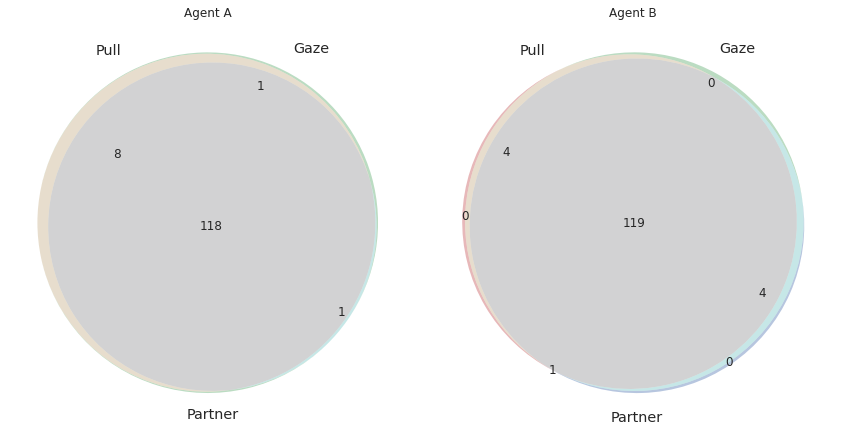

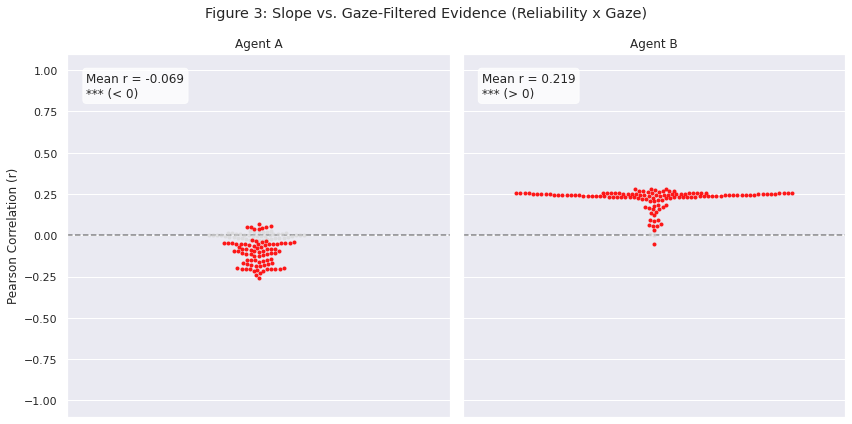

Saved Fig4_Neural_Control_Gaze.pdf


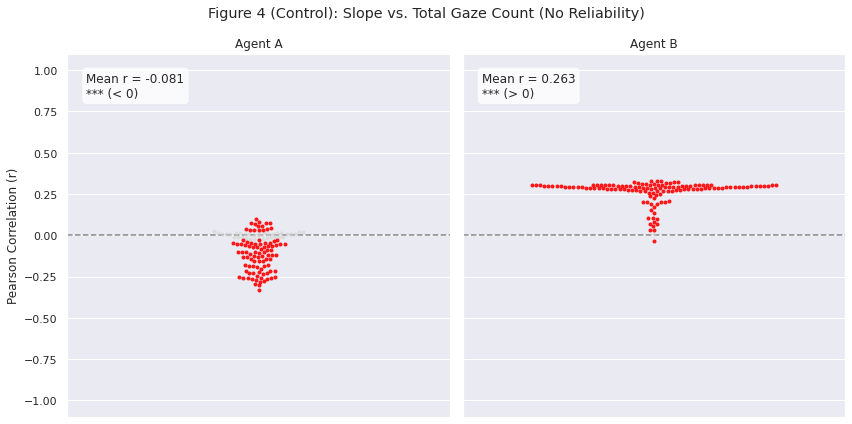

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import sem, pearsonr, ttest_1samp

# Try to import matplotlib_venn, handle if missing
try:
    from matplotlib_venn import venn3
    HAS_VENN = True
except ImportError:
    HAS_VENN = False
    print("! matplotlib_venn not found. Install with `pip install matplotlib-venn` for Venn diagrams.")

# --- Configuration ---
WINDOW_SIZE = 40  # Used for PETH plots only

# DATA_FILENAME = "simulated_neural_data.pkl" 

# Use the variable from the switch cell:
try:
    # Check if the switch variable exists, otherwise default
    target_file = CURRENT_DATA_FILE 
except NameError:
    target_file = "simulated_neural_data_randomized.pkl" # Default fallback

print(f"--- Starting Analysis on: {target_file} ---")


def analyze_and_plot_all_figures():
    print("--- Starting Full Neural Analysis ---")
    
    # 1. Load Data
    try:
        df = pd.read_pickle(target_file) # <--- USE THE VARIABLE HERE
        print(f"Loaded {len(df)} steps of neural data.")
    except FileNotFoundError:
        print(f"Error: {target_file} not found.")
        return

    # Helper to unpack and normalize hidden states
    def get_neural_matrix(agent_char):
        col_name = f'hidden_state_{agent_char}'
        # Stack list of vectors into matrix (Time x Neurons)
        matrix = np.stack(df[col_name].values)
        # Z-score normalization
        means = matrix.mean(axis=0)
        stds = matrix.std(axis=0) + 1e-8
        return (matrix - means) / stds

    print("Normalizing neural data...")
    neural_A = get_neural_matrix('A')
    neural_B = get_neural_matrix('B')
    n_neurons = neural_A.shape[1]

    # =========================================================================
    # PLOT 1: MEAN FIRING RATE PETH (-40 to +40 steps)
    # =========================================================================
    print("Generating Figure 1: Mean Population Activity (PETH)...")
    
    def get_peth(neural_matrix, event_col):
        indices = df.index[df[event_col] == 1].tolist()
        windows = []
        for idx in indices:
            start = idx - WINDOW_SIZE
            end = idx + WINDOW_SIZE + 1
            if start >= 0 and end <= len(df):
                win = neural_matrix[start:end, :]
                win_mean = np.mean(win, axis=1) 
                windows.append(win_mean)
        if not windows: return None, None
        windows = np.vstack(windows)
        return np.mean(windows, axis=0), sem(windows, axis=0)

    fig1, axes = plt.subplots(2, 2, figsize=(12, 10))
    x_axis = np.arange(-WINDOW_SIZE, WINDOW_SIZE + 1)
    
    for i, (matrix, char) in enumerate([(neural_A, 'A'), (neural_B, 'B')]):
        # Pull
        m, s = get_peth(matrix, f'{char}_pull')
        if m is not None:
            axes[0,i].plot(x_axis, m, color='#0072B2', label='Pull')
            axes[0,i].fill_between(x_axis, m-s, m+s, color='#0072B2', alpha=0.3)
        # Gaze
        m, s = get_peth(matrix, f'{char}_gaze')
        if m is not None:
            axes[0,i].plot(x_axis, m, color='orange', label='Gaze')
            axes[0,i].fill_between(x_axis, m-s, m+s, color='orange', alpha=0.3)
        axes[0,i].set_title(f"Agent {char}: Mean Population Rate")
        axes[0,i].axvline(0, color='k', linestyle='--')
        axes[0,i].legend()
        
    axes[1,0].axis('off'); axes[1,1].axis('off') 
    plt.tight_layout(); plt.savefig("Fig1_Neural_PETH.pdf")
    
    # =========================================================================
    # PLOT 1.5: Firing Rate Aligned at Pull by RELIABILITY
    # =========================================================================
    print("Generating Panel: Firing Rate by Reliability Condition...")
    
    def get_reliability_peth(df, neural_matrix, agent_char):
        col_pull = f'{agent_char}_pull'
        
        # 1. Identify Pull Indices and their Reliability
        # We can simply filter the dataframe for pull events
        pull_rows = df[df[col_pull] == 1]
        
        # Group by Reliability
        unique_reliabilities = sorted(df['reliability'].unique())
        results = {}
        
        for rel in unique_reliabilities:
            # Get all pull indices for this reliability
            indices = pull_rows[pull_rows['reliability'] == rel].index.tolist()
            windows = []
            
            for idx in indices:
                start = idx - WINDOW_SIZE
                end = idx + WINDOW_SIZE + 1
                
                # Check bounds
                if start >= 0 and end <= len(df):
                    # Check episode continuity (ensure window doesn't cross trials)
                    ep_start = df.at[start, 'episode']
                    ep_end = df.at[end-1, 'episode']
                    
                    if ep_start == ep_end:
                        # Extract Window: (81, n_neurons)
                        win_activity = neural_matrix[start:end, :]
                        # Mean across neurons -> (81,)
                        mean_pop_activity = np.mean(win_activity, axis=1)
                        windows.append(mean_pop_activity)
            
            if len(windows) > 5: # Only plot if we have enough data
                windows = np.vstack(windows)
                mean_trace = np.mean(windows, axis=0)
                sem_trace = sem(windows, axis=0)
                results[rel] = (mean_trace, sem_trace)
            else:
                results[rel] = (None, None)
                
        return results, unique_reliabilities

    # Calculate
    peth_data_A, rel_levels_A = get_reliability_peth(df, neural_A, 'A')
    peth_data_B, rel_levels_B = get_reliability_peth(df, neural_B, 'B')

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    x_axis = np.arange(-WINDOW_SIZE, WINDOW_SIZE + 1)
    
    # Create a colormap
    cmap = plt.get_cmap("viridis") # or 'coolwarm', 'plasma'
    
    def plot_agent_peth(ax, peth_data, rel_levels, title):
        # Normalize reliability for color mapping
        norm = plt.Normalize(min(rel_levels), max(rel_levels))
        
        for rel in rel_levels:
            mean_tr, sem_tr = peth_data[rel]
            if mean_tr is not None:
                color = cmap(norm(rel))
                ax.plot(x_axis, mean_tr, color=color, lw=1.5, alpha=0.8)
                # Optional: Fill SEM (can be messy with many lines, maybe omit for clarity)
                # ax.fill_between(x_axis, mean_tr - sem_tr, mean_tr + sem_tr, color=color, alpha=0.1)
        
        ax.set_title(title)
        ax.set_xlabel("Steps relative to Pull")
        ax.set_ylabel("Normalized Firing Rate (Z-score)")
        ax.axvline(0, color='k', linestyle='--')
        ax.grid(True, alpha=0.3)
        
        # Add Colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label('Reliability')

    plot_agent_peth(axes[0], peth_data_A, rel_levels_A, "Agent A: Firing Rate by Reliability")
    plot_agent_peth(axes[1], peth_data_B, rel_levels_B, "Agent B: Firing Rate by Reliability")

    plt.tight_layout()
    plt.savefig("Fig_Neural_Firing_by_Reliability_Gradient.pdf")
    print("Saved Fig_Neural_Firing_by_Reliability_Gradient.pdf")
    plt.show()
    
    # =========================================================================
    # PLOT 1.6: Firing Rate Aligned at Pull by SOCIAL EVIDENCE QUANTILES
    # =========================================================================
    print("Generating Panel: Firing Rate by Social Evidence Quantiles (5 Bins)...")

    def get_social_evidence_peth(df, neural_matrix, agent_char):
        pull_col = f'{agent_char}_pull'
        gaze_col = f'{agent_char}_gaze'
        
        # 1. Identify Trials (Intervals between pulls)
        pull_indices = df.index[df[pull_col] == 1].tolist()
        
        trial_data = []
        
        # We need at least 2 pulls to define an interval
        for i in range(1, len(pull_indices)):
            prev_idx = pull_indices[i-1]
            curr_idx = pull_indices[i]
            
            # Define Trial Window (start to end of IPI)
            # We add +1 to start after the previous pull
            
            start_idx = prev_idx + 1
            # start_idx = curr_idx - 25 # alternatives, to only use the 20 step before pull
            
            end_idx = curr_idx + 1 # Include the current pull step for indexing
            
            # Check for episode continuity (crucial!)
            if 'episode' in df.columns:
                if df['episode'].iloc[start_idx] != df['episode'].iloc[curr_idx]:
                    continue
            
            # Calculate Social Evidence for this specific trial
            # Sum of gaze during the interval * Reliability of this trial
            trial_gaze = df[gaze_col].iloc[start_idx:end_idx].values
            rel = df['reliability'].iloc[curr_idx]
            social_evidence = np.sum(trial_gaze) * rel
            
            trial_data.append({
                'pull_index': curr_idx,
                'social_evidence': social_evidence,
                'trial_gaze': np.sum(trial_gaze)
            })
            
        df_trials = pd.DataFrame(trial_data)
        
        # for sanity check
        max_trial_gaze = np.nanmax(df_trials['trial_gaze'])
        min_trial_gaze = np.nanmin(df_trials['trial_gaze'])
        print('max gaze number: '+str(max_trial_gaze))
        print('min gaze number: '+str(min_trial_gaze))
        
        # for sanity check
        max_social_evidence = np.nanmax(df_trials['social_evidence'])
        min_social_evidence = np.nanmin(df_trials['social_evidence'])
        print('max social_evidence: '+str(max_social_evidence))
        print('min social_evidence: '+str(min_social_evidence))
        
        
        # 2. Split into 5 Quantiles
        # We use 'rank' method='first' to handle ties (lots of zeros) gracefully
        # or qcut with duplicates='drop'. 
        # Here we force 5 bins if possible.
        try:
            df_trials['quantile'] = pd.qcut(df_trials['social_evidence'], 10, labels=False, duplicates='drop')
        except ValueError:
            # Fallback if too many zeros: just use simple bins or skip
            print(f"Warning: Not enough variance in social evidence for Agent {agent_char} to make 10 unique quantiles.")
            return None, None

        # 3. Extract PETH for each Quantile
        quantiles = sorted(df_trials['quantile'].unique())
        results = {}
        
        for q in quantiles:
            # Get pull indices for this quantile
            indices = df_trials[df_trials['quantile'] == q]['pull_index'].values
            
            windows = []
            for idx in indices:
                start = idx - WINDOW_SIZE
                end = idx + WINDOW_SIZE + 1
                
                # Boundary check
                if start >= 0 and end <= len(df):
                    # (Optional) Check episode continuity for the PETH window itself
                    if 'episode' in df.columns:
                        if df['episode'].iloc[start] != df['episode'].iloc[end-1]:
                            continue

                    win_activity = neural_matrix[start:end, :]
                    mean_pop = np.mean(win_activity, axis=1) # Mean across neurons
                    windows.append(mean_pop)
            
            if len(windows) > 5:
                windows = np.vstack(windows)
                results[q] = np.mean(windows, axis=0)
            else:
                results[q] = None
                
        return results, quantiles

    # --- Calculate for A and B ---
    se_peth_A, se_quants_A = get_social_evidence_peth(df, neural_A, 'A')
    se_peth_B, se_quants_B = get_social_evidence_peth(df, neural_B, 'B')

    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    x_axis = np.arange(-WINDOW_SIZE, WINDOW_SIZE + 1)
    
    # Use a sequential colormap (Light=Low Evidence, Dark=High Evidence)
    cmap = plt.get_cmap("plasma") 

    def plot_se_peth(ax, peth_data, quants, title):
        if peth_data is None: return
        
        # Normalize 0..4 to 0..1 for color map
        norm = plt.Normalize(min(quants), max(quants))
        
        for q in quants:
            trace = peth_data[q]
            if trace is not None:
                color = cmap(norm(q))
                # Label Q0 as "Lowest" and Q4 as "Highest"
                label = f"Q{q+1} (Low)" if q == min(quants) else f"Q{q+1} (High)" if q == max(quants) else f"Q{q+1}"
                ax.plot(x_axis, trace, color=color, lw=2, alpha=0.9, label=label)
        
        ax.set_title(title)
        ax.set_xlabel("Steps relative to Pull")
        ax.set_ylabel("Normalized Firing Rate (Z)")
        ax.axvline(0, color='k', linestyle='--')
        ax.grid(True, alpha=0.3)
        ax.legend(title="Evidence")

    plot_se_peth(axes[0], se_peth_A, se_quants_A, "Agent A: Firing by Social Evidence")
    plot_se_peth(axes[1], se_peth_B, se_quants_B, "Agent B: Firing by Social Evidence")

    plt.tight_layout()
    plt.savefig("Fig1_Extension_SocialEvidence_Quantiles.pdf")
    print("Saved Fig1_Extension_SocialEvidence_Quantiles.pdf")
    plt.show()

    # =========================================================================
    # PLOT 2: VENN DIAGRAMS (Encoding Analysis)
    # =========================================================================
    print("Generating Figure 2: Venn Diagrams...")
    
    def get_encoding_sets(neural_matrix, agent_char):
        self_pull = df[f'{agent_char}_pull'].values
        self_gaze = df[f'{agent_char}_gaze'].values
        partner_char = 'B' if agent_char == 'A' else 'A'
        partner_pull = df[f'{partner_char}_pull'].values 
        
        X = np.column_stack([self_pull, self_gaze, partner_pull])
        set_pull, set_gaze, set_partner = set(), set(), set()
        
        for i in range(n_neurons):
            y = neural_matrix[:, i]
            model = LinearRegression(); model.fit(X, y)
            coefs = np.abs(model.coef_)
            if coefs[0] > 0.1: set_pull.add(i)
            if coefs[1] > 0.1: set_gaze.add(i)
            if coefs[2] > 0.1: set_partner.add(i)
        return set_pull, set_gaze, set_partner

    sets_A = get_encoding_sets(neural_A, 'A')
    sets_B = get_encoding_sets(neural_B, 'B')

    if HAS_VENN:
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1); venn3([sets_A[0], sets_A[1], sets_A[2]], ('Pull', 'Gaze', 'Partner')); plt.title("Agent A")
        plt.subplot(1, 2, 2); venn3([sets_B[0], sets_B[1], sets_B[2]], ('Pull', 'Gaze', 'Partner')); plt.title("Agent B")
        plt.tight_layout(); plt.savefig("Fig2_Neural_Venn.pdf")

    # =========================================================================
    # PLOT 3: NEURON-LEVEL CORRELATION SWARM PLOT (GAZE-FILTERED)
    # =========================================================================
    print("Generating Figure 3: Correlation (Slope vs GAZE-FILTERED Evidence)...")

    def calculate_correlations(neural_matrix, agent_char, metric_type="evidence"):
        """
        metric_type:
          'evidence' = Total Gaze * Reliability
          'gaze_count' = Total Gaze Only (Control)
        """
        pull_col = f'{agent_char}_pull'
        gaze_col = f'{agent_char}_gaze'
        
        indices = df.index[df[pull_col] == 1].tolist()
        
        trial_metrics = []
        trial_slopes = [] 
        
        for i in range(1, len(indices)):
            prev_idx = indices[i-1]
            curr_idx = indices[i]
            
            start_full = prev_idx + 1
            end_full = curr_idx + 1
            
            start_slope = start_full
            # start_slope = end_full - 25 # only look at 20 steps before pull
            end_slope = end_full 
            
            duration_slope = end_slope - start_slope
            if duration_slope < 5: continue 
            
            win_neural = neural_matrix[start_slope:end_slope, :] 
            trial_gaze = df[gaze_col].iloc[start_full:end_full].values
            rel = df['reliability'].iloc[curr_idx]
            
            if metric_type == "evidence":
                metric_val = np.sum(trial_gaze) * rel
            else:
                metric_val = np.sum(trial_gaze)
            
            try:
                x_axis = np.arange(duration_slope)
                coeffs = np.polyfit(x_axis, win_neural, 1) 
                slopes = coeffs[0] 
                trial_slopes.append(np.abs(slopes))
                trial_metrics.append(metric_val)
            except:
                continue

        if not trial_slopes: return pd.DataFrame()

        slopes_matrix = np.vstack(trial_slopes)
        metric_array = np.array(trial_metrics)
        
        correlations, p_values = [], []
        
        for n in range(slopes_matrix.shape[1]):
            neuron_slopes = slopes_matrix[:, n]
            if np.std(neuron_slopes) < 1e-9 or np.std(metric_array) < 1e-9:
                corr, p_val = 0, 1.0
            else:
                corr, p_val = pearsonr(neuron_slopes, metric_array)
                if np.isnan(corr): corr, p_val = 0, 1.0
            correlations.append(corr)
            p_values.append(p_val)
            
        return pd.DataFrame({'Correlation': correlations, 'P_Value': p_values})

    # --- FIGURE 3 DATA (EVIDENCE) ---
    df_corr_A_ev = calculate_correlations(neural_A, 'A', "evidence")
    df_corr_B_ev = calculate_correlations(neural_B, 'B', "evidence")
    # df_corr_A_ev = calculate_correlations(neural_A, 'A', "")
    # df_corr_B_ev = calculate_correlations(neural_B, 'B', "")

    # --- FIGURE 4 DATA (CONTROL: GAZE COUNT) ---
    print("Generating Figure 4: Correlation (Slope vs Total Gaze Count)...")
    df_corr_A_gaze = calculate_correlations(neural_A, 'A', "gaze_count")
    df_corr_B_gaze = calculate_correlations(neural_B, 'B', "gaze_count")

    # --- PLOTTING FUNCTION ---
    def plot_swarm_figure(df_A, df_B, title, filename):
        fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
        
        def plot_panel(ax, df_data, sub_title, color):
            if df_data.empty: return
            
            df_sig = df_data[df_data['P_Value'] < 0.05]
            df_ns = df_data[df_data['P_Value'] >= 0.05]
            
            sns.swarmplot(data=df_ns, y='Correlation', size=4, color="lightgray", alpha=0.6, ax=ax)
            if not df_sig.empty:
                sns.swarmplot(data=df_sig, y='Correlation', size=4, color=color, alpha=0.9, ax=ax)
                
            ax.set_title(sub_title)
            ax.axhline(0, color='k', linestyle='--', alpha=0.5)
            ax.set_ylim(-1.1, 1.1)
            
            corrs = df_data['Correlation'].values
            if len(corrs) > 1:
                t_stat, p_val = ttest_1samp(corrs, 0)
                mean_corr = np.mean(corrs)
                sig_str = "ns"
                if p_val < 0.001: sig_str = "***"
                elif p_val < 0.01: sig_str = "**"
                elif p_val < 0.05: sig_str = "*"
                direction = "> 0" if mean_corr > 0 else "< 0"
                stats_text = f"Mean r = {mean_corr:.3f}\n{sig_str} ({direction})"
                ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        plot_panel(axes[0], df_A, "Agent A", "red")
        axes[0].set_ylabel("Pearson Correlation (r)")
        plot_panel(axes[1], df_B, "Agent B", "red")
        axes[1].set_ylabel("")
        
        plt.suptitle(title)
        plt.tight_layout()
        plt.savefig(filename)
        print(f"Saved {filename}")
        plt.show()

    # Plot Fig 3
    plot_swarm_figure(df_corr_A_ev, df_corr_B_ev, 
                     "Figure 3: Slope vs. Gaze-Filtered Evidence (Reliability x Gaze)", 
                     "Fig3_Neural_Corr_Swarm.pdf")
    
    # Plot Fig 4
    plot_swarm_figure(df_corr_A_gaze, df_corr_B_gaze, 
                     "Figure 4 (Control): Slope vs. Total Gaze Count (No Reliability)", 
                     "Fig4_Neural_Control_Gaze.pdf")

if __name__ == "__main__":
    analyze_and_plot_all_figures()

### neural population analysis

In [80]:
#################################################################
# 14. POPULATION ANALYSIS: SELF-PACED TRIALS (Fig 4D Final)
#     - Trial Definition: Interval between consecutive pulls
#     - Metrics: Path Variability vs. Social Evidence
#     - Split: Success vs. Failure
#################################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import scipy.stats as stats
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

# --- 1. UPDATED Geometry Calculation (Matching Paper's "Moving Slide") ---
def get_geometry(trajectory):
    """
    Calculates Path Variability (Tortuosity) using Savitzky-Golay filter
    to match the 'moving window' derivative method described in the manuscript.
    """
    if len(trajectory) < 5: return np.zeros(100), np.zeros(100)
    
    # 1. Arc Length Reparameterization (Global Normalization)
    dists = np.sqrt(np.sum(np.diff(trajectory, axis=0)**2, axis=1))
    cum_dist = np.insert(np.cumsum(dists), 0, 0)
    
    if cum_dist[-1] == 0: return np.zeros(100), np.zeros(100)
    
    uniform_steps = np.linspace(0, cum_dist[-1], 100)
    interpolator = interp1d(cum_dist, trajectory, axis=0, kind='cubic')
    traj_norm = interpolator(uniform_steps)
    
    # 2. Calculate Derivatives using Savitzky-Golay (Polynomial Rolling Window)
    # Window length 5, polyorder 3 matches the "moving slide" concept robustly
    try:
        v = savgol_filter(traj_norm, window_length=5, polyorder=3, deriv=1, axis=0)
        a = savgol_filter(traj_norm, window_length=5, polyorder=3, deriv=2, axis=0)
    except Exception:
        # Fallback for very short/flat trajectories if SG fails
        return np.zeros(100), np.zeros(100)
    
    # 3. Calculate Curvature (Kappa)
    cross_prod = np.cross(v, a)
    if cross_prod.ndim == 1: 
        num = np.abs(cross_prod)
    else:
        num = np.sqrt(np.sum(cross_prod**2, axis=1))
        
    denom = (np.sqrt(np.sum(v**2, axis=1)))**3 + 1e-9
    kappa = num / denom
    
    # 4. Calculate Tortuosity (Path Variability)
    # Gradient of kappa also uses the moving window
    d_kappa = savgol_filter(kappa, window_length=5, polyorder=3, deriv=1)
    
    tortuosity = (d_kappa / (kappa + 1e-9))**2
    
    # 5. Final Smoothing (as per paper)
    # Paper: "tortuosity traces were themselves smoothed with a Gaussian kernel"
    tortuosity_smooth = pd.Series(tortuosity).rolling(window=5, center=True, min_periods=1).mean().values
    
    return traj_norm, tortuosity_smooth

In [81]:
CURRENT_DATA_FILE

'simulated_neural_data_randomized.pkl'

--- Starting Full Self-Paced Analysis on: simulated_neural_data_randomized.pkl ---
Loaded 200000 steps of neural data.

=== Analyzing Agent A ===


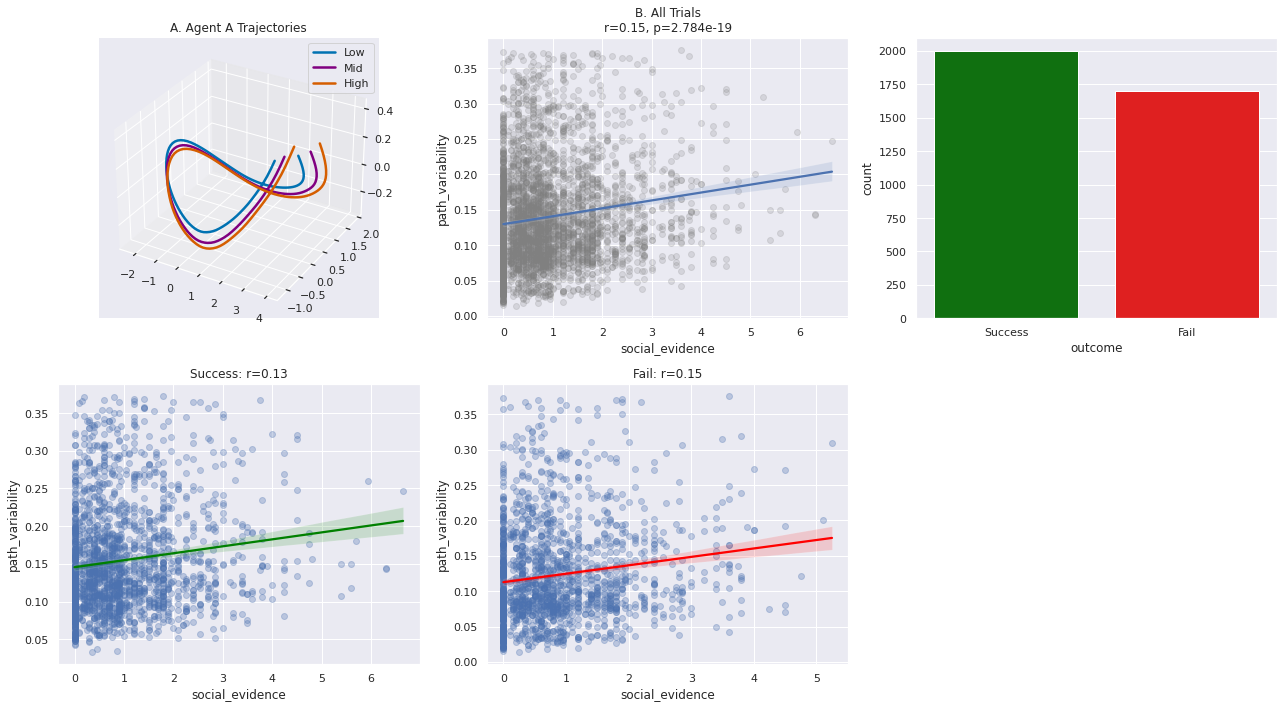


=== Analyzing Agent B ===


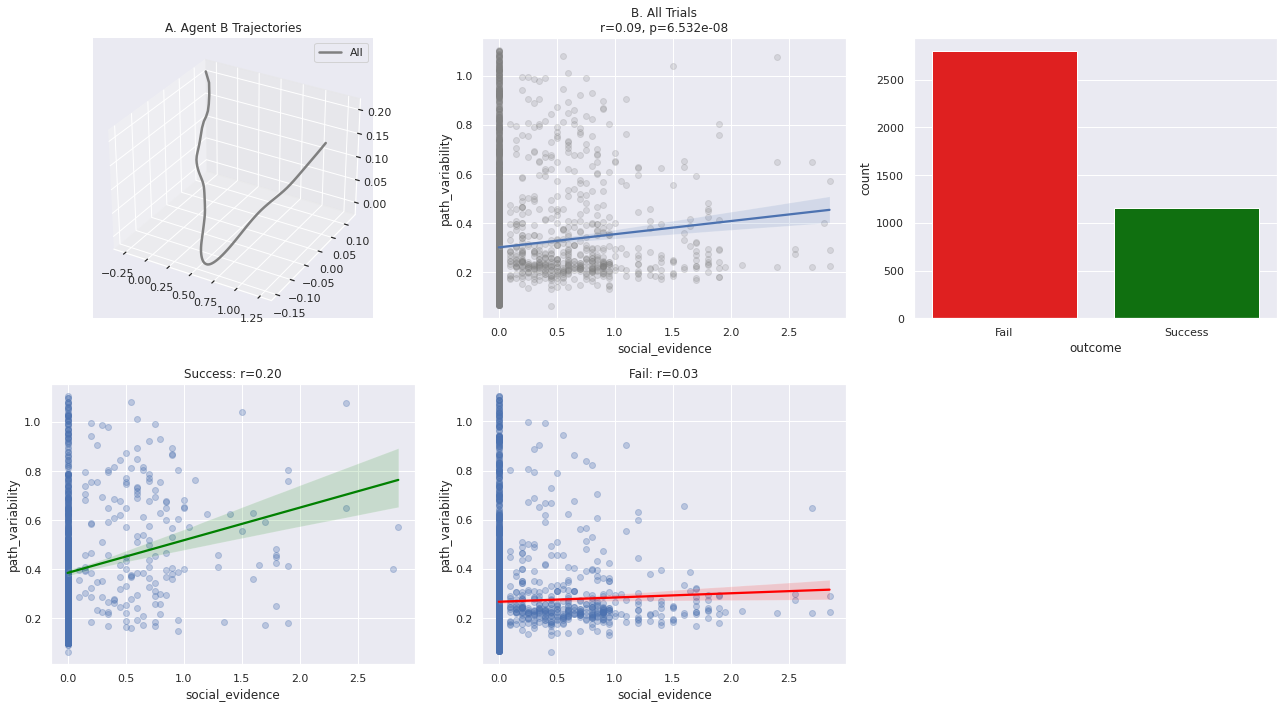

In [82]:
#################################################################
# 14. POPULATION ANALYSIS: SELF-PACED TRIALS (Fig 4D Final)
#     - Trial Definition: Interval between consecutive pulls
#     - Metrics: Path Variability vs. Social Evidence
#     - Split: Success vs. Failure
#################################################################

def run_comprehensive_self_paced():
    # --- 1. Load Data ---
    target_file = CURRENT_DATA_FILE
    print(f"--- Starting Full Self-Paced Analysis on: {target_file} ---")
    try:
        df = pd.read_pickle(target_file)
        print(f"Loaded {len(df)} steps of neural data.")
    except FileNotFoundError:
        print("Data file not found.")
        return

    if 'episode' not in df.columns: df['episode'] = df.index // 200

    for agent_char in ['A', 'B']:
        print(f"\n=== Analyzing Agent {agent_char} ===")
        
        # PCA
        col_neural = f'hidden_state_{agent_char}'
        neural_matrix = np.stack(df[col_neural].values)
        
        # # Add noise before PCA
        # noise_level = 0.01
        # neural_matrix += np.random.normal(0, noise_level, neural_matrix.shape)
        
        pca = PCA(n_components=3)
        neural_pca = pca.fit_transform(neural_matrix)
        df[f'PC1_{agent_char}'] = neural_pca[:, 0]
        df[f'PC2_{agent_char}'] = neural_pca[:, 1]
        df[f'PC3_{agent_char}'] = neural_pca[:, 2]

        # Extract Trials
        results = []
        trajectory_store = {} 
        grouped = df.groupby('episode')
        
        col_pull = f'{agent_char}_pull'
        col_gaze = f'{agent_char}_gaze'
        col_reward = f'{agent_char}_reward'
        
        trial_counter = 0
        for ep, group in grouped:
            pull_indices = group.index[group[col_pull] == 1].tolist()
            if not pull_indices: continue
                
            for i, curr_idx in enumerate(pull_indices):
                start_idx = group.index[0] if i == 0 else pull_indices[i-1] + 1
                trial_df = df.loc[start_idx : curr_idx]
                if len(trial_df) < 20: continue
                
                # Metrics
                final_reward = df.at[curr_idx, col_reward] 
                outcome = "Success" if final_reward > 0.0 else "Fail" 
                rel = df.at[curr_idx, 'reliability']
                gaze_count = trial_df[col_gaze].sum()
                
                # 
                social_evidence = gaze_count * rel
                # social_evidence =rel
                
                
                # Geometry calculation
                traj = trial_df[[f'PC1_{agent_char}', f'PC2_{agent_char}', f'PC3_{agent_char}']].values
                traj_norm, tortuosity_trace = get_geometry(traj)
                mean_pv = np.mean(tortuosity_trace) 
                
                # --- OPTION A ADDED HERE ---
                # Filter out perfectly straight (ballistic) trials to clean up the plot
                if mean_pv < 1e-3: continue 
                # ---------------------------
                
                # *** THIS IS THE STEP YOU ASKED ABOUT ***
                # We calculate the mean of the tortuosity trace for the single trial
                mean_pv = np.mean(tortuosity_trace) 
                
                results.append({
                    'trial_id': trial_counter,
                    'outcome': outcome,
                    'social_evidence': social_evidence,
                    'path_variability': mean_pv
                })
                trajectory_store[trial_counter] = traj_norm
                trial_counter += 1

        df_results = pd.DataFrame(results)
        
        if df_results.empty: continue

        # Outlier Removal
        Q1 = df_results['path_variability'].quantile(0.25)
        Q3 = df_results['path_variability'].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_results[
            (df_results['path_variability'] >= Q1 - 1.5*IQR) & 
            (df_results['path_variability'] <= Q3 + 1.5*IQR)
        ].copy()

        # Plotting
        fig = plt.figure(figsize=(18, 10))
        
        # Panel A: 3D
        ax1 = fig.add_subplot(2, 3, 1, projection='3d')
        try:
            df_clean['evidence_group'] = pd.qcut(df_clean['social_evidence'], 3, duplicates='drop')
            unique_intervals = df_clean['evidence_group'].cat.categories
            labels = ["Low", "Mid", "High"] if len(unique_intervals) == 3 else ["Low", "High"] if len(unique_intervals) == 2 else ["All"]
            colors = ['#0072B2', 'purple', '#D55E00'] if len(labels)==3 else ['#0072B2', '#D55E00'] if len(labels)==2 else ['gray']
            
            bin_map = {interval: label for interval, label in zip(unique_intervals, labels)}
            color_map = {label: color for label, color in zip(labels, colors)}
            df_clean['group_label'] = df_clean['evidence_group'].map(bin_map)
            
            for label in labels:
                ids = df_clean[df_clean['group_label'] == label]['trial_id']
                paths = [trajectory_store[tid] for tid in ids if tid in trajectory_store]
                if paths:
                    mean_path = np.mean(np.array(paths), axis=0)
                    c = color_map[label]
                    ax1.plot(mean_path[:,0], mean_path[:,1], mean_path[:,2], color=c, lw=2.5, label=label)
            ax1.legend()
        except: pass
        ax1.set_title(f"A. Agent {agent_char} Trajectories")

        # Panel B: Regression
        ax2 = fig.add_subplot(2, 3, 2)
        if df_clean['social_evidence'].std() > 1e-6:
            sns.regplot(data=df_clean, x='social_evidence', y='path_variability', ax=ax2, scatter_kws={'alpha':0.2, 'color':'gray'})
            r, p = stats.pearsonr(df_clean['social_evidence'], df_clean['path_variability'])
            ax2.set_title(f"B. All Trials\nr={r:.2f}, p={p:.3e}")
        else:
            sns.scatterplot(data=df_clean, x='social_evidence', y='path_variability', ax=ax2)

        # Panel C: Counts
        ax3 = fig.add_subplot(2, 3, 3)
        sns.countplot(x='outcome', data=df_clean, ax=ax3, palette={"Success":"green", "Fail":"red"})
        
        # Panel D/E: Split
        outcomes = ["Success", "Fail"]
        cols = {"Success": "green", "Fail": "red"}
        for i, out in enumerate(outcomes):
            ax = fig.add_subplot(2, 3, 4 + i)
            sub = df_clean[df_clean['outcome'] == out]
            if len(sub) > 5 and sub['social_evidence'].std() > 1e-6:
                sns.regplot(data=sub, x='social_evidence', y='path_variability', ax=ax, scatter_kws={'alpha':0.3}, line_kws={'color': cols[out]})
                r, p = stats.pearsonr(sub['social_evidence'], sub['path_variability'])
                ax.set_title(f"{out}: r={r:.2f}")
            else:
                sns.scatterplot(data=sub, x='social_evidence', y='path_variability', ax=ax, color=cols[out])
        
        plt.tight_layout()
        plt.savefig(f"Fig4_Corrected_Agent_{agent_char}.pdf")
        plt.show()

if __name__ == "__main__":
    run_comprehensive_self_paced()